<br> 

***  

# <center>**Notebook 09 – Reports**</center>

<br>

<center>Supporting materials for</center>

### <center>MSc Data Science</center>
## <center>Module: DSM500 Final Project</center>

<br>

<center>5 October 2026</center>

***
<br>

**Purpose of this notebook**  
This notebook was used to iteratively develop the reports and visualisation included in the dissertation. Plots are grouped by topic, but the notebook is not intended as a narrative document.

Reports and visualisations rely primarily on the following files containing the outputs of fold-level and scenario-level training for the two classifiers:
```
..
    |--results
        |-- xgb-fold-results-b00.json
        |-- xgb-scenario-results-b00.json
        |-- gnb-fold_results-b00.json
        |-- gnb-scenario-results-b00.json
```
The notebook also simulate a balanced scenario being evaluated under different imbalance conditions, producing the following outputs:
```
    |-- results
        |-- ir-worlds-small.json
        |-- ir-worlds-small-base3.json
```
Final visualisations are saved here:
```
..
    |-- plots
```

## Define global variables for formatting

In [2]:
# Define plot widths for publishing
WIDTH = 12
HALF_WIDTH = 7.8

## Read the training pool and test set

In [3]:
import pandas as pd

# Read the training set. Convert the label DataFrames back to Series
X_train = pd.read_parquet('..\\data\\processed\\X_train.parquet', engine='pyarrow')
y_train = pd.read_parquet('..\\data\\processed\\y_train.parquet', engine='pyarrow')['TARGET']
X_test = pd.read_parquet('..\\data\\processed\\X_test.parquet', engine='pyarrow')
y_test = pd.read_parquet('..\\data\\processed\\y_test.parquet', engine='pyarrow')['TARGET']

# TEST
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(276759, 125) (276759,) (30752, 125) (30752,)


## Read the fold and scenario experimental results (`hf_read_experiment_results`)

Read the aggregated evaluation results for all models from JSON files created in the Training and Evaluation notebook into DataFrames.

In [4]:
import json

def hf_read_experiment_results(bootstrap, model):
    '''
    One fold and scenario results file exist per bootstrap
      ..\\results\\xgb-fold-results-b<bootstrap>.json
      ..\\results\\xgb-fold-results-b<bootstrap>.json
    '''
    # Specify the source files
    path = '..\\results\\'
    fold_filename = f'{model}-fold-results-b{bootstrap:02}.json'
    scenario_filename = f'{model}-scenario-results-b{bootstrap:02}.json'

    # Read the files
    with open(path + fold_filename, 'r') as f:
        fold_results = json.load(f)
    with open(path + scenario_filename, 'r') as f:
        scenario_results = json.load(f)

    return fold_results, scenario_results

In [5]:
# Call the read function for each model
xgb_fold_results , xgb_scenario_results = hf_read_experiment_results(0, 'xgb')
gnb_fold_results , gnb_scenario_results = hf_read_experiment_results(0, 'gnb')

# Check the number of scenarios in the fold- and scenario-level results
print('xgb: fold', len(xgb_fold_results), ', scenario:', len(xgb_scenario_results))
print('gnb: fold:', len(gnb_fold_results), ', scenario:', len(gnb_scenario_results))

xgb: fold 403 , scenario: 403
gnb: fold: 315 , scenario: 315


## DataFrame creation

This section converts the dicts of results into DataFrames. The fold- and scenario-level results are combined into one DataFrame each for XGBoost and Guassian Naive Bayes models. The first cell defines a mapping between the dict keys and the DataFrame columns, and the second cell uses the mapping to create the DataFrames.

In [6]:
# Map fold dict result headings to DataFrame headings

# NOTE: Default labels refer to weighted scenario results:
# - <no suffix>: weighted scenario; (u): unweighted scenario; (f): fold
# - ir: applies to weighted scenario, unweighted scenario, and fold
# - n_train: weighted and unweighted scenario; n_train_f: fold
# - f1_balanced: scenario; f1_balanced_u: unweighted scenario; f1_balanced_f: fold

fold_metadata_map = [
    ('nominal_ir_median', 'ir'),                     # Appears in scenario
    ('augmentation_pct_median', 'aug'),              # Appears in scenario
    ('n_train_median', 'n_train_f'), 
    ('n_neg_real_median', 'n_neg_real_f'), 
    ('n_pos_real_median', 'n_pos_real_f'), 
    ('n_synthetic_median', 'n_synthetic_f'),         # Should equal scenario
    ('n_train_aug_median', 'n_train_aug_f'), 
    ('n_train_aug_neg_median', 'n_train_aug_neg_f'), 
    ('n_train_aug_pos_median', 'n_train_aug_pos_f'),   
    ('augmented_ir_median', 'augmented_ir_f')
     ]
fold_results_map = [
    ('pr_auc_median', 'pr_auc_median'), 
    ('pr_auc_std', 'pr_auc_std'), 
    ('roc_auc_median', 'roc_auc_median'), 
    ('roc_auc_std', 'roc_auc_std'), 
    ('log_loss_median', 'log_loss_median'), 
    ('log_loss_std', 'log_loss_std'), 
    ('best_iteration_median', 'best_iteration_median'), 
    ('best_iteration_std', 'best_iteration_std'), 
    ('best_threshold_median', 'best_threshold_median'), 
    ('best_threshold_std', 'best_threshold_std'), 
    ('best_f1_median', 'best_f1_median'), 
    ('best_f1_std', 'best_f1_std'), 
    ('best_rec_median', 'best_rec_median'), 
    ('best_rec_std', 'best_rec_std'), 
    ('best_pr_median', 'best_pr_median'), 
    ('best_pr_std', 'best_pr_std'), 
    ('f1_balanced', 'f1_balanced_f'), 
    ('f1_baseline', 'f1_baseline_f'), 
    ('f1_loss', 'f1_loss_f'), 
    ('f1_augmented', 'f1_augmented_f'), 
    ('f1_recovered', 'f1_recovered_f'), 
    ('f1_recovery_proportion', 'f1_recovery_proportion_f'), 
    ('f1_recovery_percentage', 'f1_recovery_percentage_f')
]
scenario_metadata_map = [
    ('n_estimators', 'n_estimators'), 
    ('n_train', 'n_train'), 
    #('nominal_ir', 'nominal_ir'), 
    #('augmentation_pct', 'augmentation_pct'), 
    ('n_neg_real', 'n_neg_real'), 
    ('n_pos_real', 'n_pos_real'), 
    ('n_synthetic', 'n_synthetic'),                  # Should equal fold
    ('n_train_aug', 'n_train_aug'), 
    ('n_train_aug_neg', 'n_train_aug_neg'), 
    ('n_train_aug_pos', 'n_train_aug_pos'), 
    ('augmented_ir', 'augmented_ir'),
    ('threshold', 'threshold')                       # Should equal fold best_threshold_median
]
scenario_weighted_results_map = [
    #('pr_auc_w', 'pr_auc'),                         # Not appropriate to weight test samples
    #('roc_auc_w', 'roc_auc'),                       # Not appropriate to weight test samples
    ('precision_w', 'precision'), 
    ('recall_w', 'recall'), 
    ('f1_score_w', 'f1_score'),
    ('f1_balanced_w', 'f1_balanced'), 
    ('f1_baseline_w', 'f1_baseline'), 
    ('f1_loss_w', 'f1_loss'),
    ('f1_augmented_w', 'f1_augmented'), 
    ('f1_recovered_w', 'f1_recovered'), 
    ('f1_recovery_proportion_w', 'f1_recovery_proportion'), 
    ('f1_recovery_percentage_w', 'f1_recovery_percentage')
]
scenario_unweighted_results_map = [
    ('pr_auc', 'pr_auc_u'), 
    ('roc_auc', 'roc_auc_u'), 
    ('log_loss', 'log_loss_u'), 
    ('precision', 'precision_u'), 
    ('recall', 'recall_u'), 
    ('f1_score', 'f1_score_u'), 
    ('f1_balanced', 'f1_balanced_u'), 
    ('f1_baseline', 'f1_baseline_u'), 
    ('f1_loss', 'f1_loss_u'), 
    ('f1_augmented', 'f1_augmented_u'), 
    ('f1_recovered', 'f1_recovered_u'), 
    ('f1_recovery_proportion', 'f1_recovery_proportion_u'), 
    ('f1_recovery_percentage', 'f1_recovery_percentage_u')
]
fold_map = (
    fold_metadata_map + 
    fold_results_map
)
scenario_map = (
    scenario_metadata_map + 
    scenario_weighted_results_map + 
    scenario_unweighted_results_map
)
#weighted_map = {key: val for key, val in scenario_weighted_results_map}
#unweighted_map = {key: val for key, val in scenario_unweighted_results_map}

# Convert list of tuples for a dict. For GaussianNB remove irrelevant metrics
xgb_fold_rename_map = {key: label for key, label in fold_map}
xgb_scenario_rename_map = {key: label for key, label in scenario_map}
skip_for_fold_gnb = ['best_iteration_median', 'best_iteration_std']
skip_for_scenario_gnb = ['n_estimators']                               # n_estimators N/A for GNB
gnb_fold_rename_map = {k: l for k, l in xgb_fold_rename_map.items() 
                       if k not in skip_for_fold_gnb}
gnb_scenario_rename_map = {k: l for k, l in xgb_scenario_rename_map.items() 
                           if k not in skip_for_scenario_gnb}

# Check the target columns for each model type
print(f'XGB fold metrics: {len(xgb_fold_rename_map):d} columns'\
      f'\n{list(xgb_fold_rename_map.values())}')
print(f'\nXGB scenario metrics: {len(xgb_scenario_rename_map):d} columns'\
      f'\n{list(xgb_scenario_rename_map.values())}')
print(f'GNB fold metrics: {len(gnb_fold_rename_map):d} columns'\
      f'\n{list(gnb_fold_rename_map.values())}')
print(f'\nGNB scenario metrics: {len(gnb_scenario_rename_map):d} columns'\
      f'\n{list(gnb_scenario_rename_map.values())}')

# Confirm no columns have been included in both the fold- and scenario groups
print('\nOverlap:', set(xgb_fold_rename_map.values()).intersection(set(xgb_scenario_rename_map.values())))

# Define the extra-small scenario so they can be easily dropped. They are somewhat unstable.
xsmall_scenarios = ['xsmalla', 'xsmallb', 'xsmallc', 'xsmalld']

XGB fold metrics: 33 columns
['ir', 'aug', 'n_train_f', 'n_neg_real_f', 'n_pos_real_f', 'n_synthetic_f', 'n_train_aug_f', 'n_train_aug_neg_f', 'n_train_aug_pos_f', 'augmented_ir_f', 'pr_auc_median', 'pr_auc_std', 'roc_auc_median', 'roc_auc_std', 'log_loss_median', 'log_loss_std', 'best_iteration_median', 'best_iteration_std', 'best_threshold_median', 'best_threshold_std', 'best_f1_median', 'best_f1_std', 'best_rec_median', 'best_rec_std', 'best_pr_median', 'best_pr_std', 'f1_balanced_f', 'f1_baseline_f', 'f1_loss_f', 'f1_augmented_f', 'f1_recovered_f', 'f1_recovery_proportion_f', 'f1_recovery_percentage_f']

XGB scenario metrics: 33 columns
['n_estimators', 'n_train', 'n_neg_real', 'n_pos_real', 'n_synthetic', 'n_train_aug', 'n_train_aug_neg', 'n_train_aug_pos', 'augmented_ir', 'threshold', 'precision', 'recall', 'f1_score', 'f1_balanced', 'f1_baseline', 'f1_loss', 'f1_augmented', 'f1_recovered', 'f1_recovery_proportion', 'f1_recovery_percentage', 'pr_auc_u', 'roc_auc_u', 'log_loss_u',

In [9]:
import pandas as pd
import numpy as np

def results_to_frame(fold_results, scenario_results, fold_rename_map, scenario_rename_map):
    '''
    Create a DataFrame using the fold and scenario dicts.

    Summary
    -------
    Iterate through the fold-level and scenarios-level result and combine them into a single
    DataFrame. Each combination of tier-IR-augmentation level-bootstrap will include four groups
    of columns:
     - Metadata
     - Fold-level results including mean and standard deviation
     - Weighted scenario results
     - Unweighted scenario results
     '''

    # Align the keys of the fold and scenario results. Record any mismatch but do not stop
    # processing
    fold_keys = set(fold_results.keys())
    scenario_keys = set(scenario_results.keys())

    scenarios = fold_keys.intersection(scenario_keys)
    fold_missing_keys = scenario_keys.difference(fold_keys)
    scenario_missing_keys = fold_keys.difference(scenario_keys)

    # Filter the fold and scenario results based on the intersection of scenarios
    fold_results_int = {s: res for s, res in fold_results.items() if s in scenarios}
    scenario_results_int = {s: res for s, res in scenario_results.items() if s in scenarios}

    # Create DataFrame from the full fold results, select the required metrics, then relabel them

    # Fold results
    fold_metrics = list(fold_rename_map.keys())
    fold_df_complete = pd.DataFrame.from_dict(fold_results_int, orient='index')
    fold_df = fold_df_complete[fold_metrics].rename(columns=fold_rename_map)

    # Scenario results
    scenario_metrics = list(scenario_rename_map.keys())
    scenario_df_complete = pd.DataFrame.from_dict(scenario_results_int, orient='index')
    scenario_df = scenario_df_complete[scenario_metrics].rename(columns=scenario_rename_map)

    # Merge the fold and scenario DataFrames
    results = pd.concat([fold_df, scenario_df], axis=1)

    # Add a `tier` column and move it to the front
    results['tier'] = results.index.str.split('-').str[0]
    front_cols = ['tier', 'ir', 'aug']
    other_cols = [col for col in results.columns if col not in front_cols]
    results = results[front_cols + other_cols]

    # Add log values for later analysis. Use base-3 for IR and natural log for other metrics
    results['ln_ir'] = np.log(results.ir) / np.log(3)
    results['ln_n_train'] = np.log10(results.n_train)      # Use base-10 for simpler description
    results['ln_f1_score'] = np.log(results.f1_score)
    results['ln_precision'] = np.log(results.precision)
    results['ln_recall'] = np.log(results.recall)
    results['ln_log_loss'] = np.log(results.log_loss_u)
    results['ln_roc_auc'] = np.log(results.roc_auc_u)
    results['ln_pr_aur'] = np.log(results.pr_auc_u)

    # Add IR category column
    results['ir_cat'] = results.ir.astype(int).astype(str)

    return results

In [10]:
# Call the function for XGBoost results
xgb_results = results_to_frame(xgb_fold_results, xgb_scenario_results, xgb_fold_rename_map, xgb_scenario_rename_map)
gnb_results = results_to_frame(gnb_fold_results, gnb_scenario_results, gnb_fold_rename_map, gnb_scenario_rename_map)

print('xgb_results:', xgb_results.shape)
print('gnb_results:', gnb_results.shape)

print('\n-- Complete --')

xgb_results: (403, 76)
gnb_results: (315, 73)

-- Complete --


In [813]:
# TEST
print(xgb_results.head(3))
print(gnb_results.head(3))

                     tier   ir   aug  n_train_f  n_neg_real_f  n_pos_real_f  \
large-ir001-aug000  large  1.0   0.0    71494.0       53621.0       17874.0   
large-ir003-aug000  large  3.0   0.0    71494.0       53621.0       17874.0   
large-ir003-aug050  large  3.0  50.0    71494.0       53621.0       17874.0   

                    n_synthetic_f  n_train_aug_f  n_train_aug_neg_f  \
large-ir001-aug000            0.0        71494.0            53621.0   
large-ir003-aug000            0.0        71494.0            53621.0   
large-ir003-aug050        11171.0        82665.0            53621.0   

                    n_train_aug_pos_f  ...  f1_recovery_percentage_u  ln_ir  \
large-ir001-aug000            17874.0  ...                       NaN    0.0   
large-ir003-aug000            17874.0  ...                       NaN    1.0   
large-ir003-aug050            29045.0  ...              16181.180595    1.0   

                    ln_n_train  ln_f1_score  ln_precision  ln_recall  \
large-ir0

## Helper functions and global variables

### Read the fold probabilities (`read_fold_scenario_proba`)

Read the predicted probabilities calculated and saved during model training.

In [11]:
from pathlib import Path
import numpy as np

def read_fold_scenario_proba(tier, ir, b, aug, n_folds=5):
    '''
    Read the probabilities for fold- and scenario-level training of a scenario.
    '''

    # Read the fold-level probabilities into a list
    path = Path(f'..\\scenarios\\{tier}-ir{ir:03d}-b{b:02d}\\fold-results\\')

    y_proba_f = []
    y_true_f = []
    threshold_f = []
    for f in range(n_folds):
        filename_true_f = f'y-true-fold{f:d}-aug{aug:03d}.npy'
        filename_proba_f = f'y-proba-fold{f:d}-aug{aug:03d}.npy'
        filename_threshold_f = f'threshold-fold{f:d}-aug{aug:03d}.npy'
        y_true_f.append(np.load(path / filename_true_f))
        y_proba_f.append(np.load(path / filename_proba_f))
        threshold_f.append(np.load(path / filename_threshold_f))

    # Read the scenario-level probabilities. Only one per scenario
    path = Path(f'..\\scenarios\\{tier}-ir{ir:03d}-b{b:02d}\\scenario-results\\')

    for f in range(n_folds):
        filename_true_s = f'y-true-aug{aug:03d}.npy'
        filename_proba_s = f'y-proba-aug{aug:03d}.npy'
        filename_threshold_s = f'threshold-aug{aug:03d}.npy'
        y_true_s = np.load(path / filename_true_s)
        y_proba_s = np.load(path / filename_proba_s)
        threshold_s = np.load(path / filename_threshold_s)
    
    return y_true_f, y_proba_f, threshold_f, y_true_s, y_proba_s, threshold_s

In [17]:
# TEST
y_true_f, y_proba_f, threshold_f, y_true_s, y_proba_s, threshold_s = read_fold_scenario_proba('small', 1, 0, 0, 5)
print(y_true_f[0][:50])
print(y_proba_f[0][:4])
print(threshold_f[0])
print(y_true_s[:50])
print(y_proba_s[:4])
print(threshold_s)


[0 0 0 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0
 0 0 0 0 0 0 1 0 0 1 1 0 1]
[0.31461447 0.8895029  0.528284   0.8927831 ]
0.51
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0]
[0.31062594 0.8563378  0.7022498  0.7698739 ]
0.5


In [1]:
# TEST
# Columns and sample rows
#print(xgb_results.info())
#print(xgb_results.head(3))
#print(gnb_results.info())
#print(gnb_results.head(3))

### Read data from the results dataframe (`get_result`)

In [12]:
def get_results(tier, ir=1, aug=0, model='xgb', metrics=None):
    '''
    Retrieve one row of metrics or one metric from a results dataframe.
    '''
    # Format the index
    idx = f'{tier}-ir{ir:03d}-aug{aug:03d}'
    
    # Select the results for the specified model
    results = xgb_results if model == 'xgb' else gnb_results

    # Return a dict of results for the scenario or a single metric if only one was specified
    # Try to convert numpy floats to python floats
    if metrics is None:
        return results.loc[idx, :].to_dict()
    elif type(metrics) is str:                      # 1 metric specified
        try:
            return results.loc[idx, metrics].item()
        except:
            return results.loc[idx, metrics]
    elif len(metrics) > 1:                          # List of metrics specified
        try:
            return results.loc[idx, metrics].item().to_dict()
        except:
            return results.loc[idx, metrics].to_dict()
    else:                                           # List of 1 metric specified
        try:
            return results.loc[idx, metrics].item()
        except:
            return results.loc[idx, metrics]

In [209]:
# TEST
if False:
    print('f1_score:', get_results('small', ir=3, aug=50, model='xgb', metrics='f1_score'))
    print('[f1_score]:', get_results('small', ir=3, aug=50, model='xgb')['f1_score'])
    
    print('list\n', get_results('small', ir=3, aug=50, model='xgb', metrics=['f1_score', 'precision', 'tier']))
    print('list of 1\n', get_results('small', ir=3, aug=50, model='xgb', metrics=['f1_score']))

### Global variables

Create formatted strings to use for plot axis labels:  
* $\log_{3}(\mathrm{IR})$  
* $\log(\text{F1-score})$  

In [13]:
from pprint import pprint
from IPython.display import Math, display

# `Log base-3 of IR` label for X-axis of plots
LOG3IR = r'$\log_{3}(\mathrm{IR})$'
LOGF1 = r'$\log(\text{F1-score})$'

In [254]:
# TEST
if False:
    print('Log base-3 of IR:', end='')
    display(Math(LOG3IR))

    print('Log of F1-score:', end='')
    display(Math(LOGF1))

## Confusion Matrices

Models are evaluated against a weighted test set, so values for TP, FN, TN, and FP are real-valued an not integers.

### Weighed confusion matrix (`weighted_confusion_matrix`)

In [266]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def weighted_confusion_matrix(tier, ir, b, aug):
    '''
    Create a confusion matrix for a scenario.
    '''
    # Read the probability predictions for the sceanrio
    _, _, _, y_true, y_proba, threshold = read_fold_scenario_proba(tier, ir, b, aug, 1)
    
    # Calculate the samples proportions for the fold data. This is based on the nominal IR for 
    # the scenario
    p_train_pos = 1.0 / (1.0 + ir)      # 0.5 for IR 1
    p_train_neg = 1 - p_train_pos        # 0.5 for IR 1

    # Scenario training proportions - will not change for the hold out test set
    p_true_pos = (y_true == 1).mean()
    p_true_neg = 1 - p_true_pos

    # Calculate the weights and apply to the samles
    w_pos = p_train_pos / p_true_pos
    w_neg = p_train_neg / p_true_neg

    # Apply weights to the validation fold
    w = np.where(y_true_s == 1, w_pos, w_neg)

    # Calculate the weighted confusion matrix
    y_pred = (y_proba > threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0], sample_weight=w)
    
    return cm

### Unaugmented confusion matrices

small tier unaugmented results



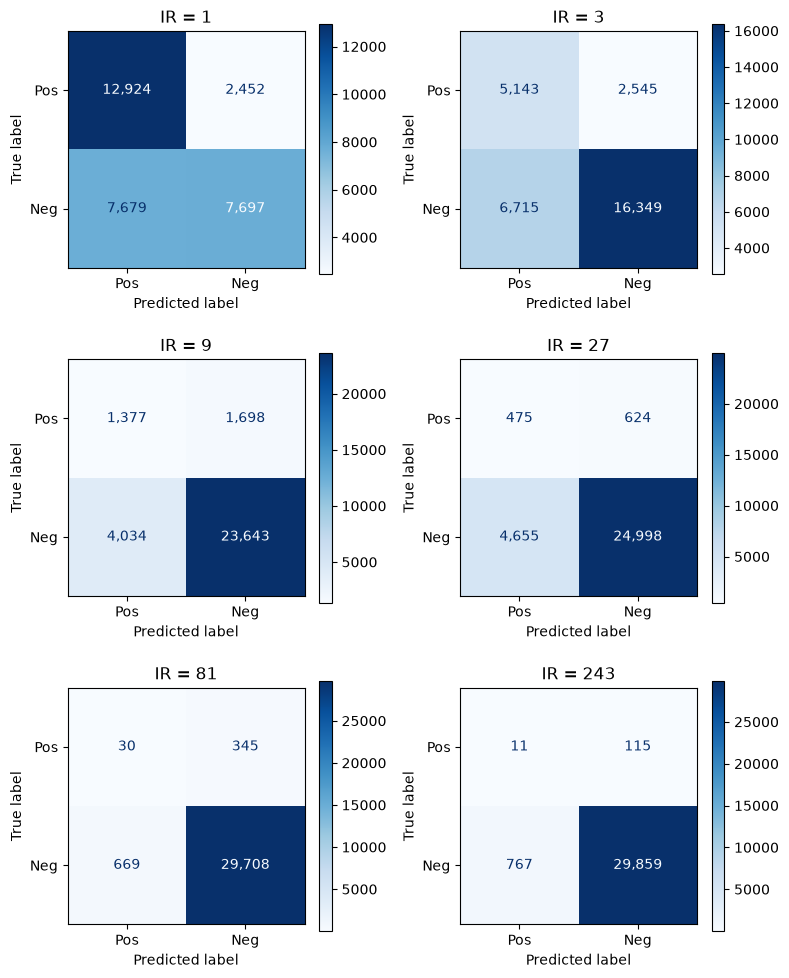


|   IR |   Recall |   Precision |   F1-score |
|------|----------|-------------|------------|
|    1 |    0.841 |       0.627 |      0.718 |
|    3 |    0.669 |       0.434 |      0.526 |
|    9 |    0.448 |       0.255 |      0.325 |
|   27 |    0.432 |       0.093 |      0.152 |
|   81 |    0.081 |       0.043 |      0.056 |
|  243 |    0.090 |       0.015 |      0.025 |


In [219]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from tabulate import tabulate, SEPARATING_LINE

fig, axes = plt.subplots(3, 2, figsize=(8, 10))

tier = 'small'
irs = [1, 3, 9, 27, 81, 243]
metric_rows = []

# Plot confusion matrix for each specified IR
for ax, ir in zip(axes.flatten(), irs):
    cm = weighted_confusion_matrix(tier, ir, 0, 0)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pos', 'Neg'])
    disp.plot(cmap='Blues', values_format=',.0f', ax=ax)
    ax.set_title(f'IR = {ir}')

    # Read the metrics
    metric_rows.append([
        ir,
        get_results(tier, ir, metrics='recall'),
        get_results(tier, ir, metrics='precision'),
        get_results(tier, ir, metrics='f1_score')
    ])

print(f'{tier} tier unaugmented results\n')           # Don't make part of the plot
plt.tight_layout()
plt.savefig('..\\plots\\cm-effect-of-ir.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Tabulate metrics
headers = ['IR', 'Recall', 'Precision', 'F1-score']
table_params = {
    'headers': headers, 
    'floatfmt': '.3f', 
    'tablefmt': 'github'
}
print('\n', tabulate(metric_rows, **table_params), sep='')

### Augmented confusion matrics

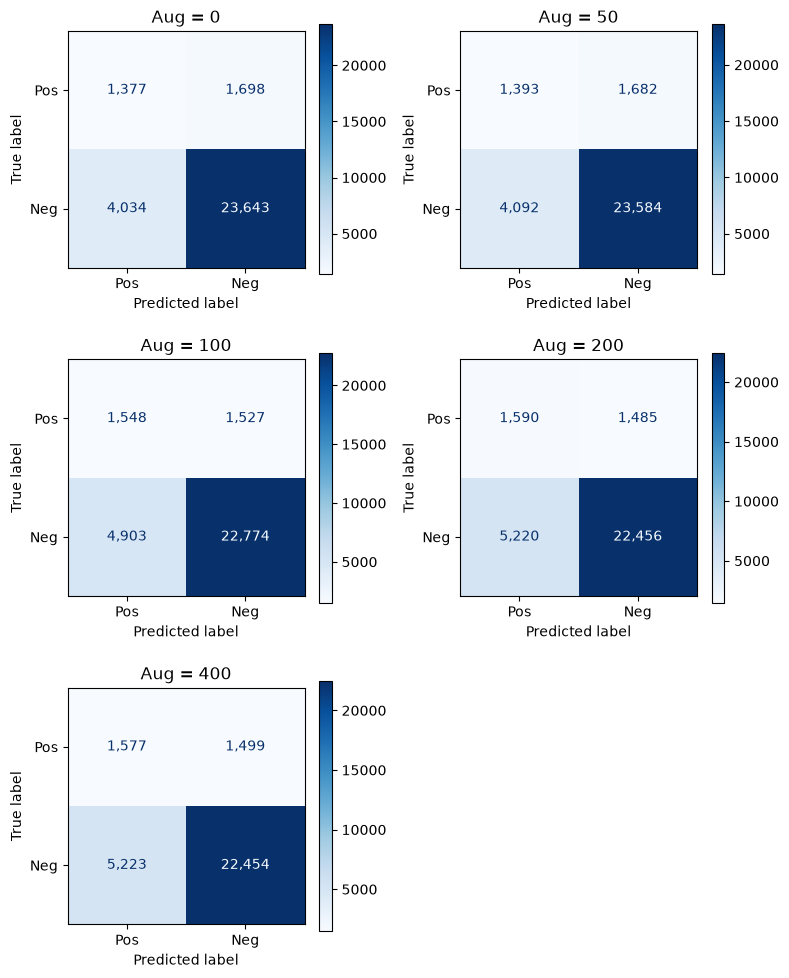

In [83]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


#display = ConfusionMatrixDisplay(cm, display_labels=['Pos', 'Neg'])

#display.plot(cmap="Blues", values_format=",.0f")
#plt.show()

fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes[2,1].axis("off")

augs = [0, 50, 100, 200, 400]

for ax, aug in zip(axes.flatten(), augs):
    cm = weighted_confusion_matrix('small', 9, 0, aug)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pos', 'Neg'])
    disp.plot(cmap='Blues', values_format=',.0f', ax=ax)
    ax.set_title(f'Aug = {aug}')

plt.tight_layout()
plt.show()

### Augmentation with real data

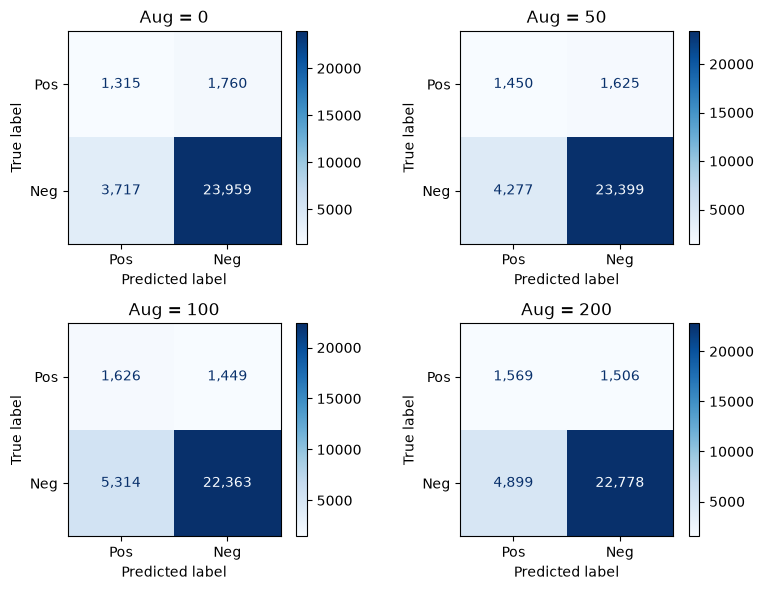

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

#display = ConfusionMatrixDisplay(cm, display_labels=['Pos', 'Neg'])

#display.plot(cmap="Blues", values_format=",.0f")
#plt.show()

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
#axes[2,1].axis("off")

augs = [0, 50, 100, 200]

for ax, aug in zip(axes.flatten(), augs):
    cm = weighted_confusion_matrix('smallaug', 9, 0, aug)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pos', 'Neg'])
    disp.plot(cmap='Blues', values_format=',.0f', ax=ax)
    ax.set_title(f'Aug = {aug}')

plt.tight_layout()
plt.show()

## Plot F1 versus IR and sample size

### Versus IR

F1 versus IR - Natural scale


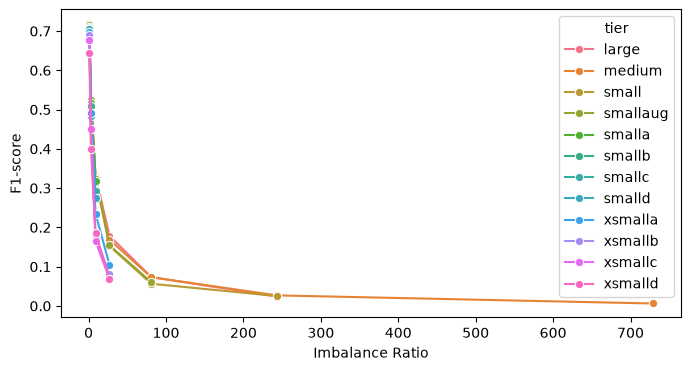

In [302]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

df = xgb_results[xgb_results['aug']==0]

ax = sns.lineplot(
    #data=xgb_results,
    data=df,
    x='ir',
    y='f1_score',
    hue='tier',
    marker='o'
)               
ax.set_ylabel('F1-score')
ax.set_xlabel('Imbalance Ratio')

print('F1 versus IR - Natural scale')
plt.savefig('..\\plots\\f1-vs-ir-natual-scale.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### Versus IR - log scale


F1 Score vs Ln(IR) by Tier


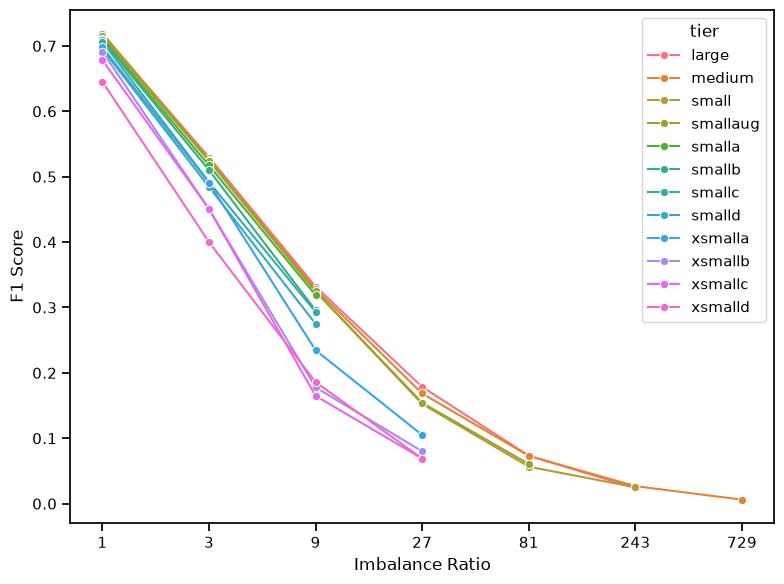

In [787]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator

log_yscale = False

# Make a copy so we don't mutate your original DF
df_plot = xgb_results.copy()
df_plot = df_plot[df_plot['aug']==0]

plt.figure(figsize=(8, 6))

ax = sns.lineplot(
    data=df_plot,
    #x='ln_ir',
    x = 'ir',
    y="f1_score",
    hue='tier',
    marker='o'
)

# Set the log x-axis
ax.set_xscale('log')
irs = sorted(df_plot.ir.unique())
ax.set_xticks(irs)
ax.set_xticklabels([str(int(ir)) for ir in irs])
ax.xaxis.set_minor_locator(NullLocator())

# Set the log y-axis - optionally
if log_yscale:
    ax.set_yscale('log')

#plt.title("F1 vs ln(IR) by Tier")
print('\nF1 Score vs Ln(IR) by Tier')
#plt.xlabel(LOG3IR)
plt.ylabel('F1 Score')
plt.xlabel('Imbalance Ratio')
plt.grid(False)
plt.tight_layout()

plt.savefig('..\\plots\\f1-vs-ir-log-scale.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### Versus sample size - log scale

F1 vs Sample size across IR values


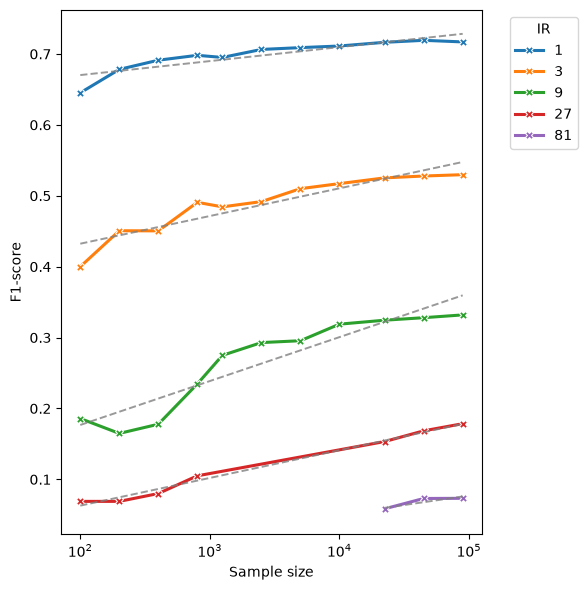

In [346]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy so we don't mutate your original DF
df_plot = xgb_results.copy()
irs = [1, 3, 9, 27, 81]
df_plot = df_plot[df_plot['aug']==0]
df_plot = df_plot[df_plot.ir.isin(irs)]

plt.figure(figsize=(6, 6))

ax = sns.lineplot(
    data=df_plot,
    x='n_train',
    y='f1_score',
    hue='ir_cat',        # multiple IR curves
    marker='X',
    #markersize=4,
    linewidth=2.2
)

# Use colour pallete to select colour for each regression line
palette = sns.color_palette()
for idx, ir in enumerate(irs):
    sns.regplot(
        data=df_plot[df_plot['ir']==ir],
        x='n_train',
        y='f1_score',
        scatter=False,
        logx=True,
        color='grey',
        ci=None,
        line_kws={
            'linestyle': '--',
            'linewidth': 1.4,
            'alpha': 0.8
        },
        ax=ax
    )
ax.set_xscale('log')

# Place the legend to the right of the plot
ax.legend(title='IR', bbox_to_anchor=(1.05, 1), loc='upper left')

print('F1 vs Sample size across IR values')
plt.xlabel("Sample size")
ax.xaxis.set_minor_locator(NullLocator())
plt.ylabel("F1-score")
plt.tight_layout()

plt.savefig('..\\plots\\f1-vs-size-log-scale.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### Combined F1 vs IR and size - log scales

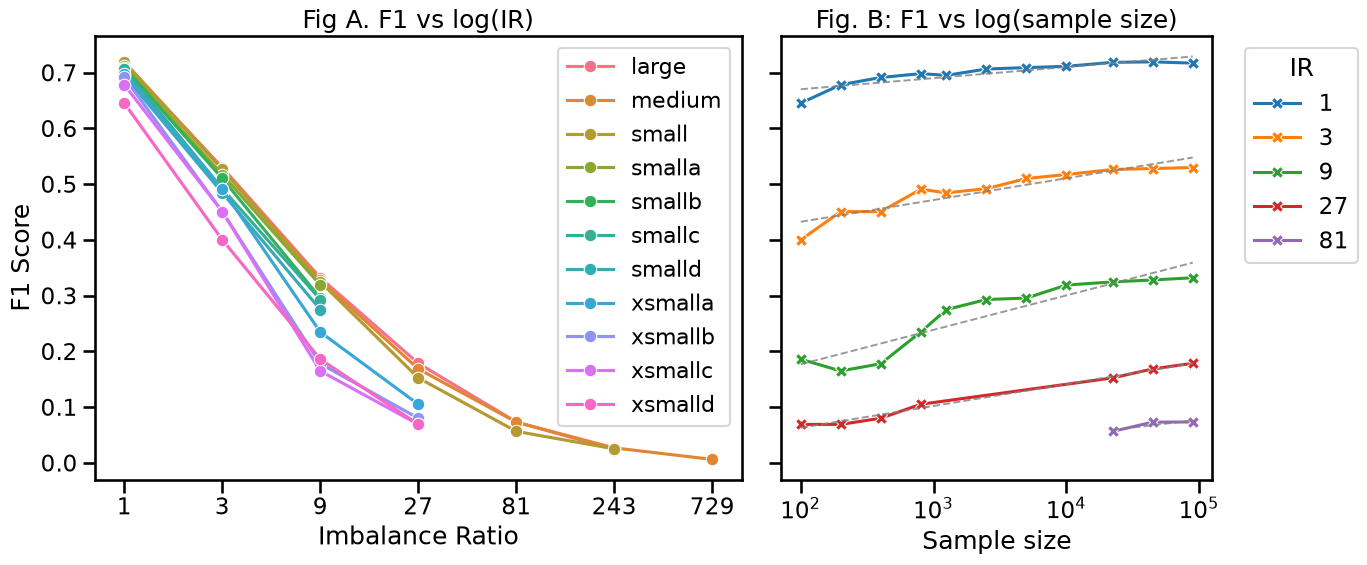

In [386]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator

# Increase all font sizes. Revert back to the original size at the end of the cell
sns.set_context("talk")

fig, axes = plt.subplots(
    1, 2, 
    figsize=(14, 6), 
    sharey=True,
    gridspec_kw={'width_ratios': [3,2]})

# --------------------------------
# Figure A: F1 vs log(IR)
# --------------------------------
df_ir = xgb_results.copy()
df_ir = df_ir[(df_ir.aug==0) & (df_ir.tier != 'smallaug')]

ax = axes[0]
sns.lineplot(
    data=df_ir,
    x='ir',
    y='f1_score',
    hue='tier',
    marker='o',
    ax=ax
)

ax.set_xscale('log')
irs = sorted(df_ir.ir.unique())
ax.set_xticks(irs)
ax.set_xticklabels([str(int(ir)) for ir in irs])
ax.xaxis.set_minor_locator(NullLocator())

# Reduce the legend text size
for text in ax.legend().get_texts():
    text.set_fontsize(16)

ax.set_xlabel('Imbalance Ratio')
ax.set_ylabel('F1 Score')
ax.set_title('Fig A. F1 vs log(IR)')

# --------------------------------
# Figure B: F1 vs log(sample size)
# --------------------------------
df_size = xgb_results.copy()
irs = [1, 3, 9, 27, 81]
df_size = df_size[(df_size.aug == 0) & (df_size.tier != 'smallaug')]
df_size = df_size[df_size.ir.isin(irs)]

ax2 = axes[1]
sns.lineplot(
    data=df_size,
    x='n_train',
    y='f1_score',
    hue='ir_cat',
    marker='X',
    linewidth=2.2,
    ax=ax2
)

# regression overlays (grey dashed)
for ir in irs:
    sns.regplot(
        data=df_size[df_size['ir']==ir],
        x='n_train',
        y='f1_score',
        scatter=False,
        logx=True,
        color='grey',
        ci=None,
        line_kws={'linestyle':'--', 'linewidth':1.4, 'alpha':0.8},
        ax=ax2
    )

ax2.set_xscale('log')
ax2.xaxis.set_minor_locator(NullLocator())
ax2.set_xlabel('Sample size')
ax2.set_ylabel('F1 Score')
ax2.set_title('Fig. B: F1 vs log(sample size)')

# Legend outside panel xB
ax2.legend(title='IR', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.savefig('..\\plots\\f1-vs-ir-and-size.png', dpi=300, bbox_inches='tight')
plt.show()

# Revert the context back to the original notebook context
sns.set_context("notebook")

### F1 Loss versus IR and sample size

In [788]:
# Create a table of F1 loss by tier and IR

# Select scenarios to give good coverage of experimental grid
unaug_df = xgb_results[(xgb_results.aug == 0) & 
    ((xgb_results.n_train > 10000) | (xgb_results.n_train <= 800))]

# Pivot the sample size into the columns. 
pivot = unaug_df.pivot_table(
    index='ir',
    columns='n_train',
    values='f1_loss').round(3)
pivot = pivot[sorted(pivot.columns, reverse=True)]

pivot

n_train,89368,44684,22342,800,400,200,100
ir,,,,,,,
3.0,0.187,0.191,0.191,0.207,0.241,0.228,0.245
9.0,0.385,0.391,0.392,0.464,0.513,0.513,0.459
27.0,0.538,0.551,0.563,0.593,0.611,0.609,0.576
81.0,0.644,0.646,0.658,NaN,NaN,NaN,NaN
243.0,0.693,0.692,0.693,NaN,NaN,NaN,NaN
729.0,NaN,0.713,NaN,NaN,NaN,NaN,NaN


### F1 versus sample size slope

In [840]:
from sklearn.linear_model import LinearRegression

#Calculate the gradient of the loss vs ln(sample size) curves for each IR

print('F1 LOSS VERSUS IR\n')
print('  IR  Max F1  Min F1  F1 Loss   Slope       C')
print('---------------------------------------------')
for ir in [1, 3, 9, 27, 81]:
    idx_max = f'large-ir{ir:03d}-aug000'
    idx_min = f'xsmalld-ir{ir:03d}-aug000'
 
    # Calculate the loss between max and min samples sizes for each IR
    if ir==81:
        print('  81       -       -        -', end='')
    else:
        n_train, min_result = xgb_results.loc[idx_min, ['n_train', 'f1_score']]
        max_result = xgb_results.loc[idx_max, 'f1_score']
        
        print(f'{ir:4d}   {max_result:5.3f}   {min_result:5.3f}' \
        f'    {max_result-min_result:5.3f}', end='')

    # Calculate the gradient for each IR
    rows = xgb_results[(xgb_results.ir==ir) & (xgb_results.aug==0)]
    X = rows.ln_n_train.values.reshape(-1, 1)
    Y = rows.f1_score.values
    reg = LinearRegression().fit(X, Y)
    slope = reg.coef_[0]
    intercept = reg.intercept_
    print(f'   {slope:5.3f}  {intercept:6.3f}')

F1 LOSS VERSUS IR

  IR  Max F1  Min F1  F1 Loss   Slope       C
---------------------------------------------
   1   0.717   0.645    0.072   0.020   0.631
   3   0.530   0.400    0.130   0.039   0.354
   9   0.332   0.186    0.146   0.062   0.053
  27   0.179   0.069    0.110   0.039  -0.015
  81       -       -        -   0.027  -0.056


## Metrics versus IR - log scale

### Plotting function (`metrics_vs_log_ir`)

In [391]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def metrics_vs_log_ir(df, model):

    # Prepare DF
    df_plot = df.copy()
    df_plot = df_plot[df_plot['aug'] == 0]
    
    # Exclude the extra-small scenario which have a limited range of IRs
    df_plot = df_plot[~df_plot['tier'].isin(xsmall_scenarios)]
    
    # Exclude the large IR 1 scenario which was created artificially
    df_plot = df_plot[~((df_plot.tier == 'large') & (df_plot.ir == 1))]

    # Exclude smallaug which is a copy of small
    #df_plot = df_plot[df_plot.tier != 'smallaug']
    
    # Add ln(IR) base-3
    df_plot['ln_ir'] = np.log(df_plot['ir']) / np.log(3)
    
    # Metrics to plot
    metrics = [
        ('threshold', 'Best Threshold'),
        ('log_loss_u', 'Log Loss'),
        ('roc_auc_u', 'ROC-AUC'),
        ('pr_auc_u', 'PR-AUC'),
        ('recall', 'Recall'),
        ('precision', 'Precision')
    ]
    
    # Create grid
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    axes = axes.flatten()
    
    for ax, (metric_col, metric_label) in zip(axes, metrics):
        sns.lineplot(
            data=df_plot,
            #x='ln_ir',
            x='ir',
            y=metric_col,
            hue='tier',
            marker='o',
            ax=ax
        )
        ax.set_title(metric_label)
        ax.set_xlabel('Imbalance Ratio')
        ax.set_ylabel(metric_label)
    
        # Set the log scale
        irs = sorted(df_plot.ir.unique())
        ax.set_xscale('log')
        ax.set_xticks(irs)
        ax.set_xticklabels([str(int(ir)) for ir in irs])
        ax.xaxis.set_minor_locator(NullLocator())

    # Display and save the plot
    print(f'Metrics versus log IR for {model}')
    plt.tight_layout()
    plt.savefig('..\\plots\\metrics-vs-log-ir-{model}.png', dpi=300, bbox_inches='tight')
    plt.show()

### XGBoost

Metrics versus log IR for xgb


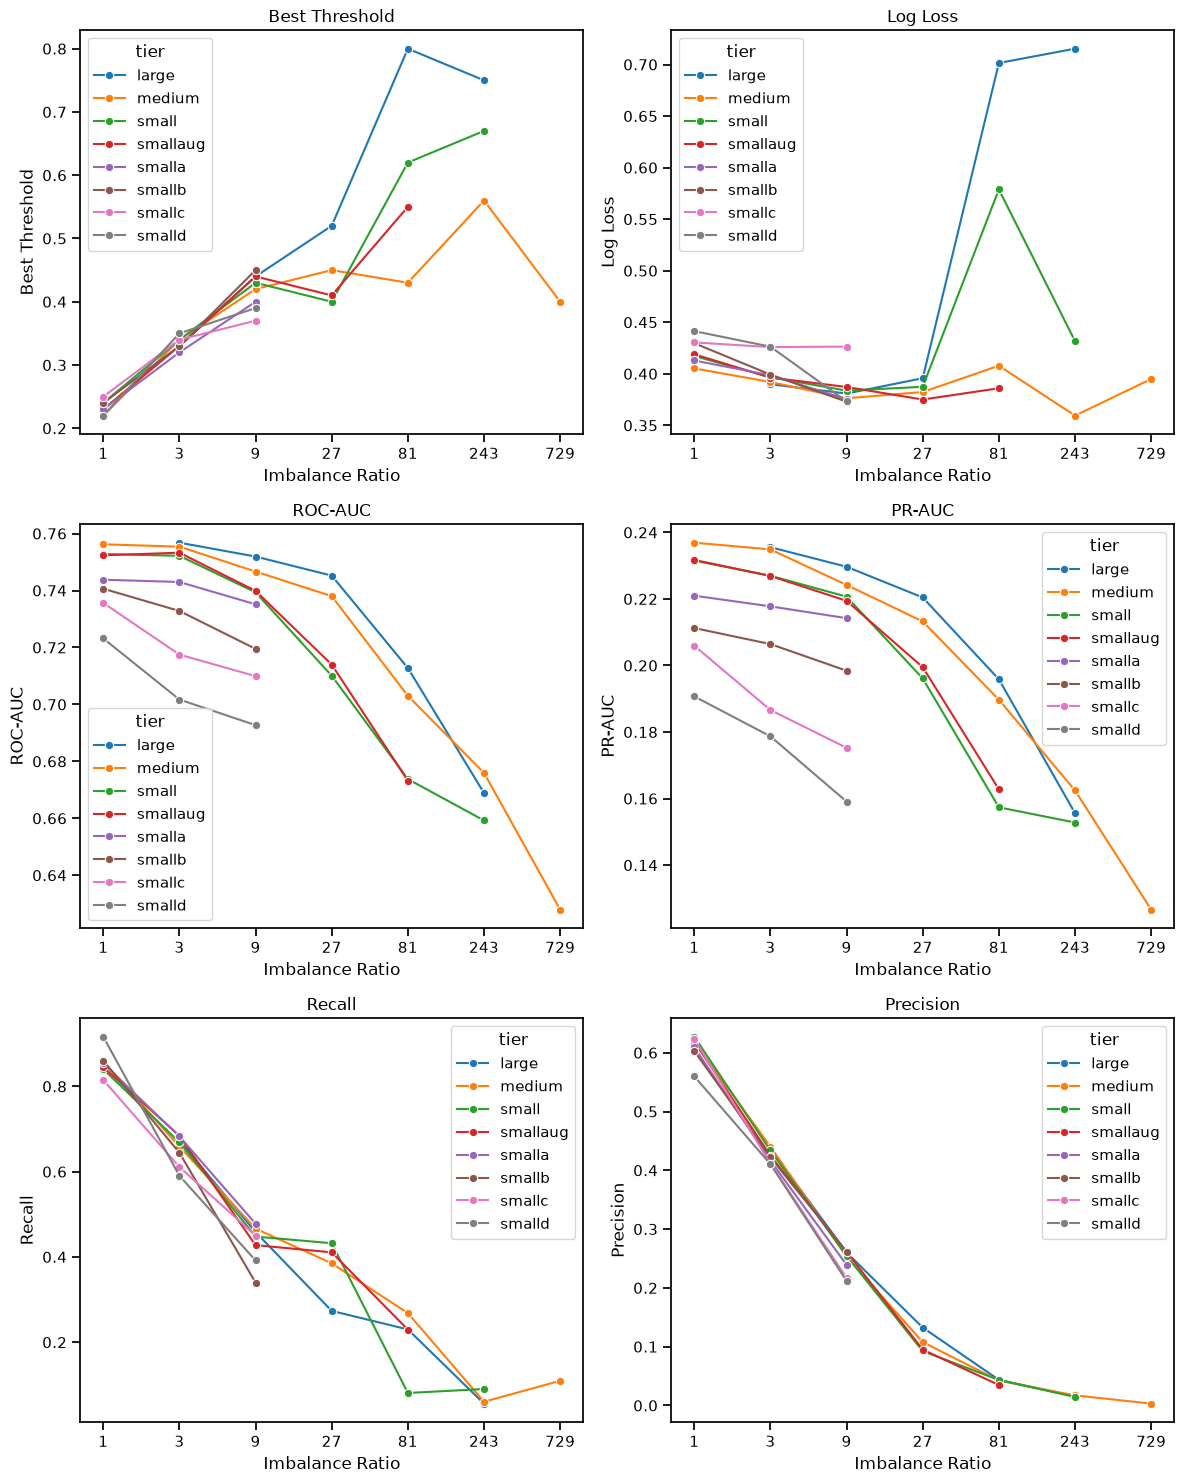

In [392]:
metrics_vs_log_ir(xgb_results, 'xgb')

### Gaussian Naive Bayes

Metrics versus log IR for gnb


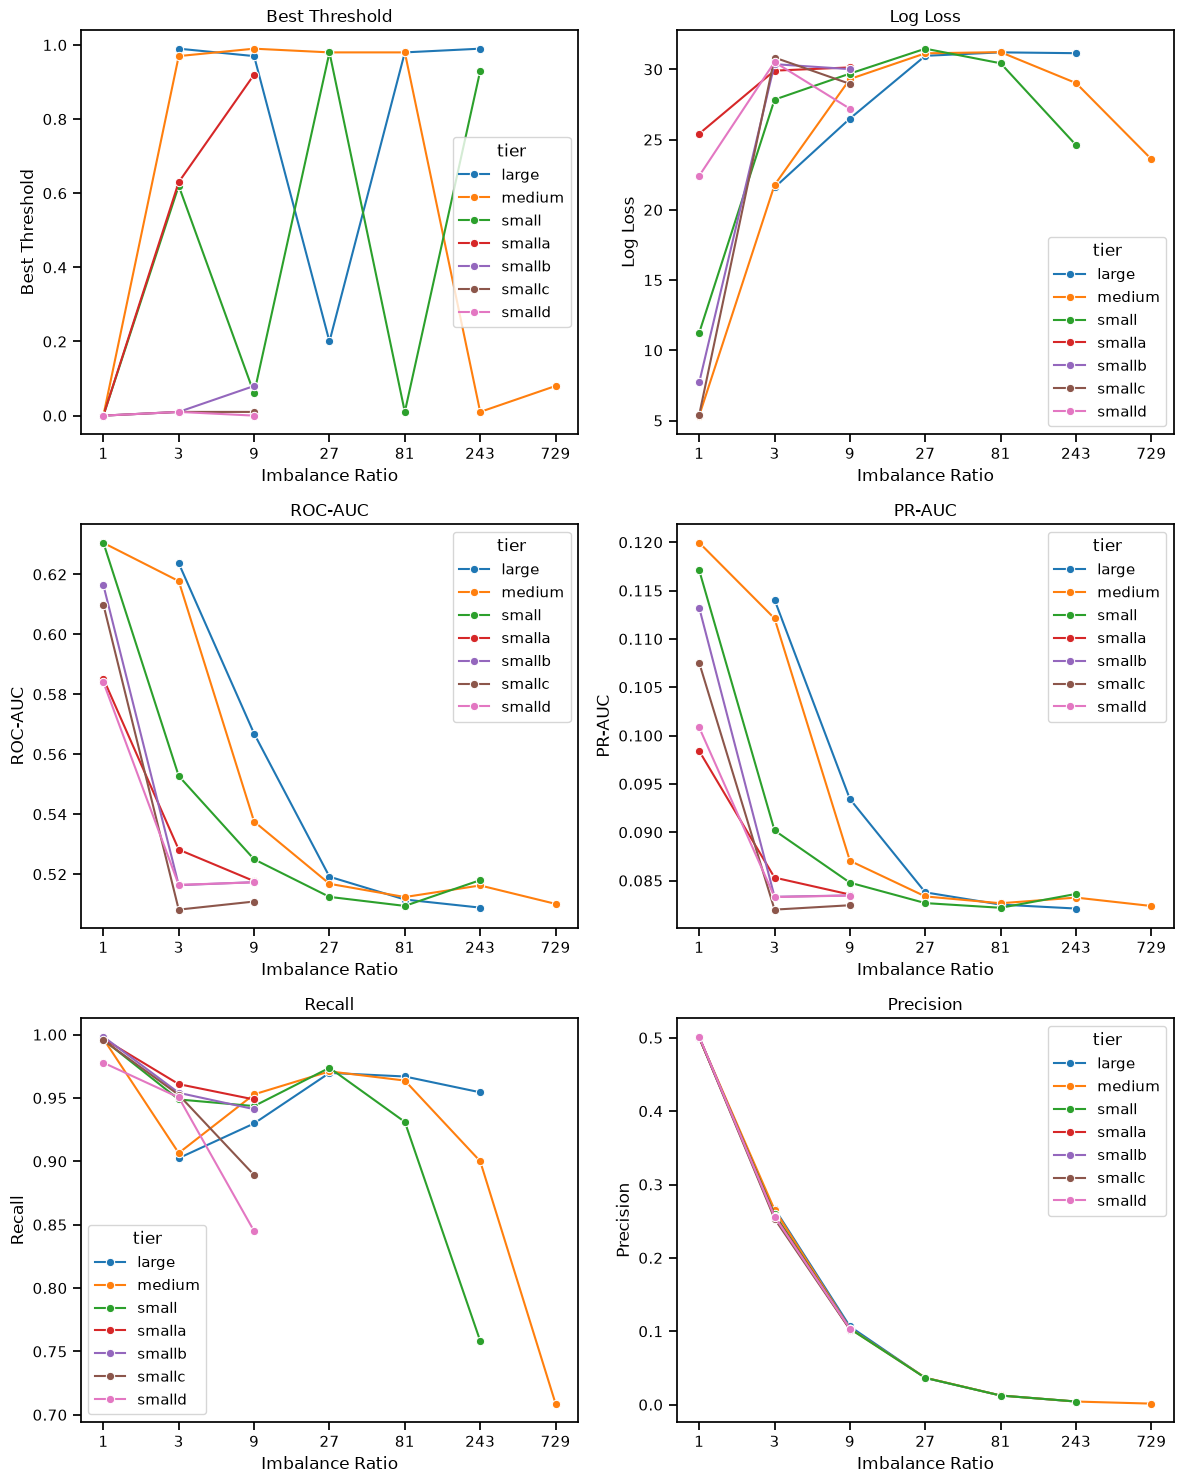

In [380]:
metrics_vs_log_ir(gnb_results, 'gnb')

## Metrics versus IR - natural scale

### Plotting function (`metric_vs_ir`)

In [372]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def metrics_vs_ir(df, model):# Prepare DF
    df_plot = df.copy()
    df_plot = df_plot[df_plot['aug'] == 0]
    
    # Exclude the extra-small scenario which have a limited range of IRs
    df_plot = df_plot[~df_plot['tier'].isin(xsmall_scenarios)]
    
    # Exclude the large IR 1 scenario which was created artificially
    df_plot = df_plot[~((df_plot.tier == 'large') & (df_plot.ir == 1))]
    
    # Add ln(IR) base-3
    df_plot['ln_ir'] = np.log(df_plot['ir']) / np.log(3)
    
    # Metrics to plot
    metrics = [
        ('threshold', 'Best Threshold'),
        ('log_loss_u', 'Log Loss'),
        ('roc_auc_u', 'ROC-AUC'),
        ('pr_auc_u', 'PR-AUC'),
        ('recall', 'Recall'),
        ('precision', 'Precision')
    ]
    
    # Create grid
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    axes = axes.flatten()
    
    for ax, (metric_col, metric_label) in zip(axes, metrics):
        sns.lineplot(
            data=df_plot,
            #x='ln_ir',
            x='ir',
            y=metric_col,
            hue='tier',
            marker='o',
            ax=ax
        )
        ax.set_title(metric_label)
        ax.set_xlabel('Imbalance Ratio')
        ax.set_ylabel(metric_label)
    
        if False:
            # Set the log scale
            irs = sorted(df_plot.ir.unique())
            ax.set_xscale('log')
            ax.set_xticks(irs)
            ax.set_xticklabels([str(int(ir)) for ir in irs])
            ax.xaxis.set_minor_locator(NullLocator())
    
    # Display and save the plot
    print(f'Metrics versus IR for {model} model')
    plt.tight_layout()
    plt.savefig(f'..\\plots\\metrics-vs-ir-{model}.png', dpi=300, bbox_inches='tight')
    plt.show()

### XGBoost

Metrics versus IR for xgb model


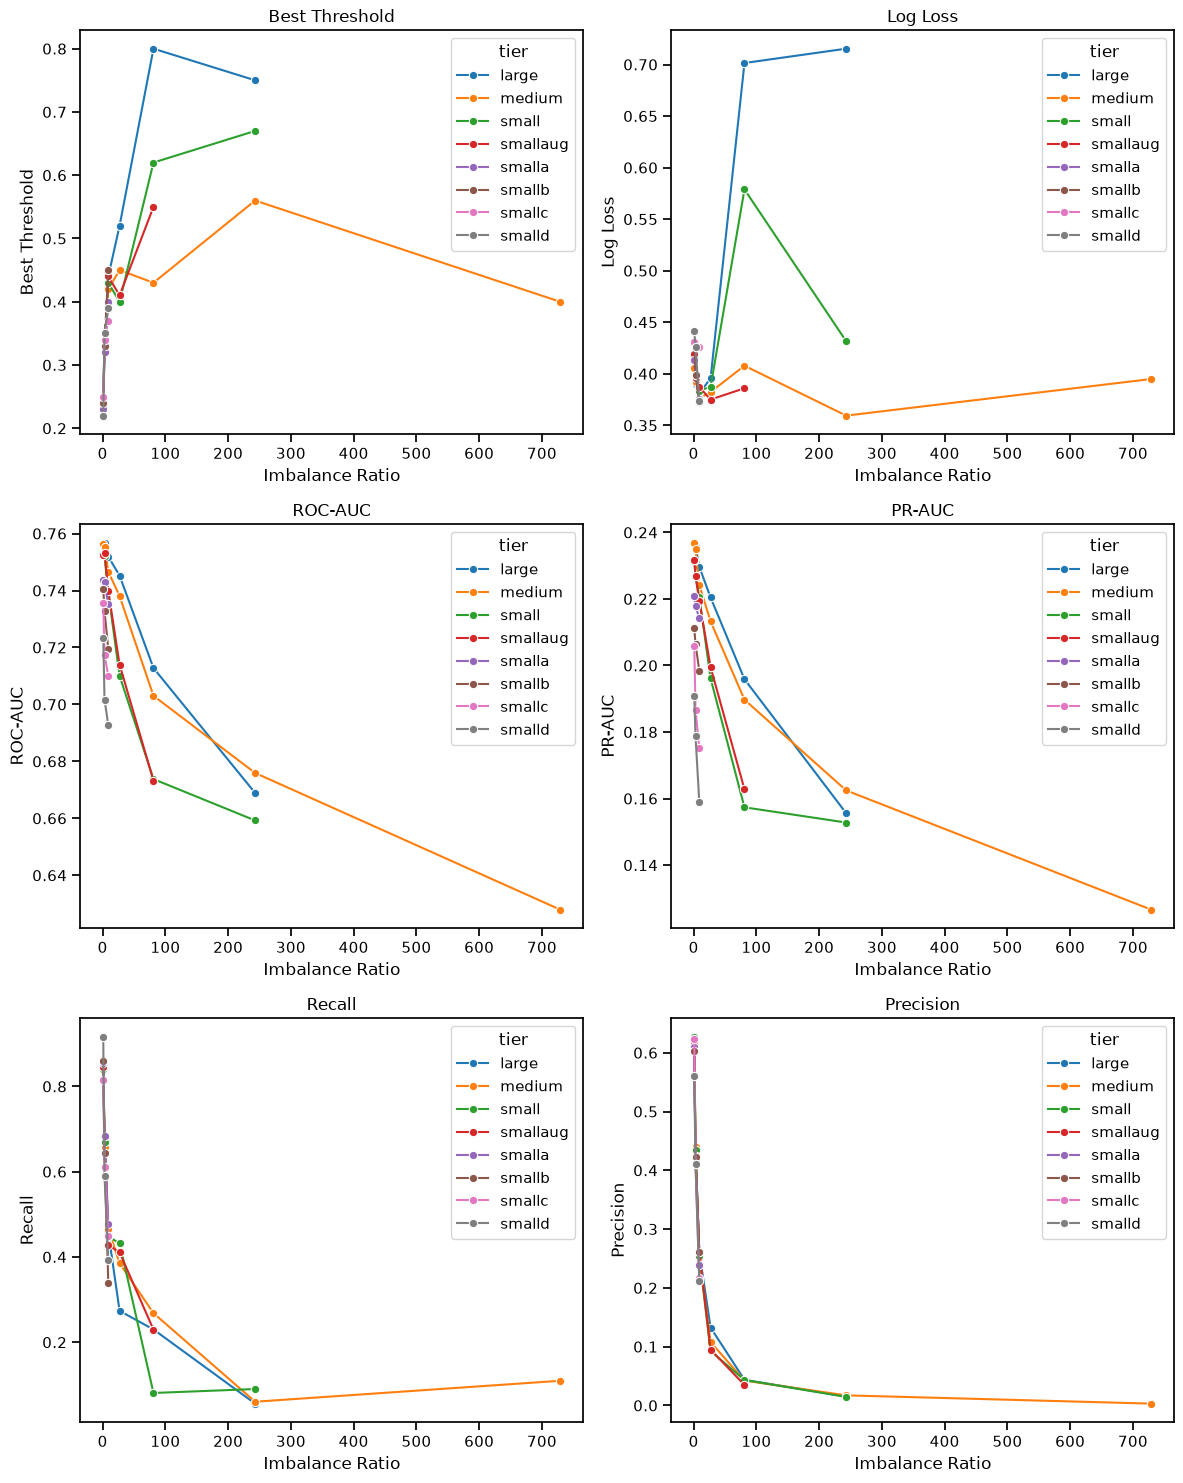

In [373]:
metrics_vs_ir(xgb_results, 'xgb')

### Gaussian Naive Bayes

Metrics versus log IR for gnb


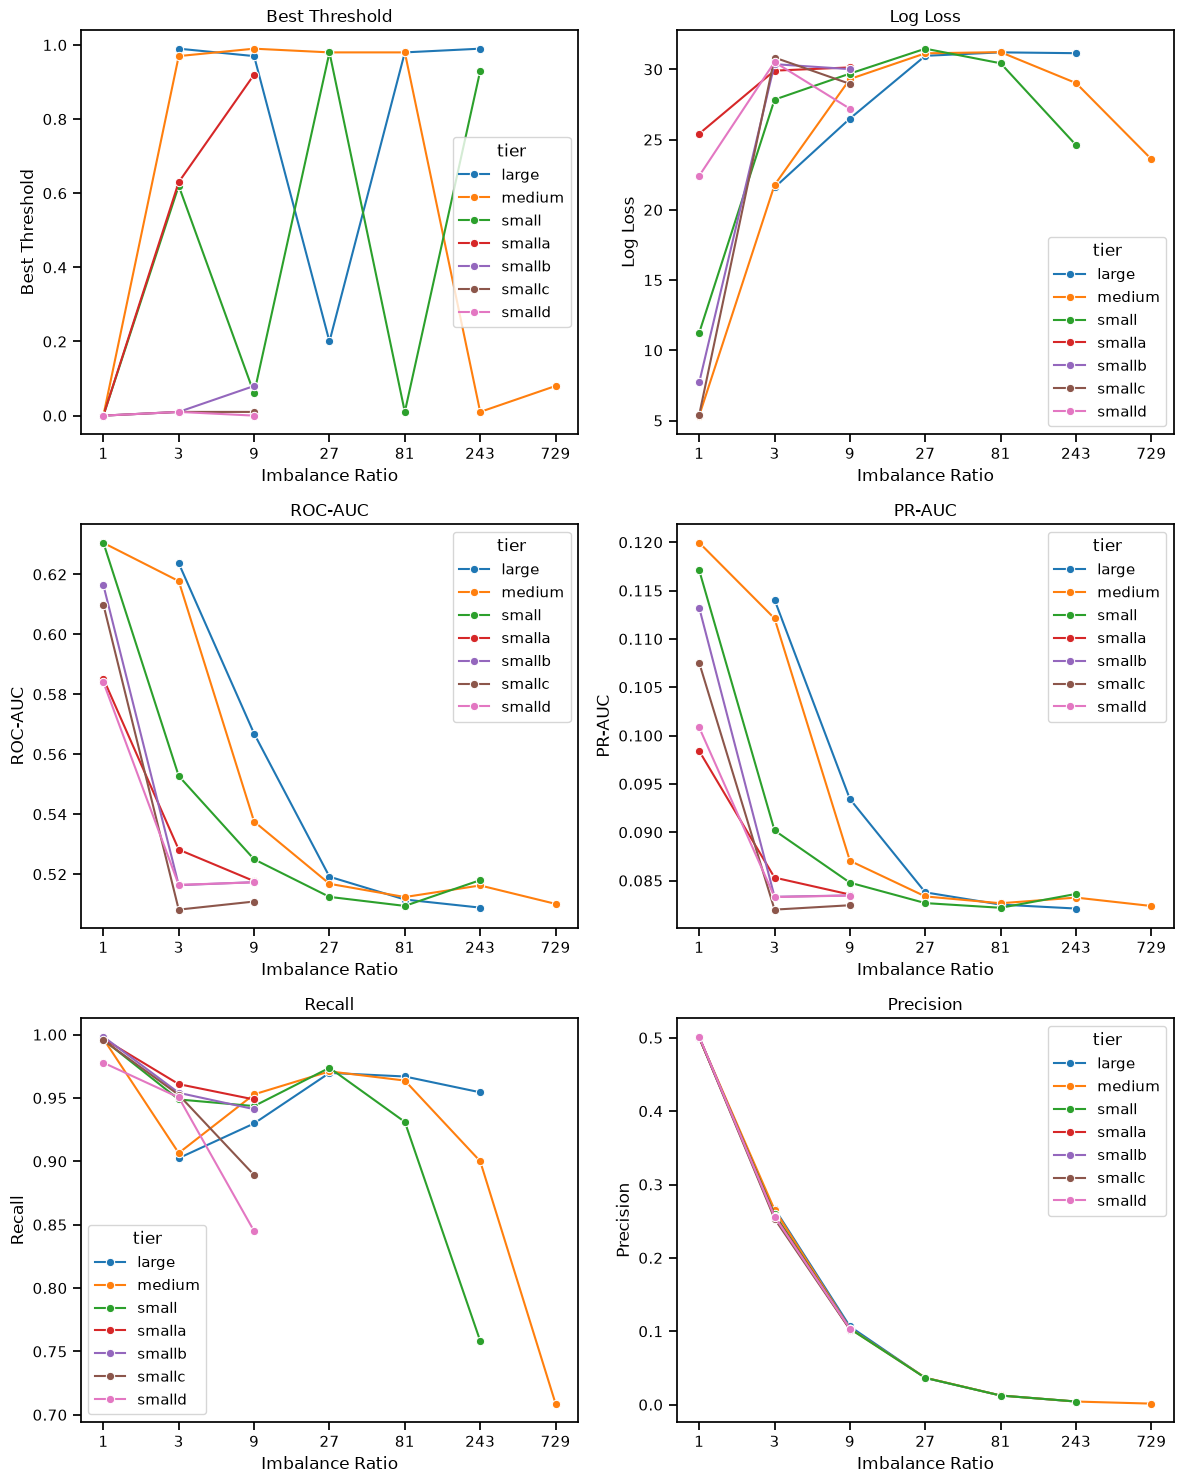

In [381]:
metrics_vs_log_ir(gnb_results, 'gnb')

## Metrics versus augmentation level

### Metric versus augmentation - all IRs - one grid

In [550]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def metric_vs_aug(df, tier, model='xgb', log=True, maxaug=1000):

    # Copy the tier from the source DataFrame. Only include imbalanced scenarios
    df_plot = df[(df['tier'] == tier) & (df.ir != 1)].copy()
    df_plot['ir'] = df_plot['ir'].astype('category')

    # Limit the augmentation range to increase the x-scale 
    df_plot= df_plot[df_plot.aug <= maxaug]
    
    # Metrics to plot
    metrics = [
        ('threshold', 'Best Threshold'),
        ('log_loss_u', 'Log Loss'),
        ('roc_auc_u', 'ROC-AUC'),
        ('pr_auc_u', 'PR-AUC'),
        ('recall', 'Recall'),
        ('precision', 'Precision'),
        ('f1_score', 'F1-Score'),
    ]

    # Build the 2×4 grid
    fig, axes = plt.subplots(4, 2, figsize=(9, 12), sharey=False)
    axes = axes.flatten()
    
    for ax, (metric, title) in zip(axes, metrics):
        sns.lineplot(
            data=df_plot,
            x='aug',          # augmentation level
            y=metric,         # ROC AUC
            hue='ir_cat',     # IR
            style='ir_cat',
            markers=True,
            markersize=8,
            dashes=False,
            ax=ax
        )
        ax.set_xlabel('Augmentation Level (%)')
        ax.set_ylabel(title)
        # Optionally use a log x-scale
        if log:
            ax.set_xscale('log')

        # Add horizontal grid lines
        ax.grid(True, axis='y', color='lightgrey', linewidth=1.0, alpha=0.75)

        # Legend outside panel
        ax.legend(title='IR', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Create one legend for the figure. PLace in the 8th, unused plot.

    # Extract handles/labels from the first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    
    # Remove legends from all subplots
    for ax in axes[: -1]:
        ax.legend().remove()

    # Add one legend for the whole figure
    #fig.legend(handles, labels, loc='lower center', ncol=len(labels))
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1.0))
    
    # Save and display the figure
    print(f'\nMetric versus augmentation level (%) for {tier} tier and {model} model\n')
    axes[-1].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'..\\plots\\metrics-vs-aug-{tier}-{model}.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()

### Metric versus augmentation - all IRs - multiple figures

In [487]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def metric_vs_aug_mult(df, tier, metrics, model='xgb', log=True, maxaug=1000):

    # Copy the tier from the source DataFrame. Only include imbalanced scenarios
    df_plot = df[(df['tier'] == tier) & (df.ir != 1)].copy()
    df_plot['ir'] = df_plot['ir'].astype('category')

    # Limit the augmentation range to increase the x-scale 
    df_plot= df_plot[df_plot.aug <= maxaug]
    
    # Metrics to plot
    metric_titles = {
        'threshold': 'Best Threshold',
        'log_loss_u': 'Log Loss',
        'roc_auc_u': 'ROC-AUC',
        'pr_auc_u': 'PR-AUC',
        'recall': 'Recall',
        'precision': 'Precision',
        'f1_score': 'F1-Score',
    }
    
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.lineplot(
            data=df_plot,
            x='aug',          # augmentation level
            y=metric,         # ROC AUC
            hue='ir_cat',     # IR
            style='ir_cat',
            markers=True,
            markersize=8,
            dashes=False,
            ax=ax
        )
        ax.set_xlabel('Augmentation Level (%)')
        ax.set_ylabel(metric_titles[metric])
        # Optionally use a log x-scale
        if log:
            ax.set_xscale('log')

        # Legend outside panel
        ax.legend(title='IR', bbox_to_anchor=(1.05, 1), loc='upper left')

        # Add horizontal grid lines
        ax.grid(True, axis='y', color='lightgrey', linewidth=1.0, alpha=0.75)
        
        # Display the figure
        print(f'\nMetric versus augmentation level (%) for {tier} tier and {model} model\n')
        plt.tight_layout()
        plt.show()

### XGBoost


Metric versus augmentation level (%) for small tier and xgb model



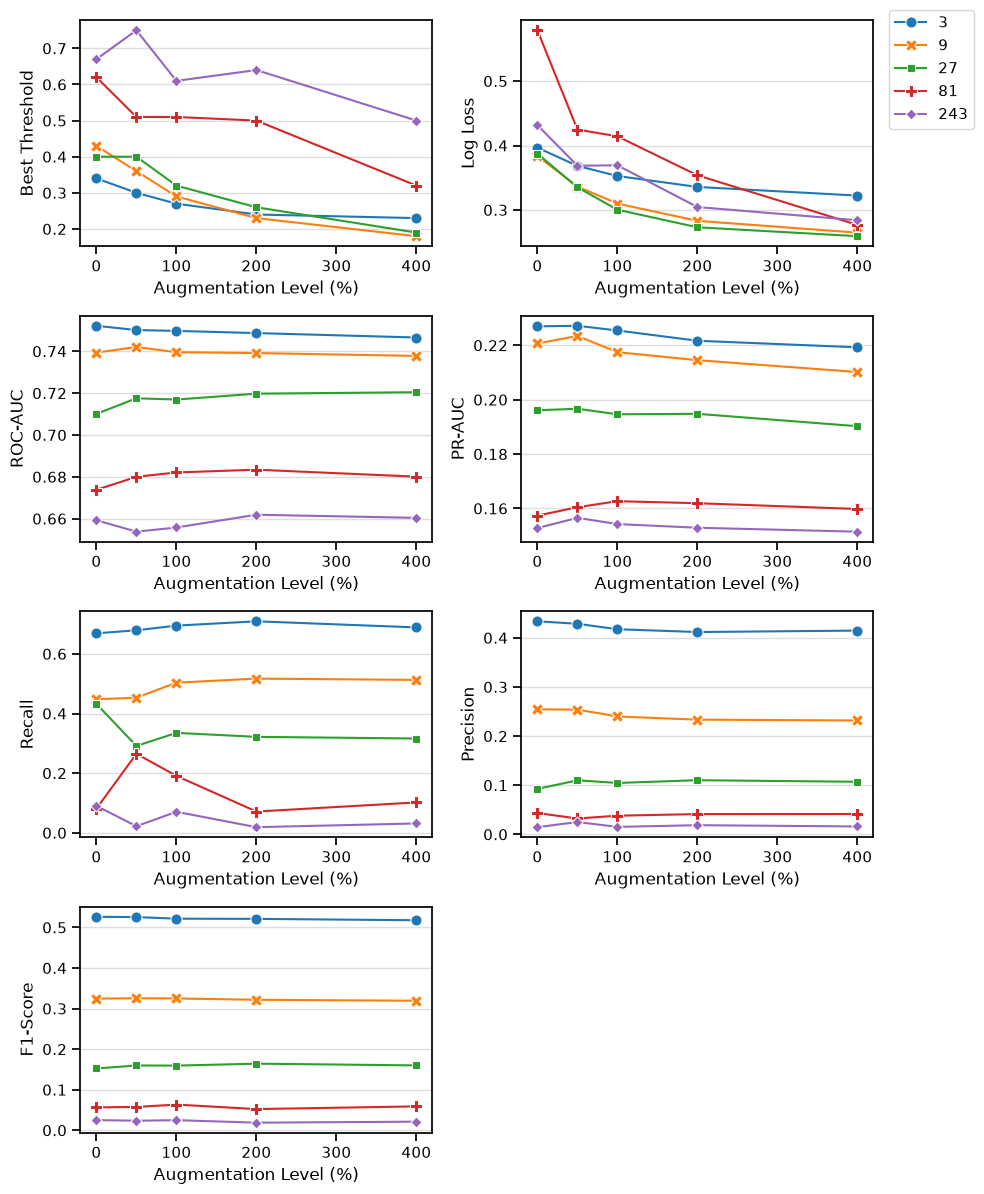

In [551]:
metric_vs_aug(xgb_results, 'small', 'xgb', log=False, maxaug=400)

small tier results
------------------

Metric versus augmentation level (%) for small tier and xgb model



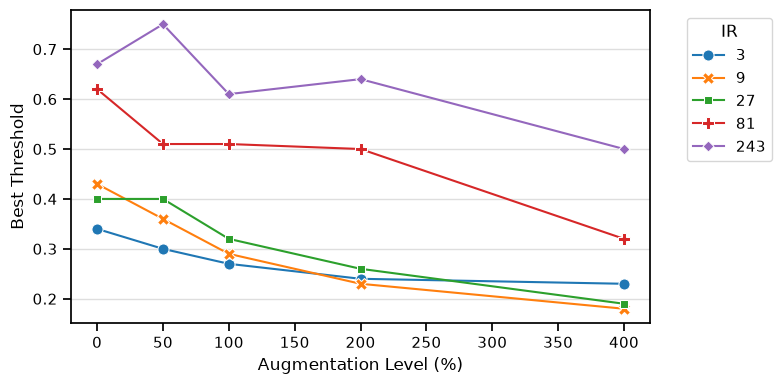


Metric versus augmentation level (%) for small tier and xgb model



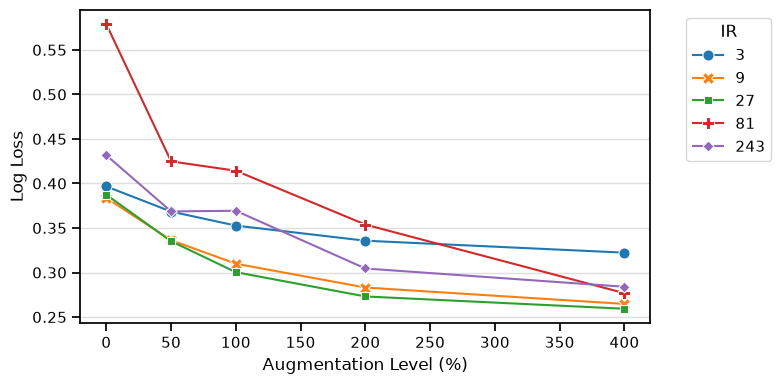


Metric versus augmentation level (%) for small tier and xgb model



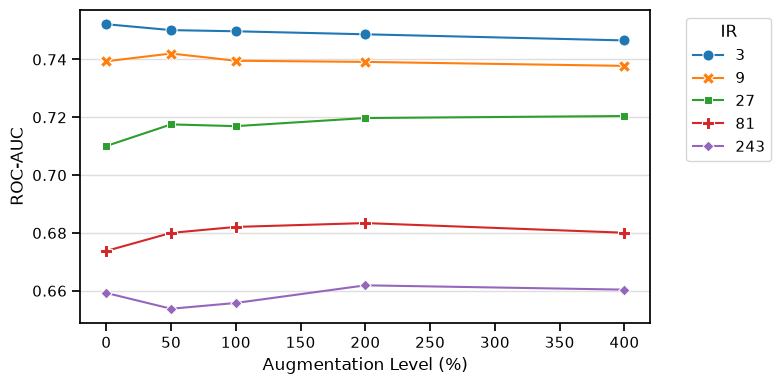


Metric versus augmentation level (%) for small tier and xgb model



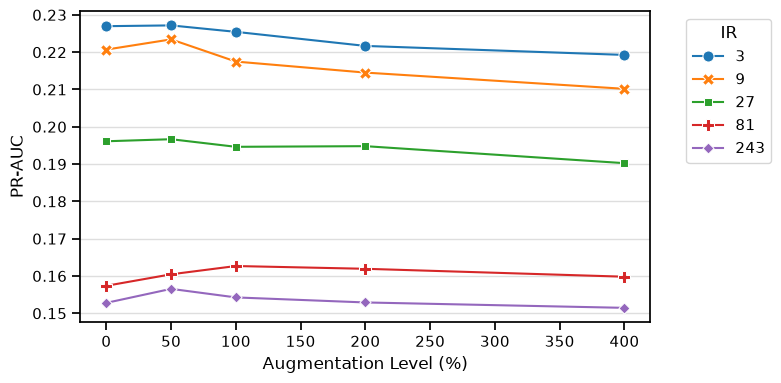


Metric versus augmentation level (%) for small tier and xgb model



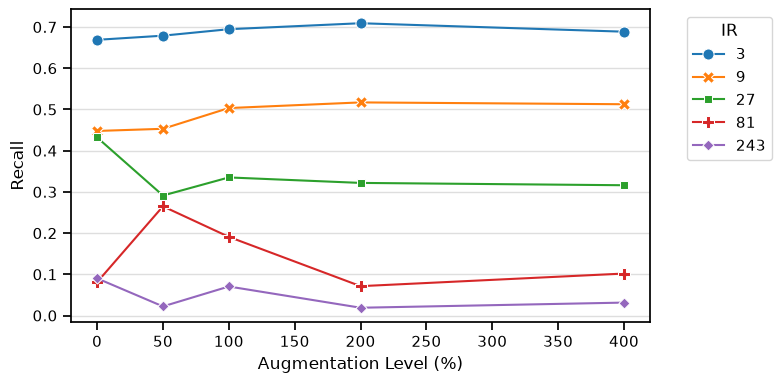


Metric versus augmentation level (%) for small tier and xgb model



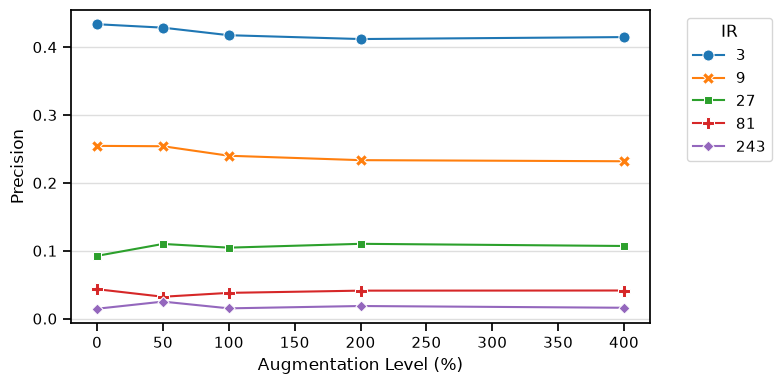


Metric versus augmentation level (%) for small tier and xgb model



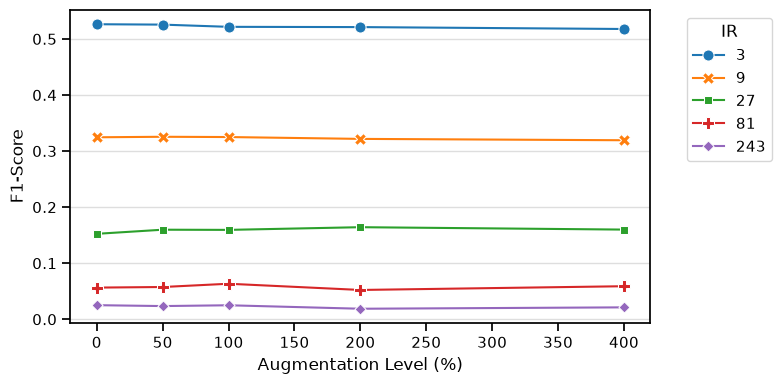

medium tier results
------------------

Metric versus augmentation level (%) for medium tier and xgb model



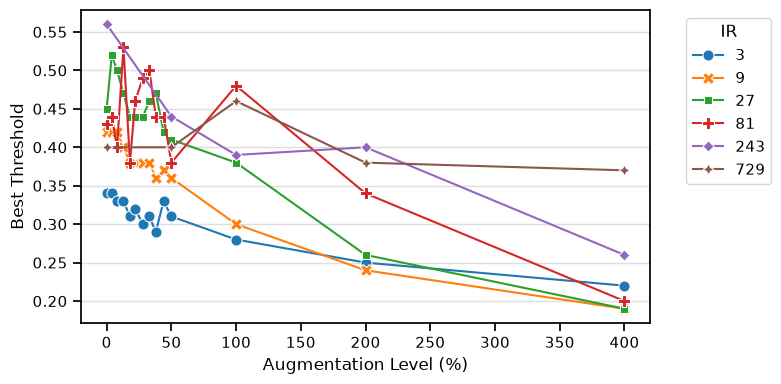


Metric versus augmentation level (%) for medium tier and xgb model



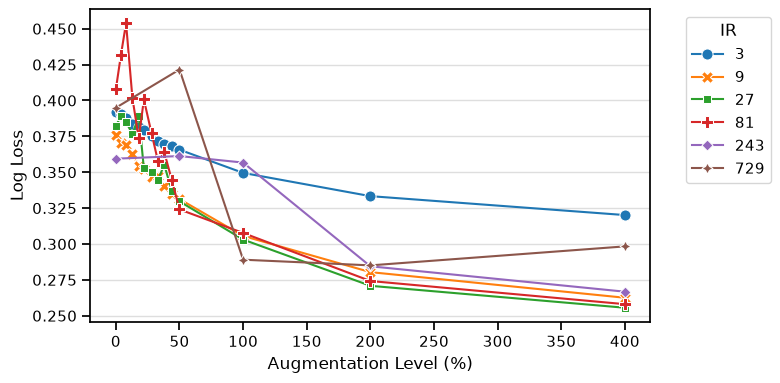


Metric versus augmentation level (%) for medium tier and xgb model



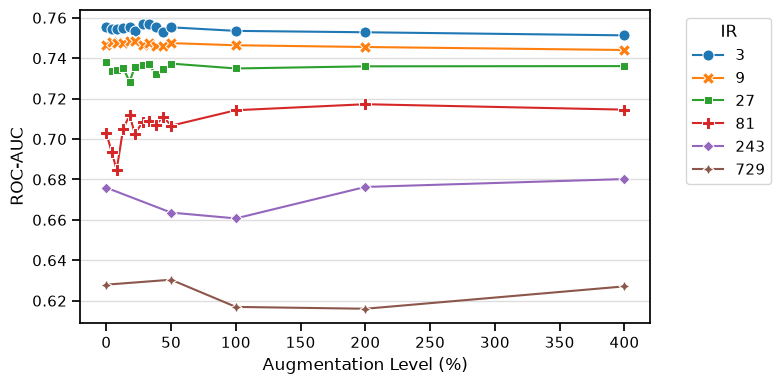


Metric versus augmentation level (%) for medium tier and xgb model



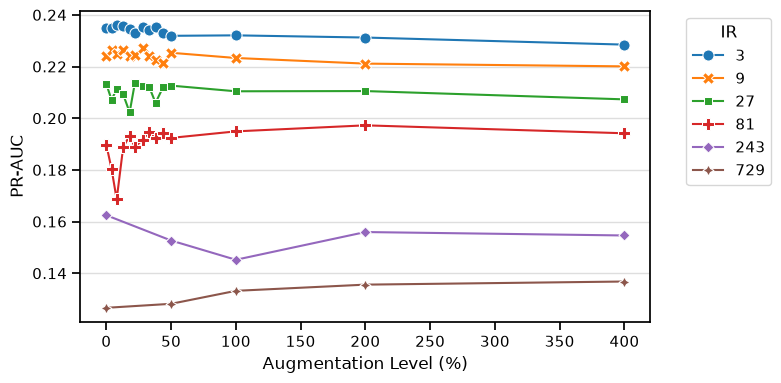


Metric versus augmentation level (%) for medium tier and xgb model



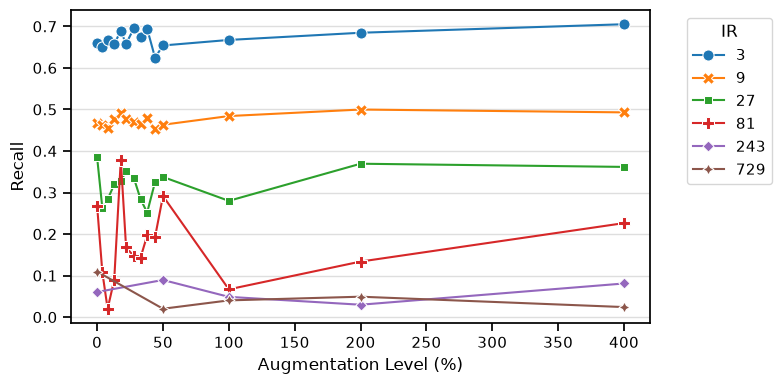


Metric versus augmentation level (%) for medium tier and xgb model



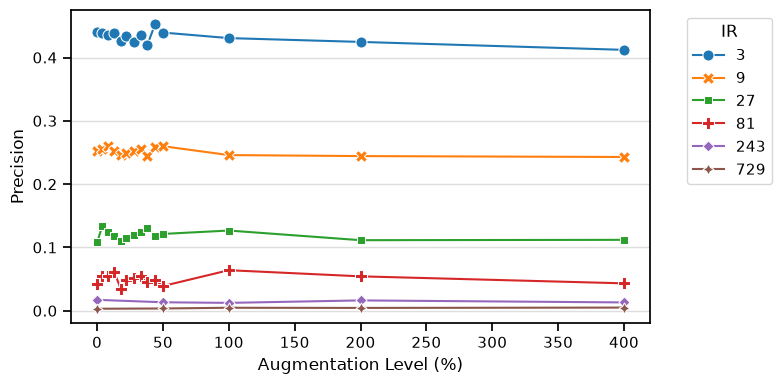


Metric versus augmentation level (%) for medium tier and xgb model



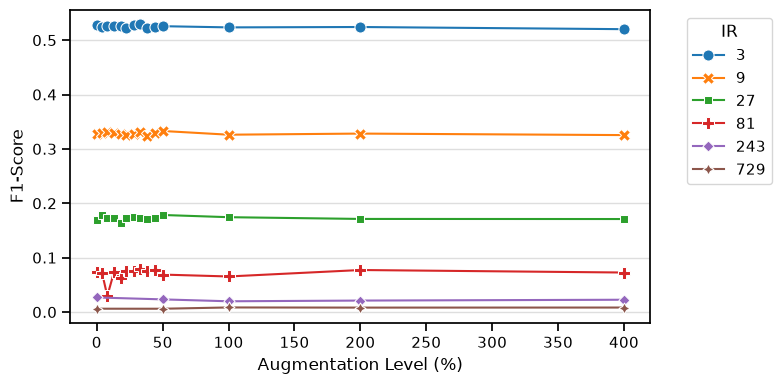

large tier results
------------------

Metric versus augmentation level (%) for large tier and xgb model



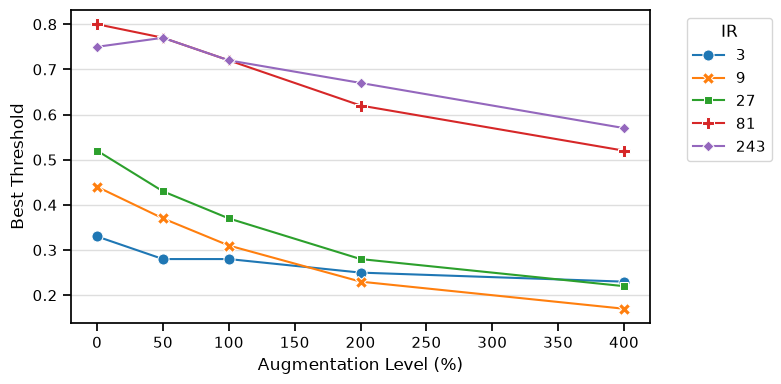


Metric versus augmentation level (%) for large tier and xgb model



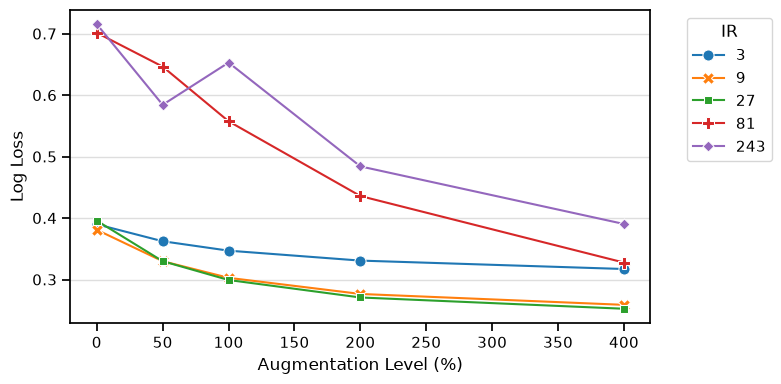


Metric versus augmentation level (%) for large tier and xgb model



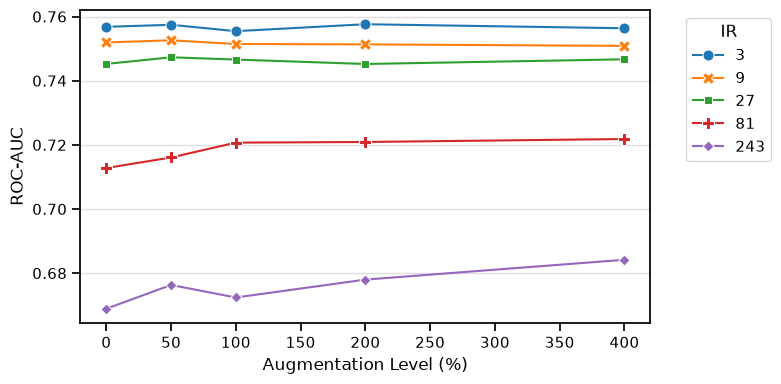


Metric versus augmentation level (%) for large tier and xgb model



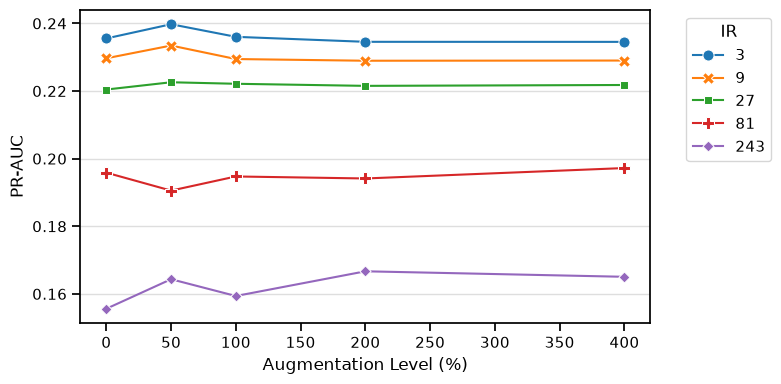


Metric versus augmentation level (%) for large tier and xgb model



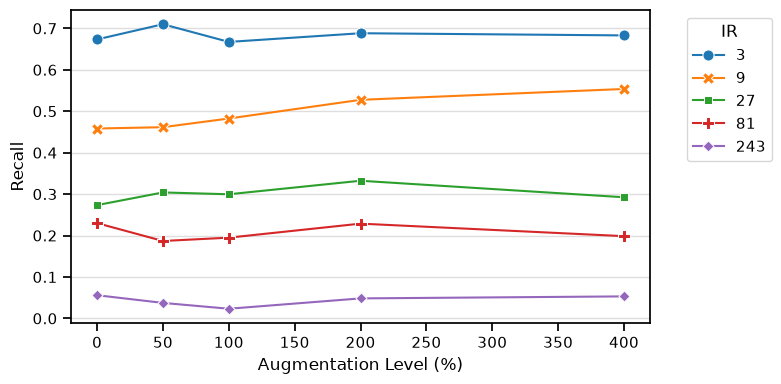


Metric versus augmentation level (%) for large tier and xgb model



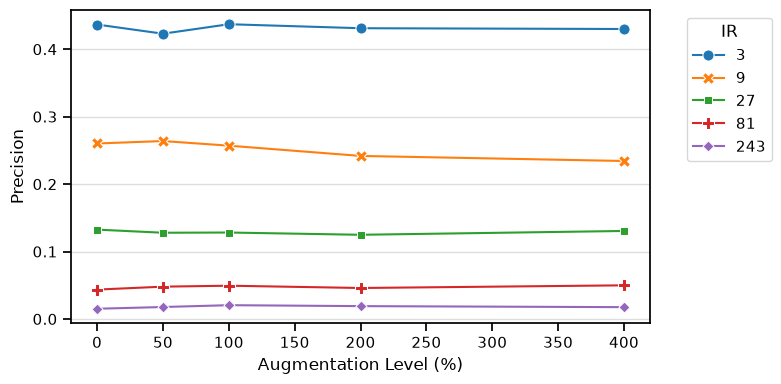


Metric versus augmentation level (%) for large tier and xgb model



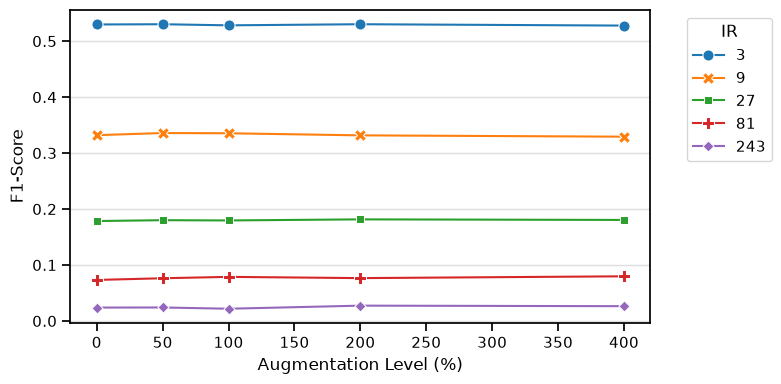

In [477]:
all_metrics = ['threshold', 'log_loss_u', 'roc_auc_u', 'pr_auc_u', 'recall', 'precision', 'f1_score']

for tier in ['small', 'medium', 'large']:
    print(f'{tier} tier results')
    print('------------------')
    metric_vs_aug_mult(xgb_results, tier, all_metrics, 'xgb', False, 400)

### Gaussian Naive Bayes


Metric versus augmentation level (%) for small tier and gnb model



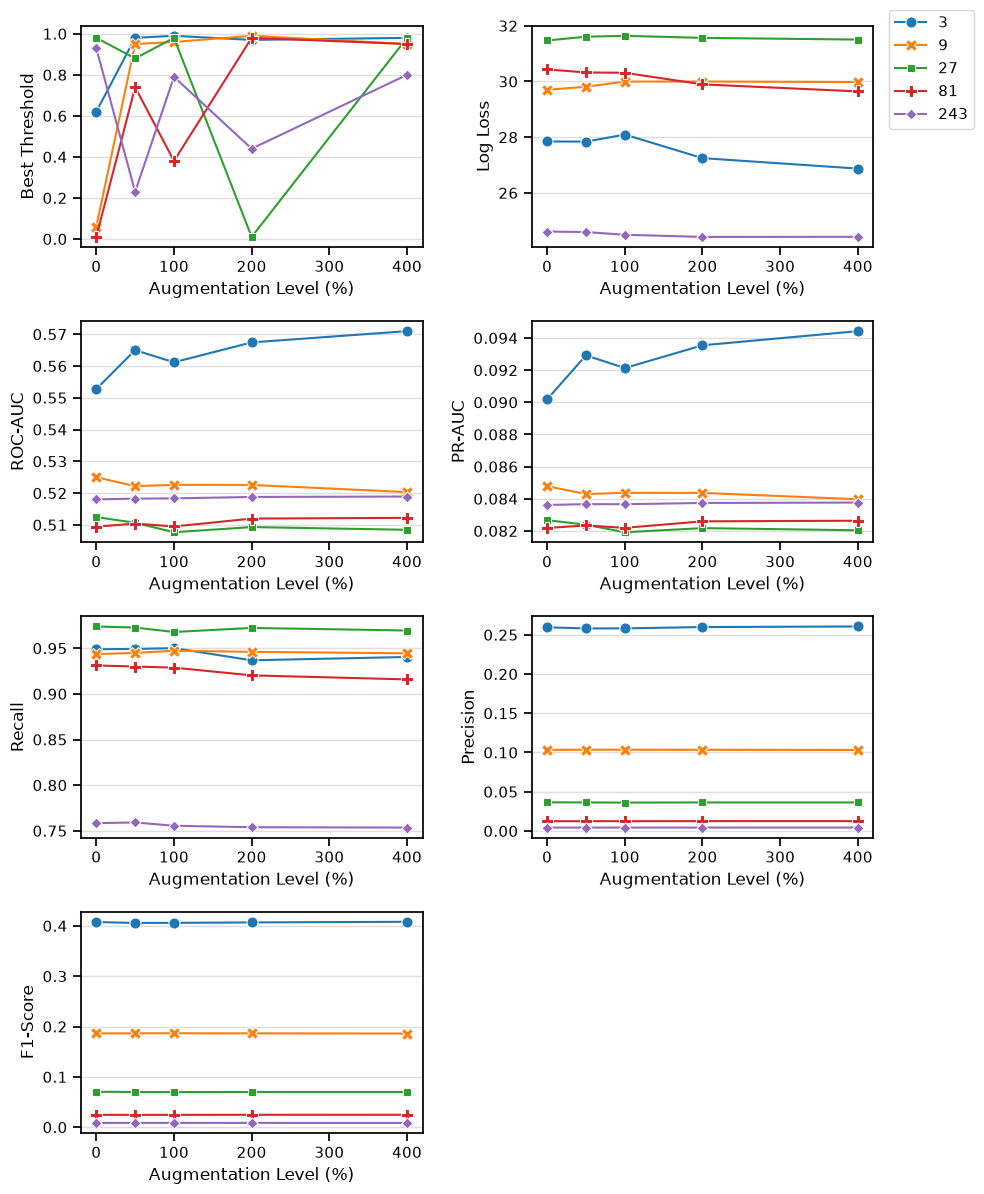

In [554]:
metric_vs_aug(gnb_results, 'small', 'gnb', log=False, maxaug=400)

small tier results
------------------

Metric versus augmentation level (%) for small tier and gnb model



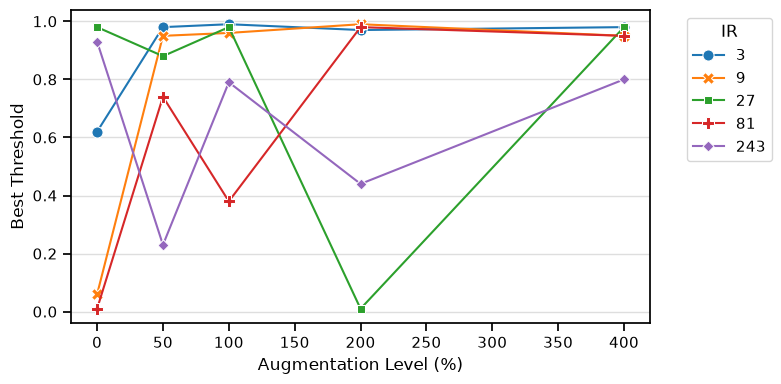


Metric versus augmentation level (%) for small tier and gnb model



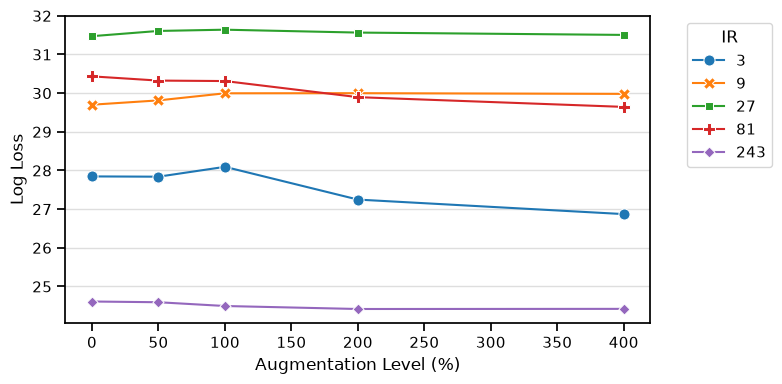


Metric versus augmentation level (%) for small tier and gnb model



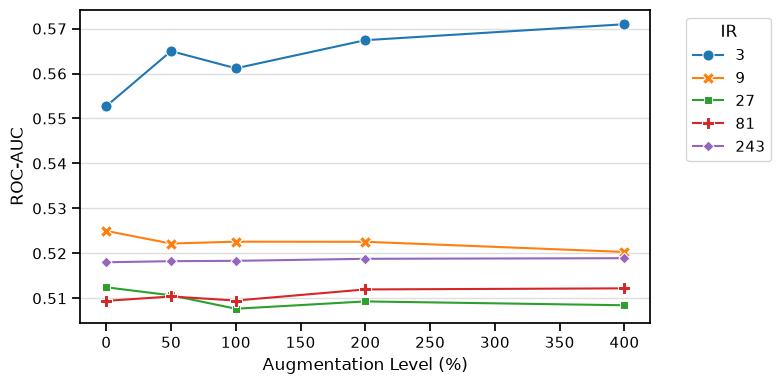


Metric versus augmentation level (%) for small tier and gnb model



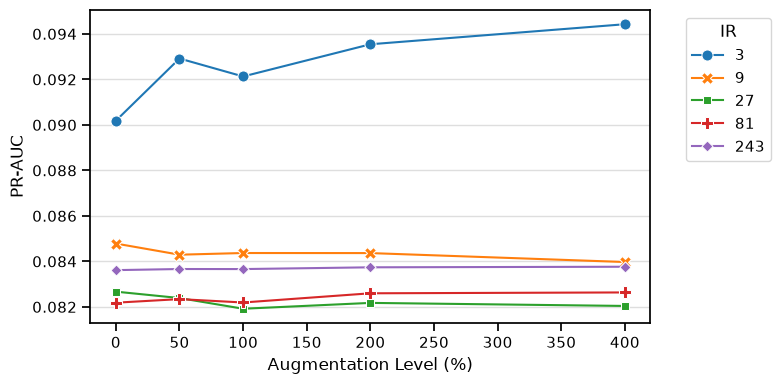


Metric versus augmentation level (%) for small tier and gnb model



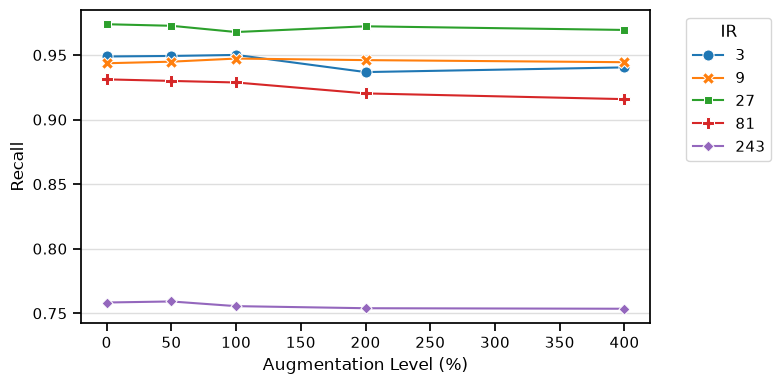


Metric versus augmentation level (%) for small tier and gnb model



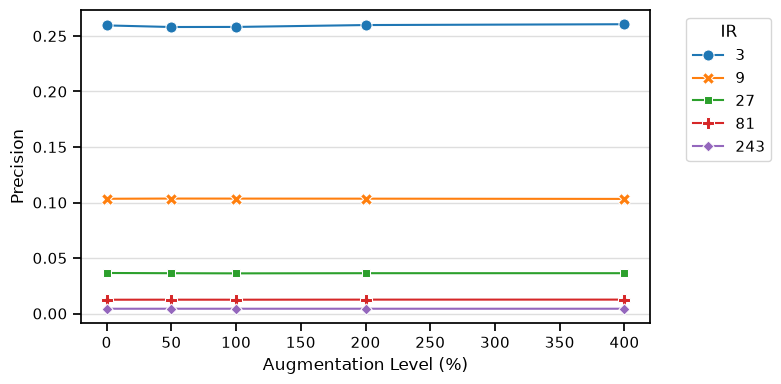


Metric versus augmentation level (%) for small tier and gnb model



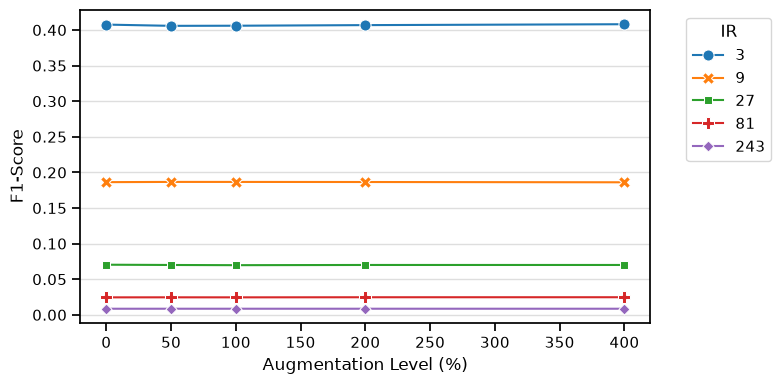

medium tier results
------------------

Metric versus augmentation level (%) for medium tier and gnb model



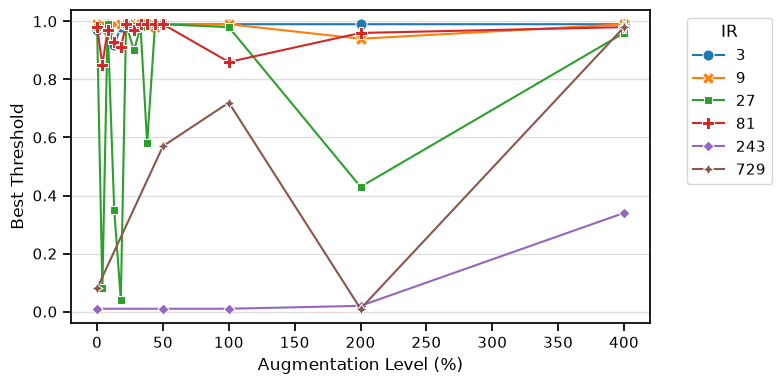


Metric versus augmentation level (%) for medium tier and gnb model



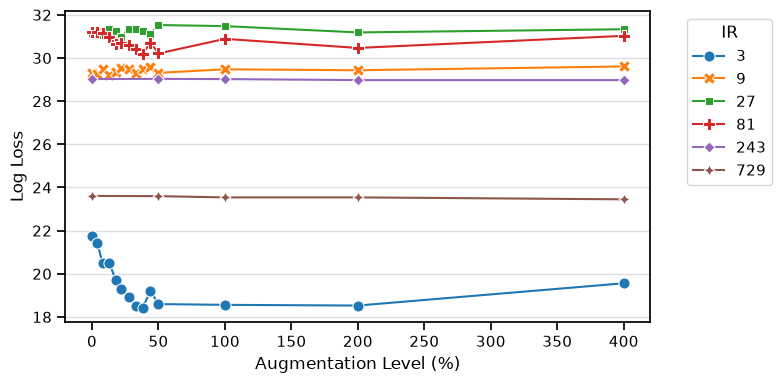


Metric versus augmentation level (%) for medium tier and gnb model



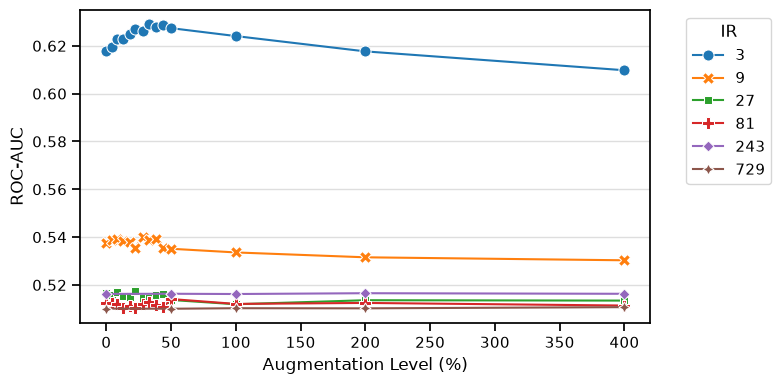


Metric versus augmentation level (%) for medium tier and gnb model



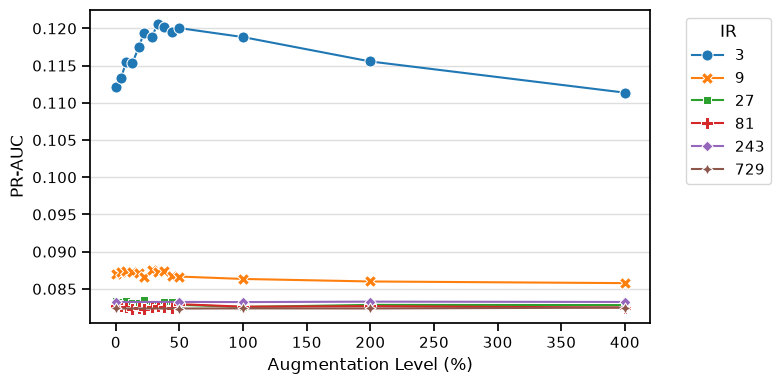


Metric versus augmentation level (%) for medium tier and gnb model



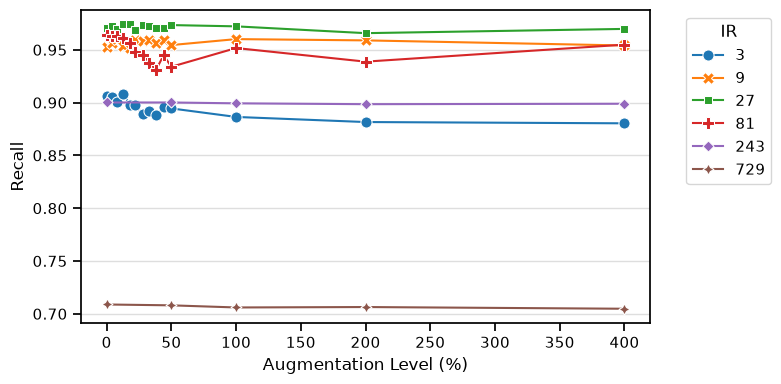


Metric versus augmentation level (%) for medium tier and gnb model



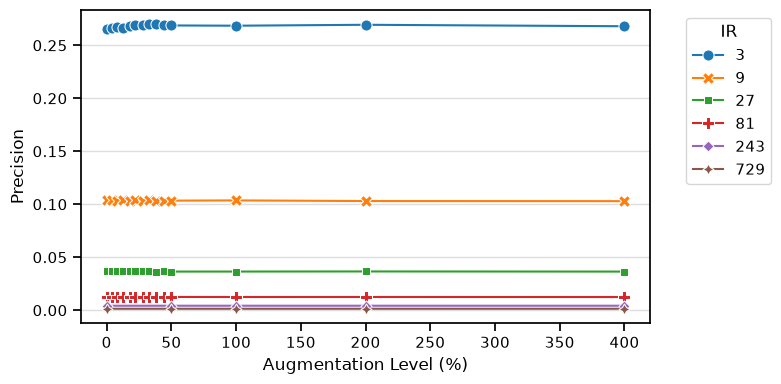


Metric versus augmentation level (%) for medium tier and gnb model



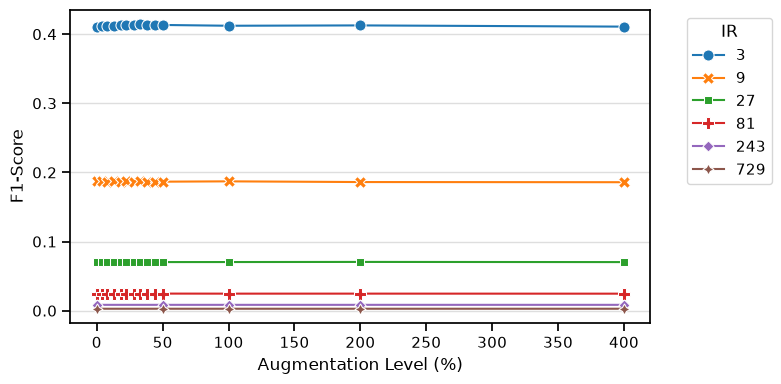

large tier results
------------------

Metric versus augmentation level (%) for large tier and gnb model



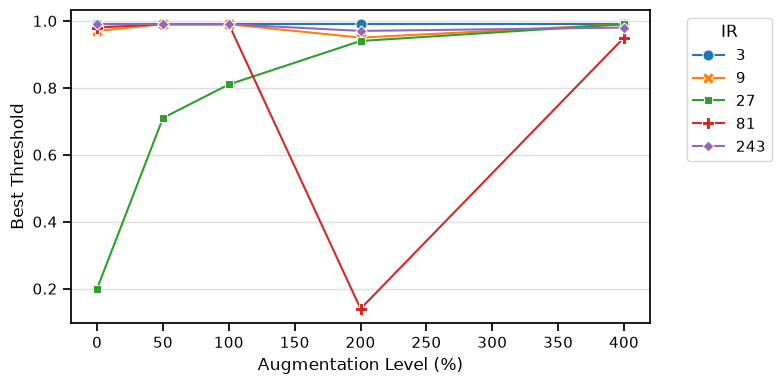


Metric versus augmentation level (%) for large tier and gnb model



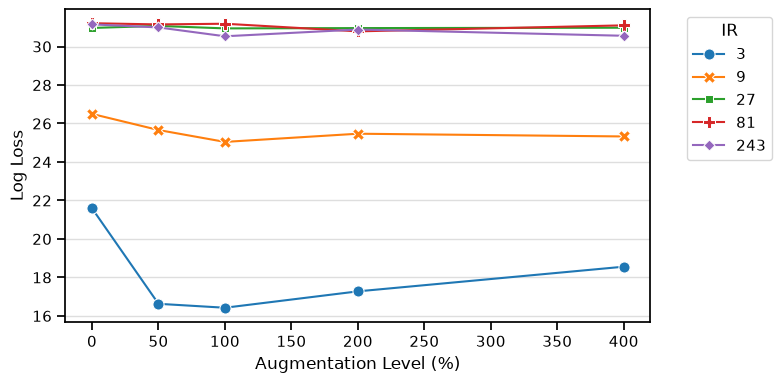


Metric versus augmentation level (%) for large tier and gnb model



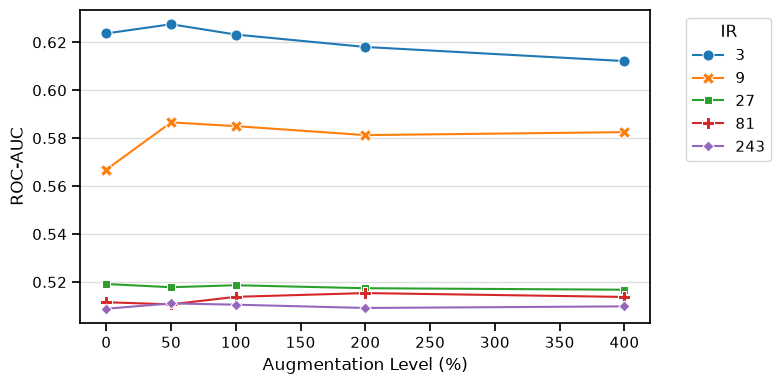


Metric versus augmentation level (%) for large tier and gnb model



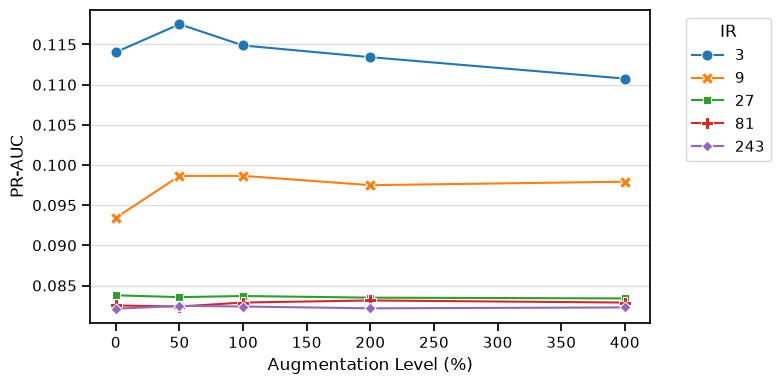


Metric versus augmentation level (%) for large tier and gnb model



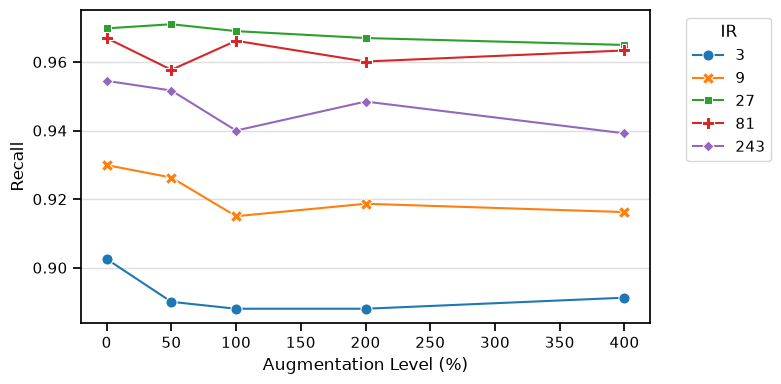


Metric versus augmentation level (%) for large tier and gnb model



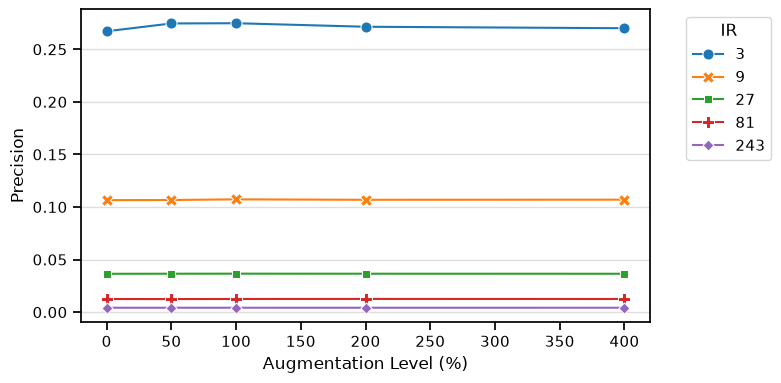


Metric versus augmentation level (%) for large tier and gnb model



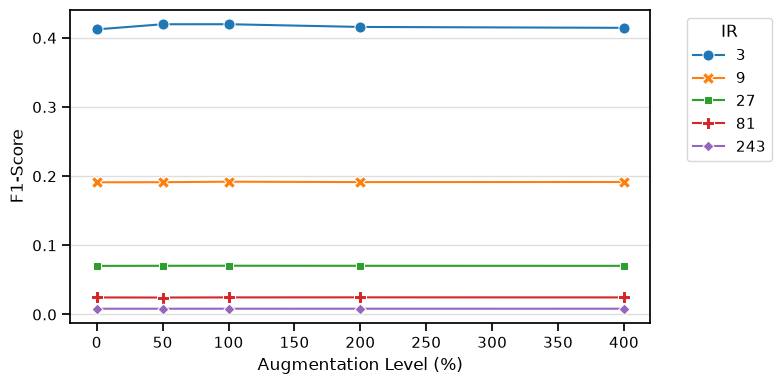

In [548]:
all_metrics = ['threshold', 'log_loss_u', 'roc_auc_u', 'pr_auc_u', 'recall', 'precision', 'f1_score']

for tier in ['small', 'medium', 'large']:
    print(f'{tier} tier results')
    print('------------------')
    metric_vs_aug_mult(gnb_results, tier, all_metrics, 'gnb', False, 400) 

### Real Data


Metric versus augmentation level (%) for smallaug tier and xgb model



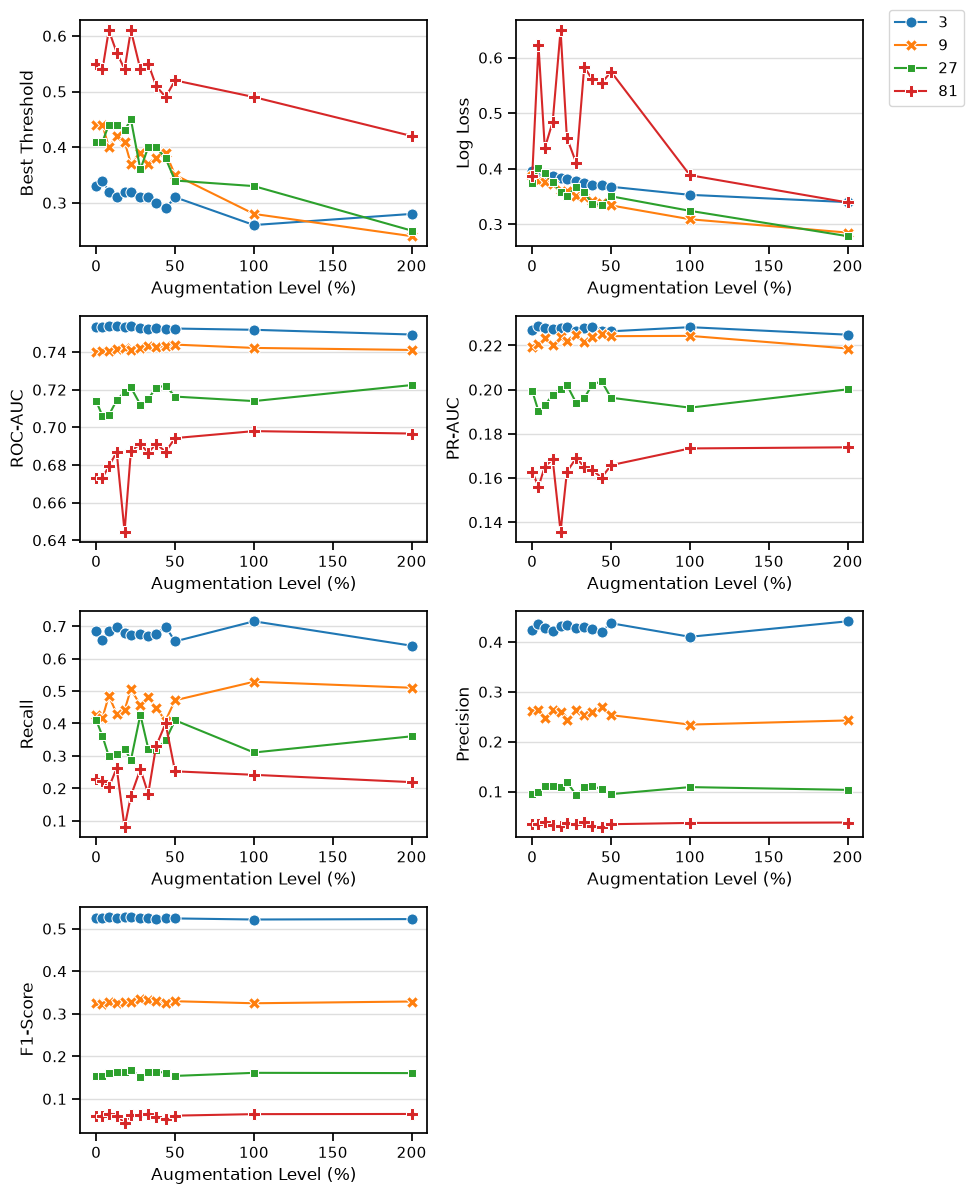

In [557]:
metric_vs_aug(xgb_results, 'smallaug', 'xgb', log=False, maxaug=400)

### Gaussian Naive Bayes Metrics versus augmentation

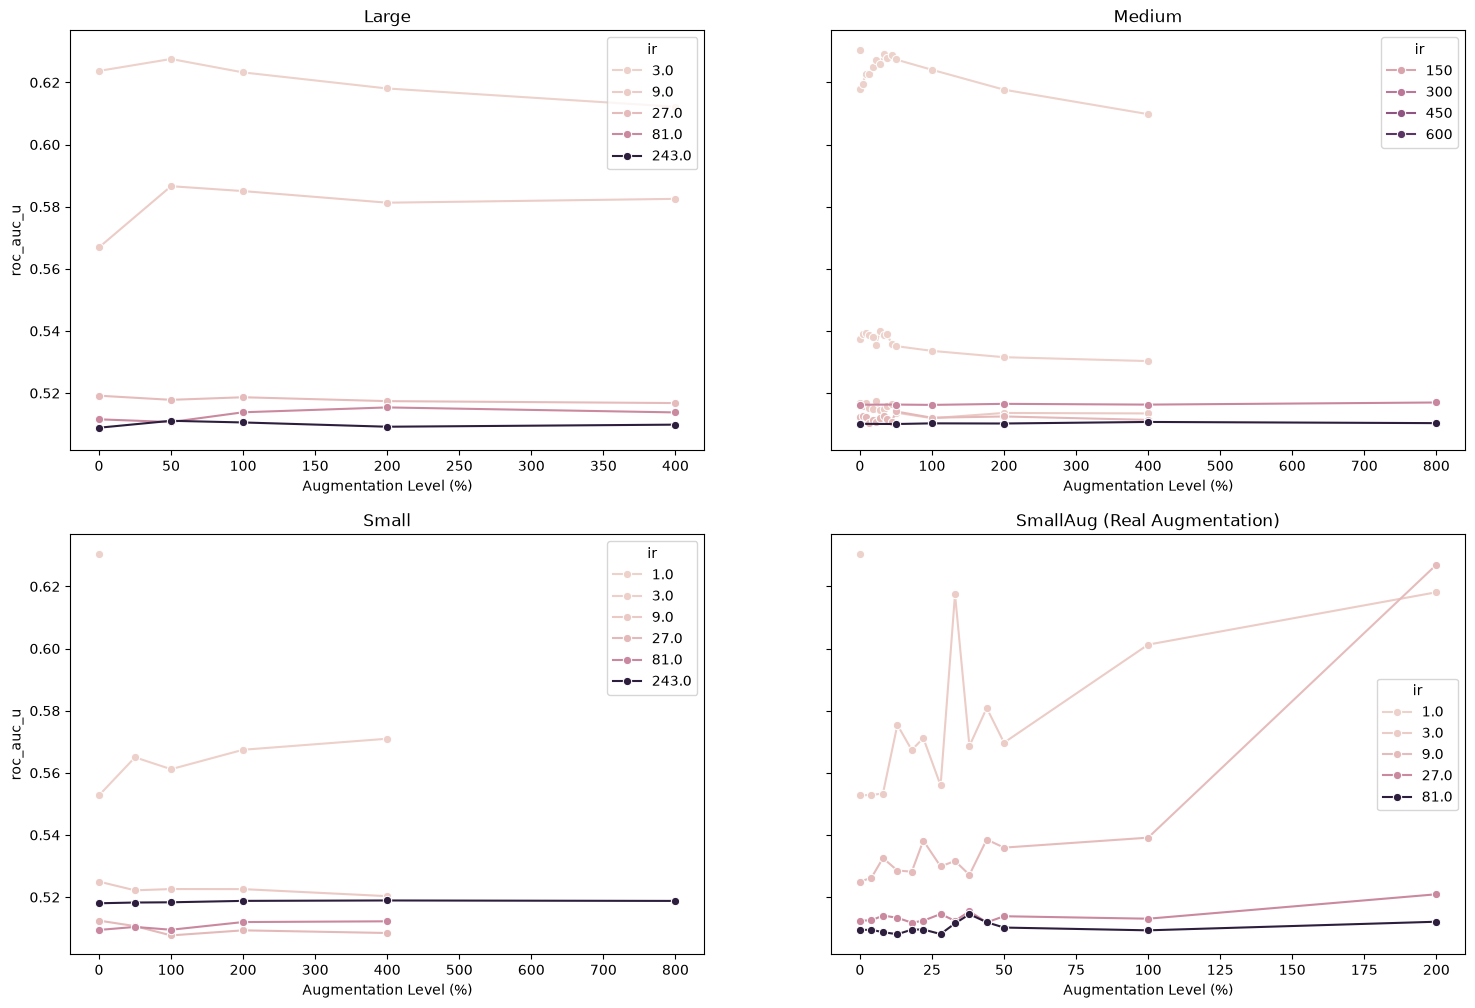

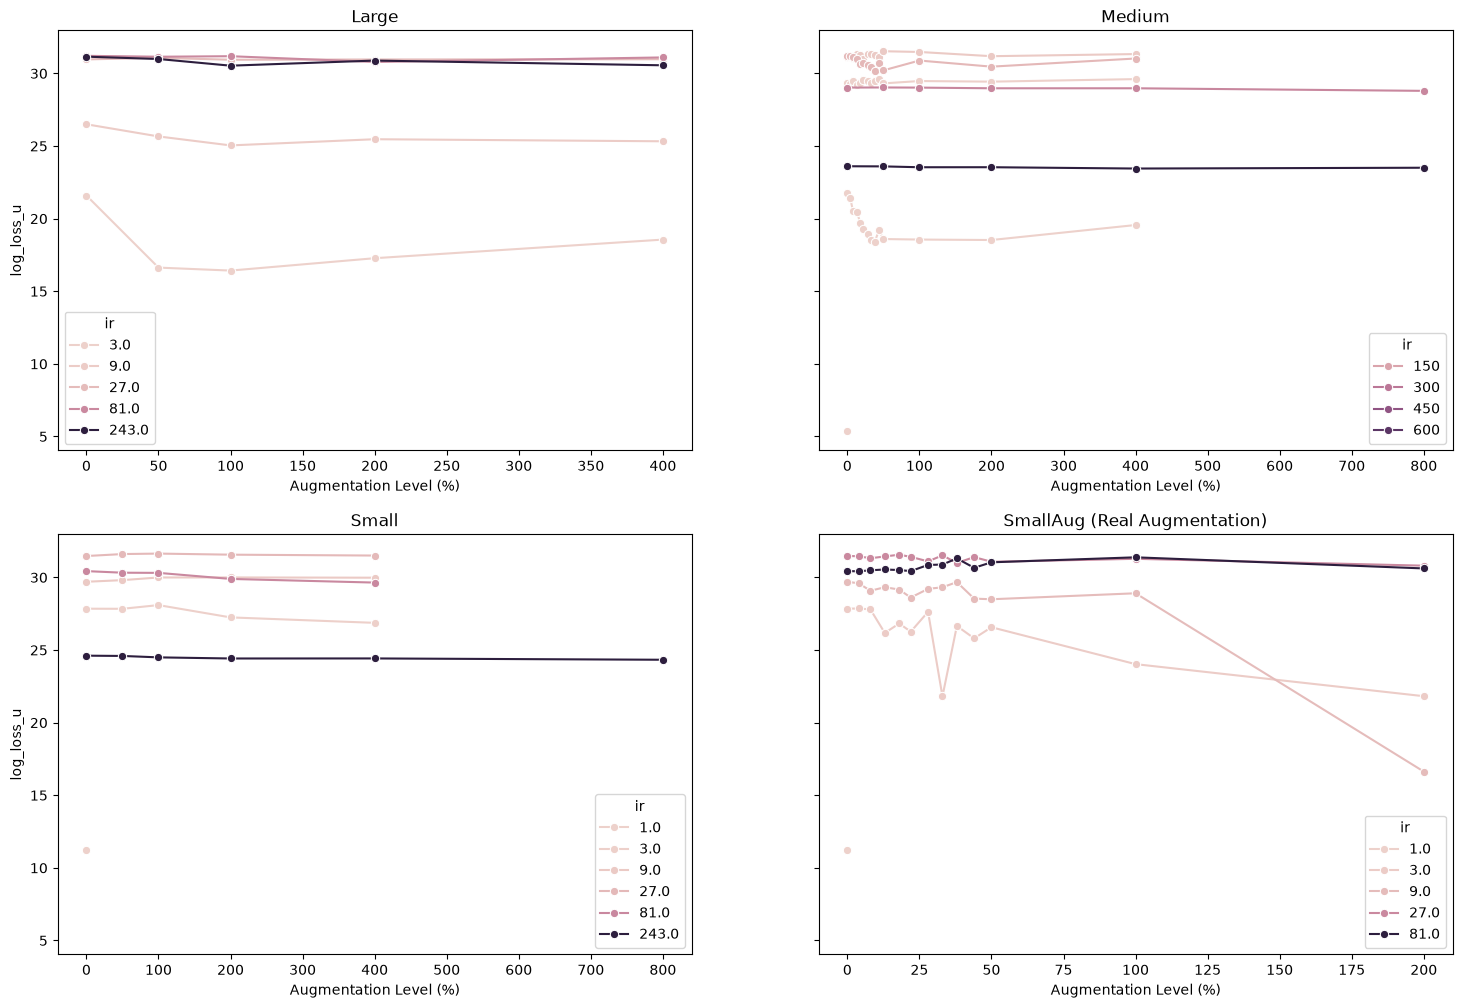

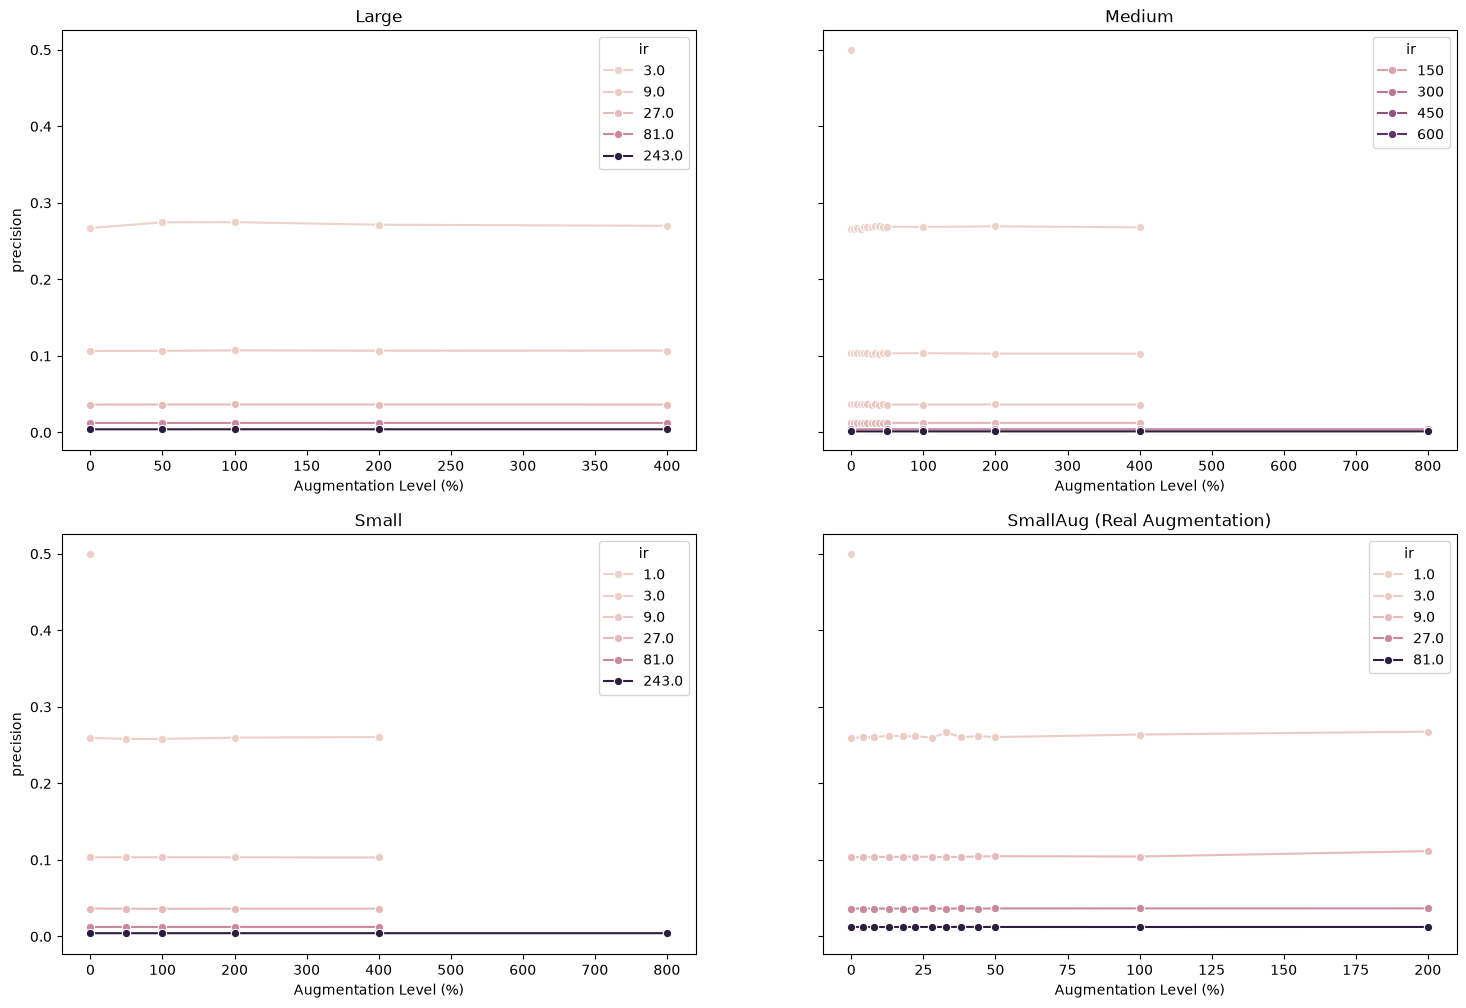

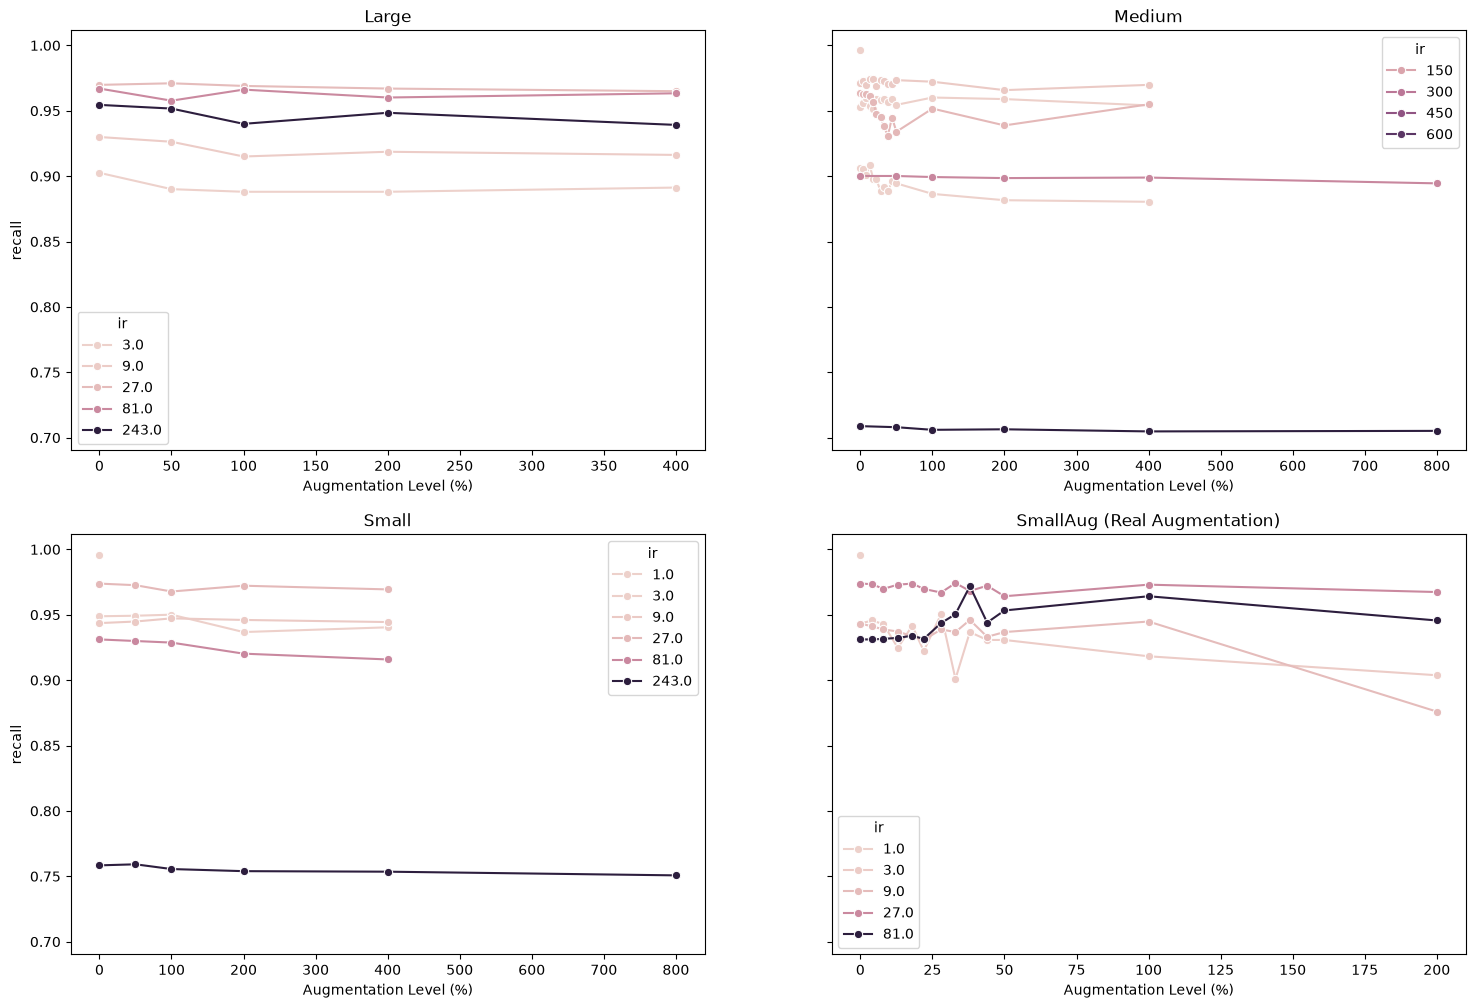

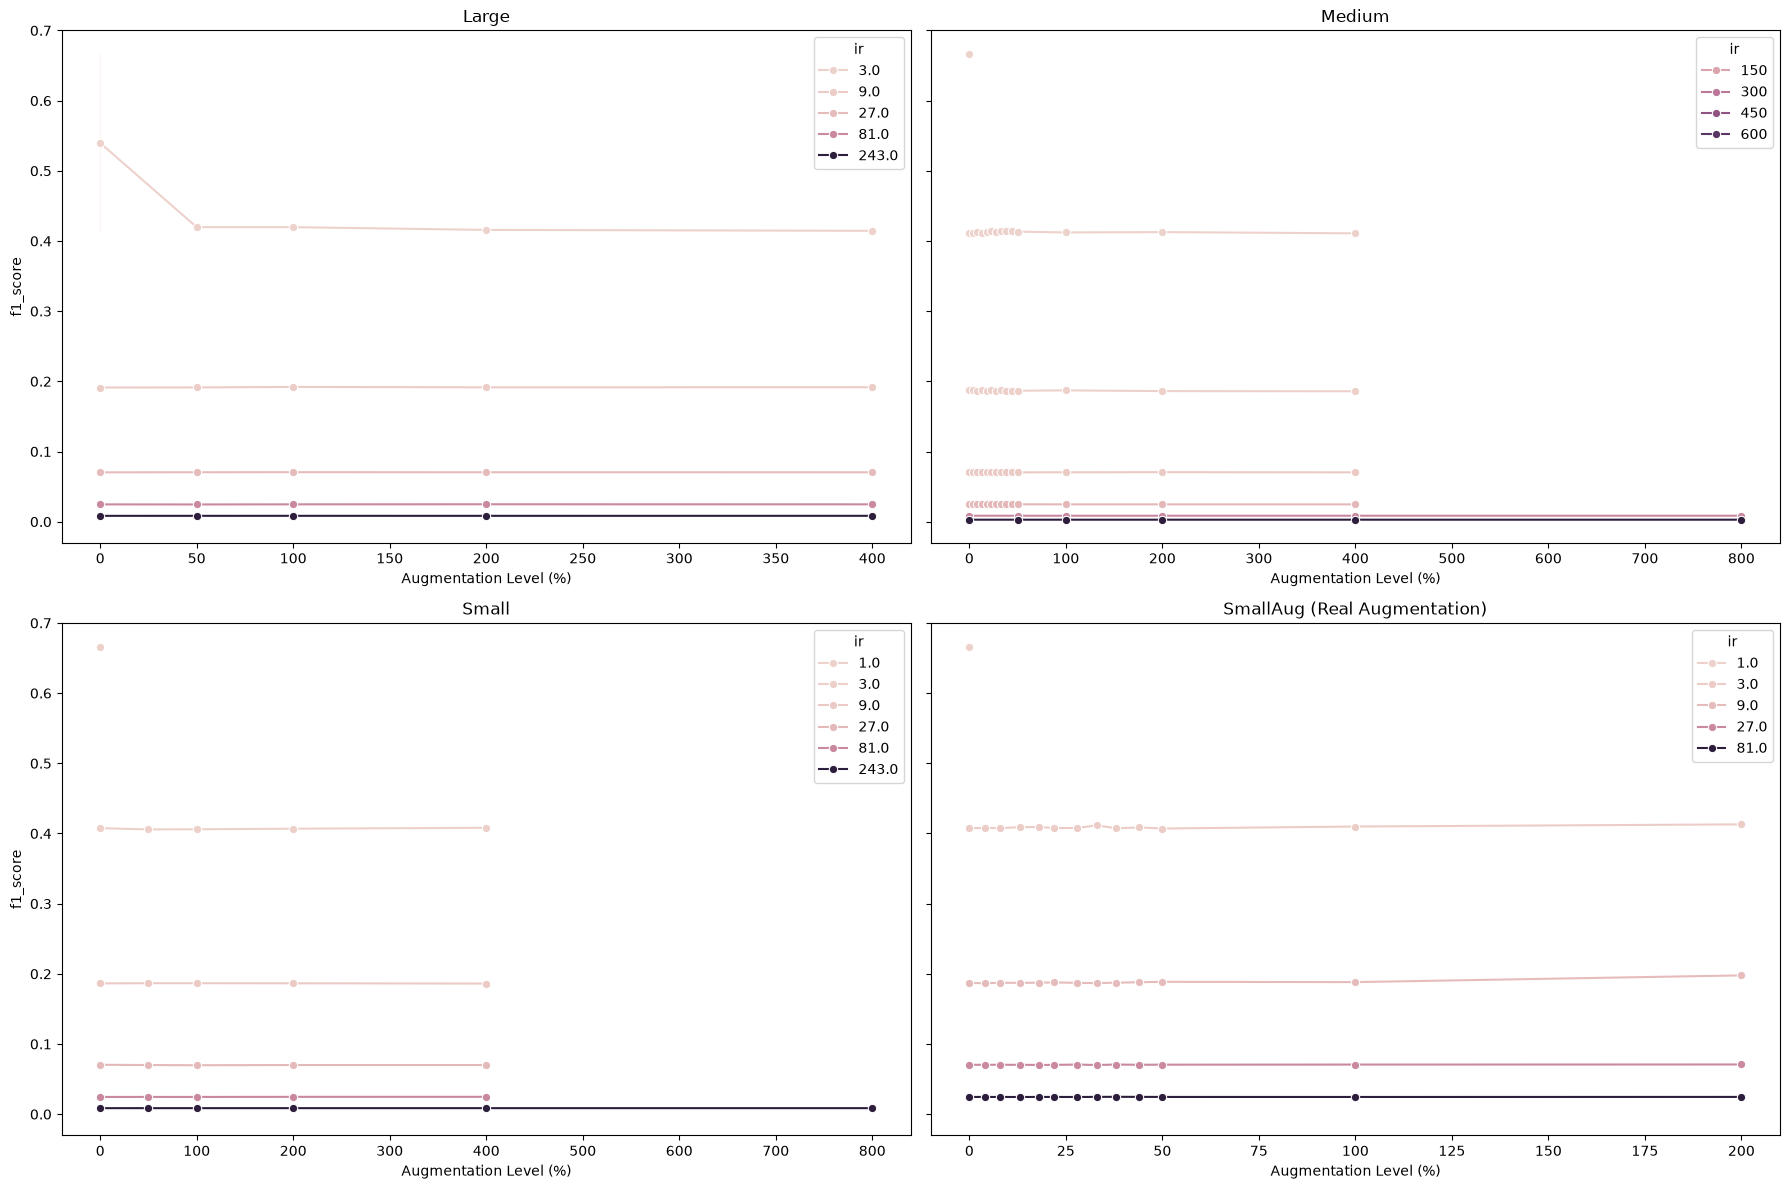

In [45]:
# Prepare both model DFs
def prep(df):
    df = df.copy()
    df['ln_ir'] = np.log(df['ir']) / np.log(3)
    return df

df_xgb = prep(xgb_results)
df_gnb = prep(gnb_results)

# Your four tiers
tier_groups = {
    'Large': ['large'],
    'Medium': ['medium'],
    'Small': ['small'],
    'SmallAug (Real Augmentation)': ['smallaug']
}
metrics = ['roc_auc_u', 'log_loss_u', 'precision', 'recall', 'f1_score']
irs = [3, 9, 27, 81]

for metric in metrics:

    # Build the 2×2 grid
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
    axes = axes.flatten()
    
    for ax, (title, tiers) in zip(axes, tier_groups.items()):
        
        # Filter both models by tier
        #df_x = df_xgb[df_xgb['tier'].isin(tiers)].assign(model='XGB')
        df_g = df_gnb[df_gnb['tier'].isin(tiers)].assign(model='GNB')
        
        # Combine
        #df_plot = pd.concat([df_x, df_g], axis=0)
        
        sns.lineplot(
            #data=df_plot,
            data=df_g,
            x='aug',          # augmentation level
            y=metric,      # ROC AUC
            hue='ir',      # XGB vs GNB
            marker='o',
            ax=ax
        )
        
        ax.set_title(title)
        ax.set_xlabel('Augmentation Level (%)')
        ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

## F1 versus augmentation

### Plotting function (`f1_aug`)

In [449]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def f1_vs_aug(df, model, tiers, irs, log=False, maxaug=1000):

    metric = 'f1_score'
    metric_label = 'F1-Score'
    
    # Iterate through the specifed IR levels
    for ir in irs:
    
        # Copy the tier from the source DataFrame
        df_plot = df[(df.tier.isin(tiers)) & (df.ir == ir)].copy()
    
        # Limit the augmentation range to increase the x-scale 
        df_plot= df_plot[df_plot.aug <= maxaug]
        
        fig, ax = plt.subplots(figsize=(8, 4))
        
        sns.lineplot(
            data=df_plot,
            x='aug',          # Augmentation level
            y=metric,
            hue='tier',     # IR
            style='tier',
            markers=True,
            #markersize=8,
            dashes=False,
            ax=ax
        )
        ax.set_xlabel('Augmentation Level (%)')
        ax.set_ylabel(metric_label)
        
        # Optionally use a log x-scale
        if log:
            ax.set_xscale('log')

        # Legend outside panel
        ax.legend(title='Tier', bbox_to_anchor=(1.05, 1), loc='upper left')

        # Display the figure
        print(f'\n{metric_label} versus augmentation level (%) for IR {ir}, {model} model\n')
        plt.tight_layout()
        plt.show()

### XGBoost


F1-Score versus augmentation level (%) for IR 3, xgb model



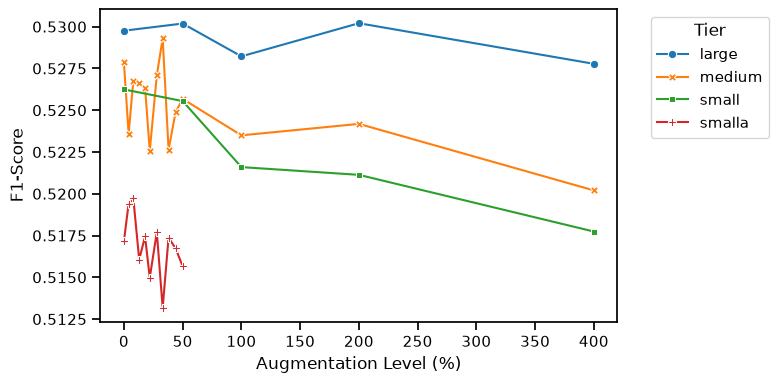


F1-Score versus augmentation level (%) for IR 9, xgb model



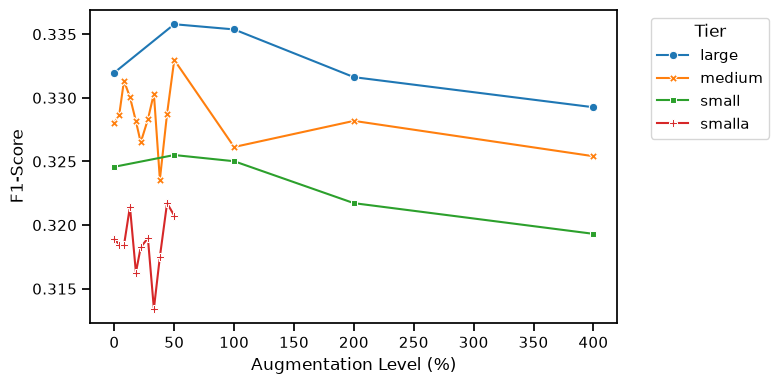


F1-Score versus augmentation level (%) for IR 27, xgb model



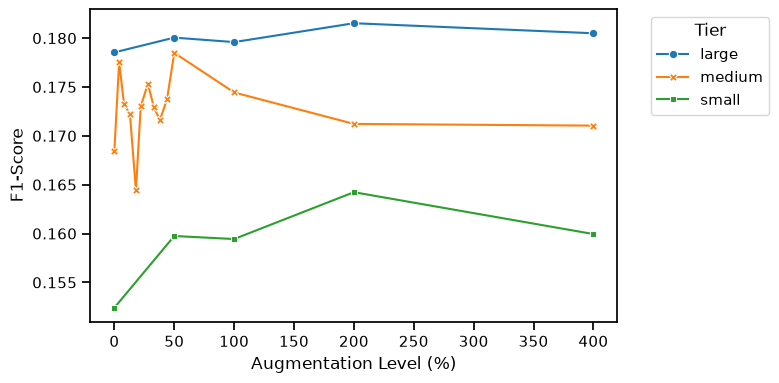


F1-Score versus augmentation level (%) for IR 81, xgb model



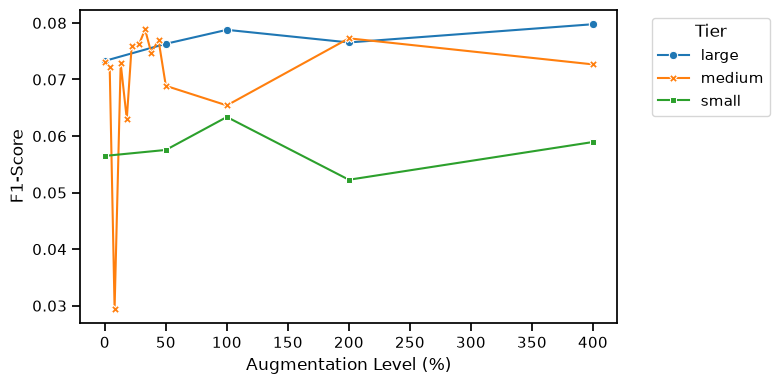


F1-Score versus augmentation level (%) for IR 243, xgb model



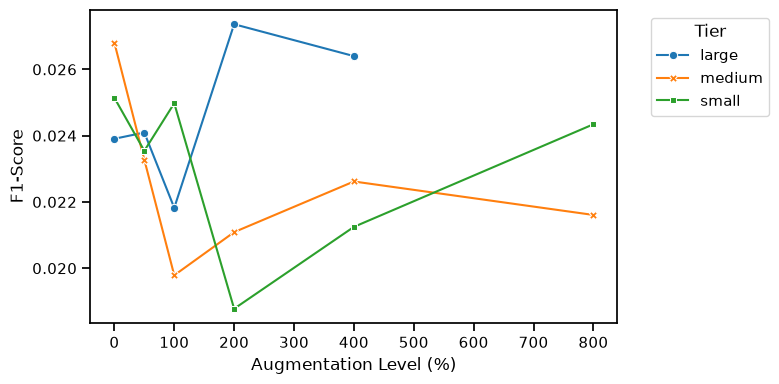


F1-Score versus augmentation level (%) for IR 729, xgb model



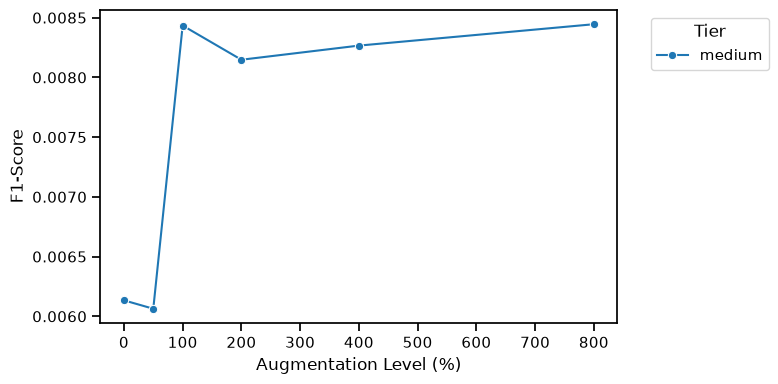

In [453]:
tiers = ['large', 'medium', 'small', 'smalla']
f1_vs_aug(xgb_results, 'xgb', tiers, [3, 9, 27, 81, 243, 729], False, 1000)

### Gaussian Naive Bayes


F1-Score versus augmentation level (%) for IR 3, gnb model



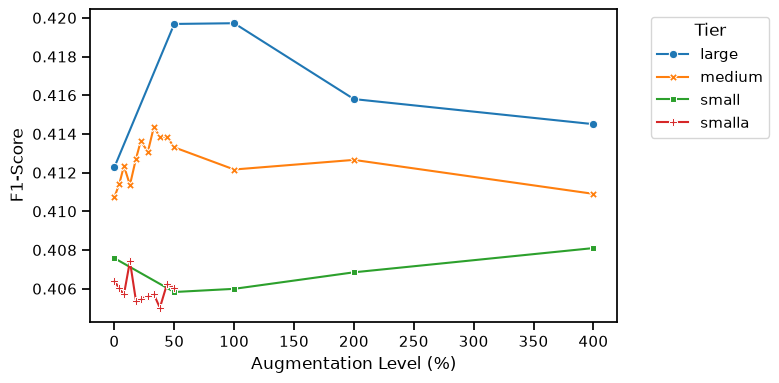


F1-Score versus augmentation level (%) for IR 9, gnb model



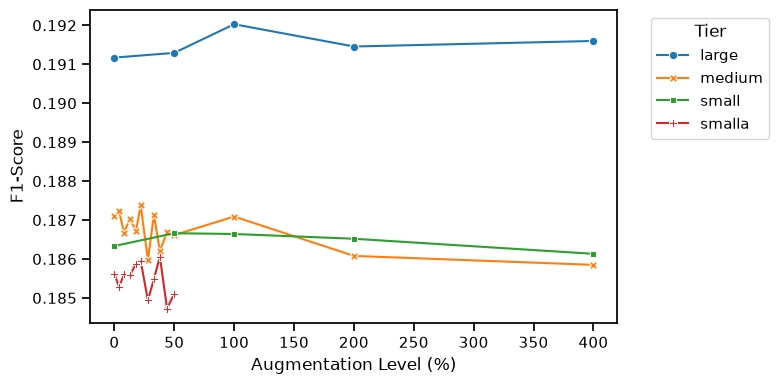


F1-Score versus augmentation level (%) for IR 27, gnb model



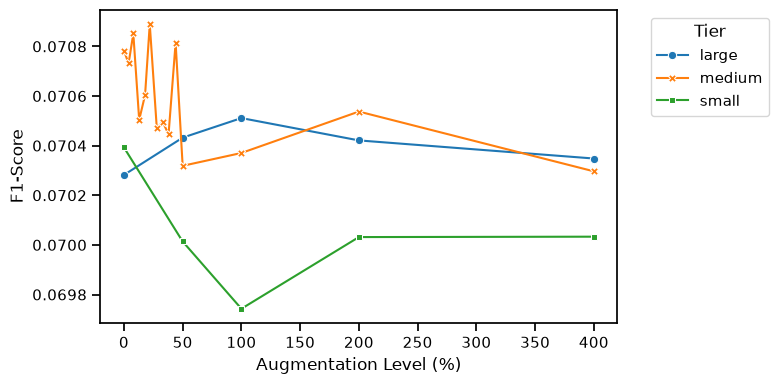


F1-Score versus augmentation level (%) for IR 81, gnb model



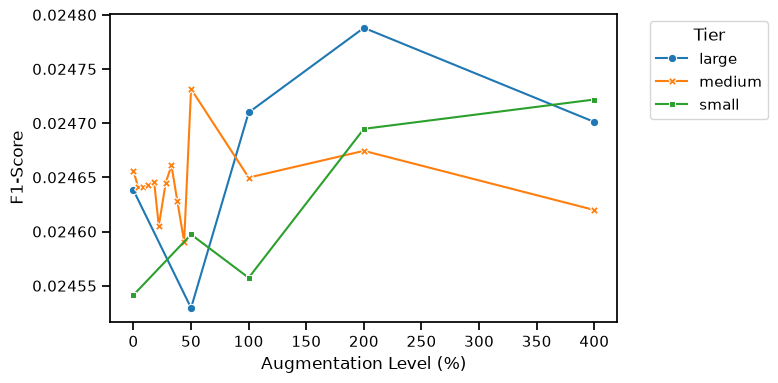


F1-Score versus augmentation level (%) for IR 243, gnb model



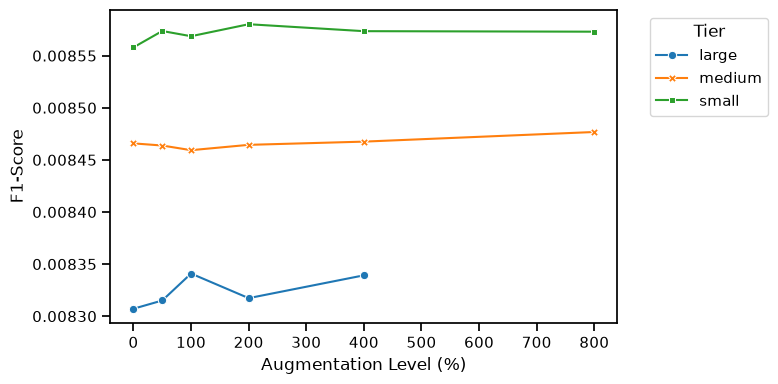


F1-Score versus augmentation level (%) for IR 729, gnb model



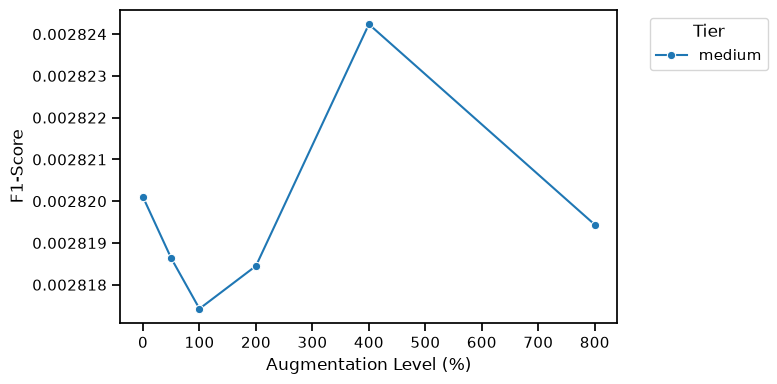

In [454]:
tiers = ['large', 'medium', 'small', 'smalla']
f1_vs_aug(gnb_results, 'gnb', tiers, [3, 9, 27, 81, 243, 729], False, 1000)

## Plot Recovery

In [15]:
df_plot = results[(results['tier'] == 'small') & (results['ir'] == 27) & (results['aug'] != 0)]
df_plot.loc[:,['aug', 'f1_recovery_percentage']]

,aug,f1_recovery_percentage
small-ir027-aug050,50.0,1.300911
small-ir027-aug100,100.0,1.246054
small-ir027-aug200,200.0,2.095537
small-ir027-aug400,400.0,1.336252


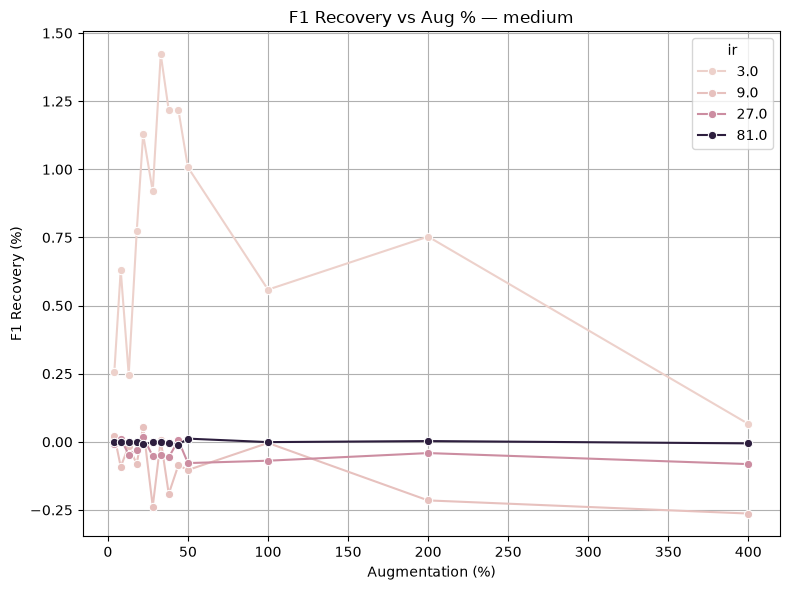

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example filters
selected_tier = 'medium'
selected_irs = [3, 9, 27, 81]   # whatever IR values you want

# Filter dataframe
df_plot = gnb_results[
    (gnb_results['tier'] == selected_tier) & 
    (gnb_results['ir'].isin(selected_irs)) & 
    (gnb_results['aug'] != 0)]

# Plot
plt.figure(figsize=(8,6))
sns.lineplot(
    data=df_plot,
    x='aug',
    y='f1_recovery_percentage',
    hue='ir',
    marker='o'
)

plt.title(f"F1 Recovery vs Aug % — {selected_tier}")
plt.xlabel('Augmentation (%)')
plt.ylabel('F1 Recovery (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


## F1 Recovery

### Gaussian naive Bayes

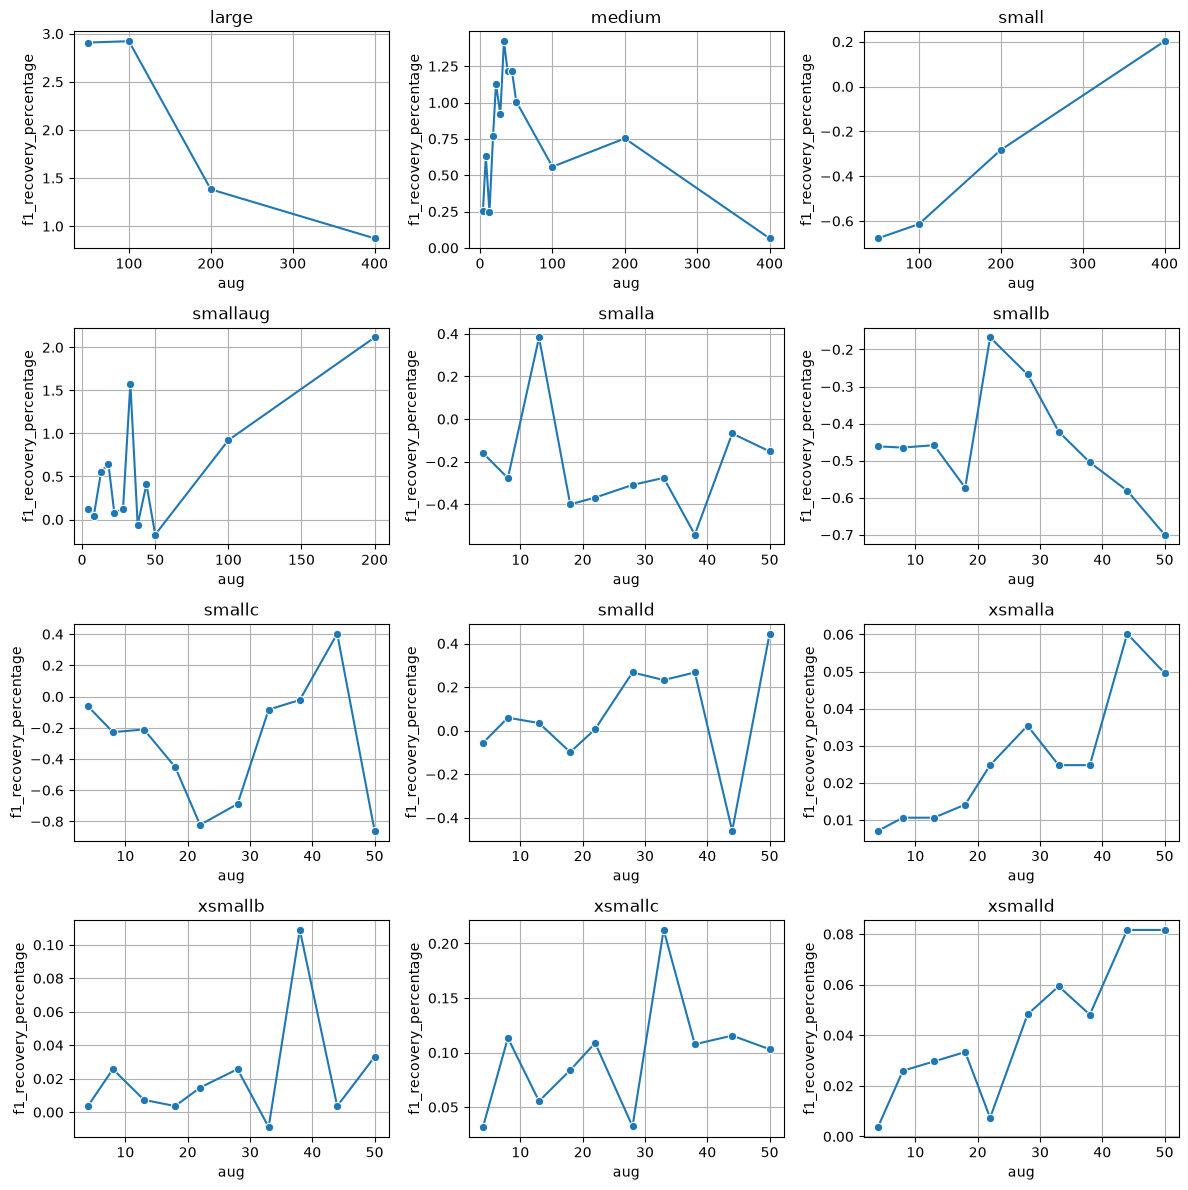

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

tiers = gnb_results['tier'].unique()   # or whatever categories you want to plot

fig, axes = plt.subplots(4, 3, figsize=(WIDTH, 12))
axes = axes.flatten()

for ax, tier in zip(axes, tiers):
    #subset = results[results['tier'] == tier].sort_values('ir')
    subset = gnb_results[(gnb_results['tier'] == tier) & (gnb_results['ir'] == 3)]
    sns.lineplot(
        data=subset,
        x='aug',
        y='f1_recovery_percentage',
        marker='o',
        ax=ax
    )
    ax.set_title(tier)
    ax.grid(True)

# Hide any unused axes (since you have 11 plots but 12 slots)
for ax in axes[len(tiers):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### GNB primary grid

Plot F1 recovery versus augmentation level for primary grid. Exclude IR 243, which shows similar results to IR 27 and 81.

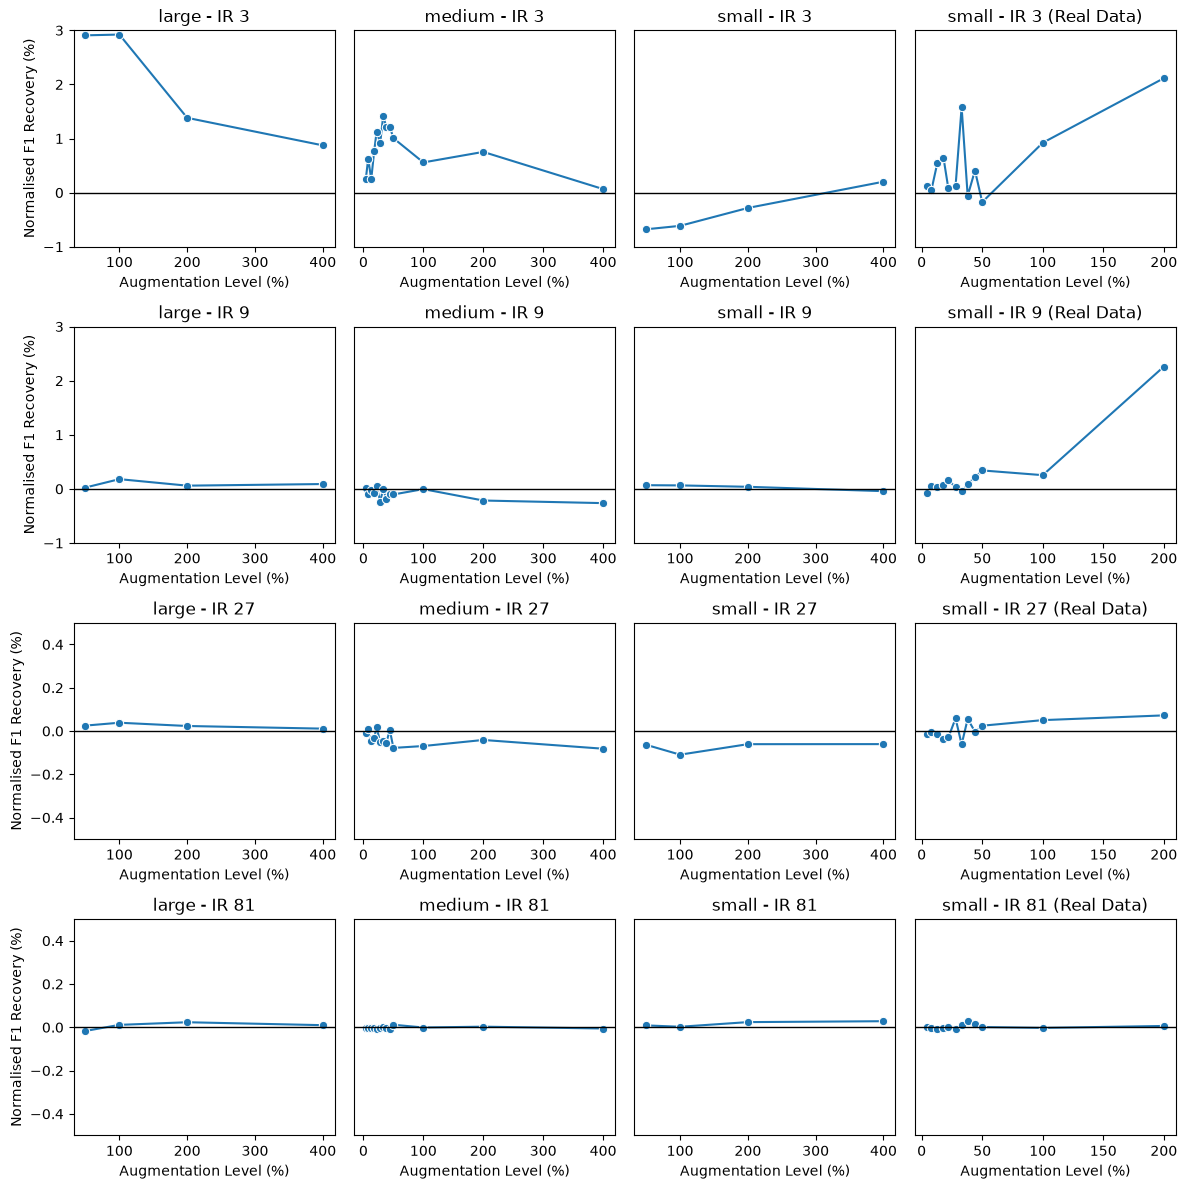

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tiers and IRs to include
tiers_to_plot = ['large', 'medium', 'small', 'smallaug']
irs_to_plot = [3, 9, 27, 81]

# Filter the dataset
subset_results = gnb_results[
    (gnb_results['tier'].isin(tiers_to_plot)) &
    (gnb_results['ir'].isin(irs_to_plot))
]

# Create 4 rows (IRs) × 4 columns (tiers)
fig, axes = plt.subplots(len(irs_to_plot), len(tiers_to_plot),
                         figsize=(WIDTH, 12))

# Iterate over the IRs and tiers
for r, ir in enumerate(irs_to_plot):
    for c, tier in enumerate(tiers_to_plot):
        ax = axes[r, c]

        # Select a slice of data and plot the curve
        data_rc = subset_results[
            (subset_results['tier'] == tier) &
            (subset_results['ir'] == ir)
        ]
        sns.lineplot(
            data=data_rc,
            x='aug',
            y='f1_recovery_percentage',
            marker='o',
            ax=ax
        )

        # Format the plot
        if tier == 'smallaug':
            ax.set_title(f'small - IR {ir} (Real Data)')
        else:
            ax.set_title(f'{tier} - IR {ir}')
        ax.set_xlabel('Augmentation Level (%)')
        ax.grid(False)
        ax.axhline(0, color='black', linewidth=1)     # Add X axis

        # Set y-axis limits depending on IR
        if ir in [3, 9]:
            ax.set_ylim(-1, 3)
        else:  # IR 27 and 81
            ax.set_ylim(-0.5, 0.5)

        # Hide y-axis on all but the left column
        if c != 0:
            ax.set_ylabel('')
            ax.set_yticks([])
        else:
            ax.set_ylabel('Normalised F1 Recovery (%)')

# Save and show the figure
plt.tight_layout()
fig.savefig('..\\plots\\f1_recovery_gnb.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### XGB primary grid

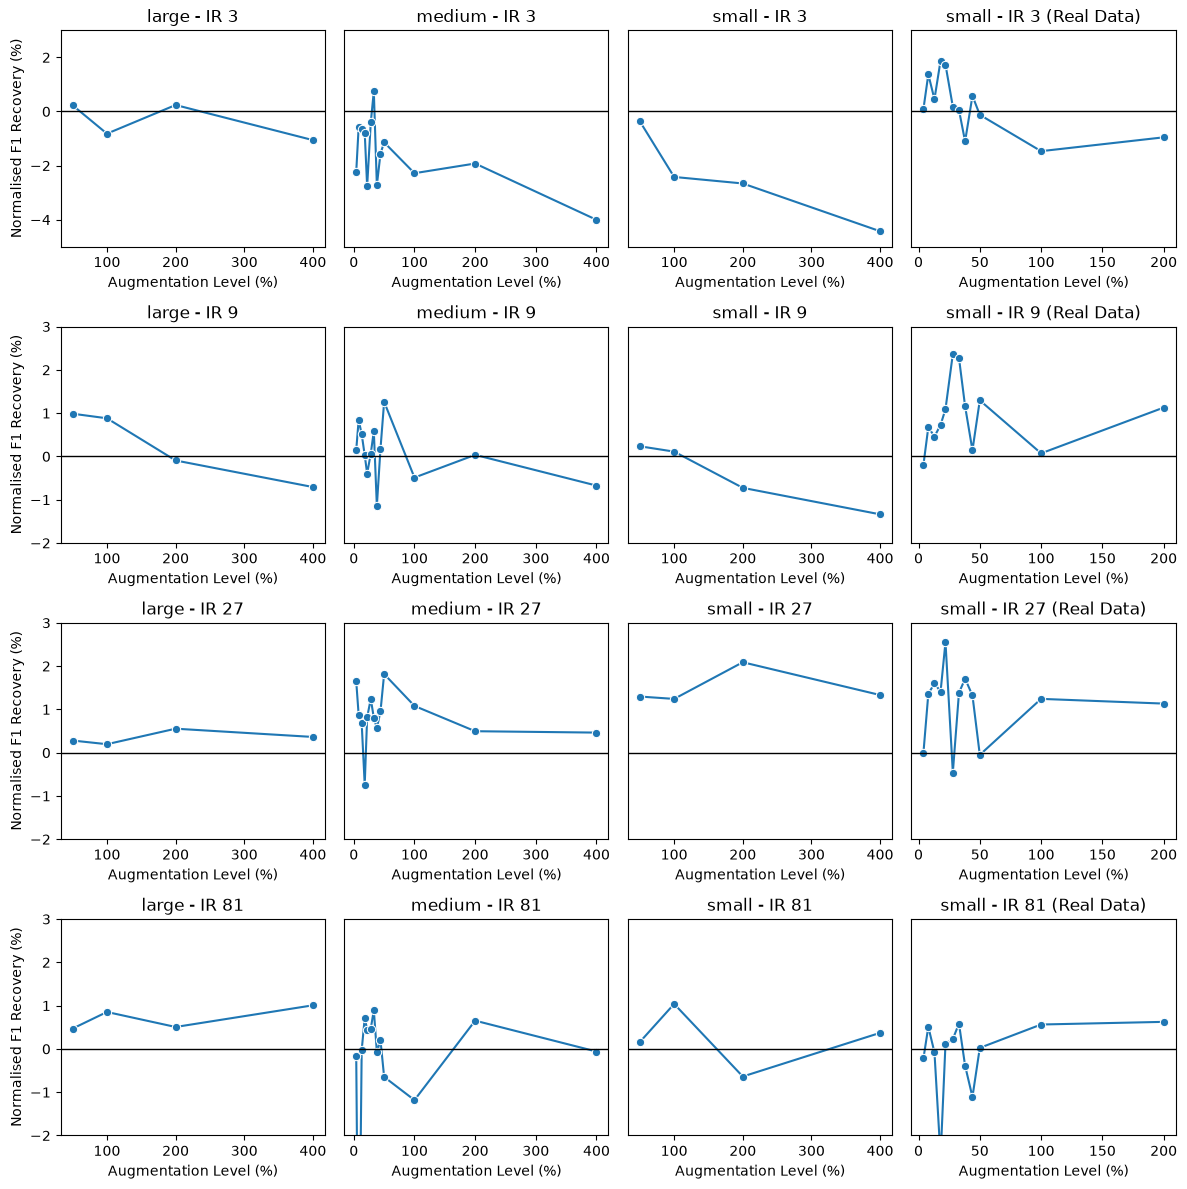

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tiers and IRs to include
tiers_to_plot = ['large', 'medium', 'small', 'smallaug']
irs_to_plot = [3, 9, 27, 81]

# Filter the dataset
subset_results = xgb_results[
    (xgb_results['tier'].isin(tiers_to_plot)) &
    (xgb_results['ir'].isin(irs_to_plot))
]

# Create 4 rows (IRs) × 4 columns (tiers)
fig, axes = plt.subplots(len(irs_to_plot), len(tiers_to_plot),
                         figsize=(WIDTH, 12))

# Iterate over the IRs and tiers
for r, ir in enumerate(irs_to_plot):
    for c, tier in enumerate(tiers_to_plot):
        ax = axes[r, c]

        # Select a slice of data and plot the curve
        data_rc = subset_results[
            (subset_results['tier'] == tier) &
            (subset_results['ir'] == ir)
        ]
        sns.lineplot(
            data=data_rc,
            x='aug',
            y='f1_recovery_percentage',
            marker='o',
            ax=ax
        )

        # Format the plot
        if tier == 'smallaug':
            ax.set_title(f'small - IR {ir} (Real Data)')
        else:
            ax.set_title(f'{tier} - IR {ir}')
        ax.set_xlabel('Augmentation Level (%)')
        ax.grid(False)
        ax.axhline(0, color='black', linewidth=1)    # Add X axis

        # Set y-axis limits depending on IR
        if ir in [3]:
            ax.set_ylim(-5, 3)
        else:  # IR 9, 27 and 81
            ax.set_ylim(-2, 3)

        # Hide y-axis on all but the left column
        if c != 0:
            ax.set_ylabel('')
            ax.set_yticks([])
        else:
            ax.set_ylabel('Normalised F1 Recovery (%)')

# Save and show the figure
plt.tight_layout()
fig.savefig('..\\plots\\f1_recovery.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

## Threshold versus ir

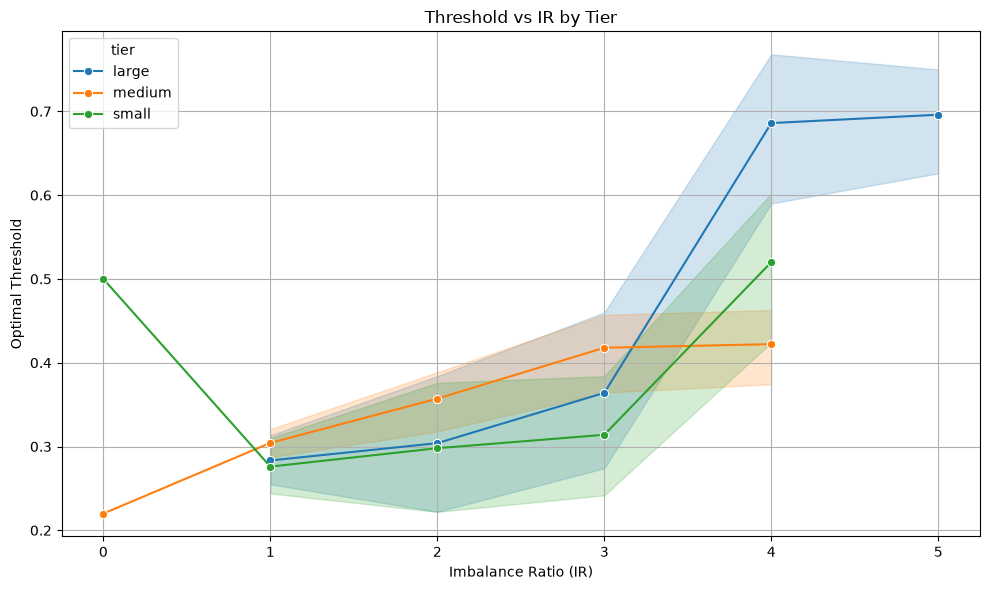

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt


plot_df = xgb_results.copy()

plot_df = plot_df[plot_df['tier'].isin( ['large', 'medium', 'small'])]
plot_df['ln_ir'] = np.log(plot_df['ir']) / np.log(3)
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_df,
    x='ln_ir',
    y="threshold",
    hue="tier",
    marker="o"
)

plt.title("Threshold vs IR by Tier")
plt.xlabel("Imbalance Ratio (IR)")
plt.ylabel("Optimal Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


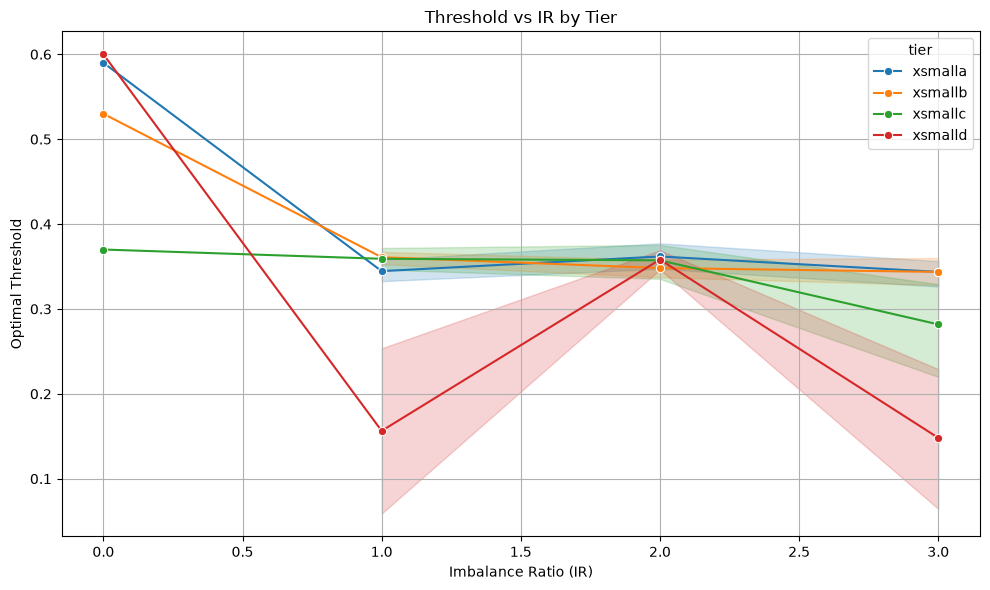

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt


plot_df = results.copy()

plot_df = plot_df[results['tier'].isin( ['xsmalla', 'xsmallb', 'xsmallc', 'xsmalld'])]
plot_df['ln_ir'] = np.log(plot_df['ir']) / np.log(3)
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_df,
    x='ln_ir',
    y="threshold",
    hue="tier",
    marker="o"
)

plt.title("Threshold vs IR by Tier")
plt.xlabel("Imbalance Ratio (IR)")
plt.ylabel("Optimal Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


### Comparing fold, weighted scenario, and unweighted scenario

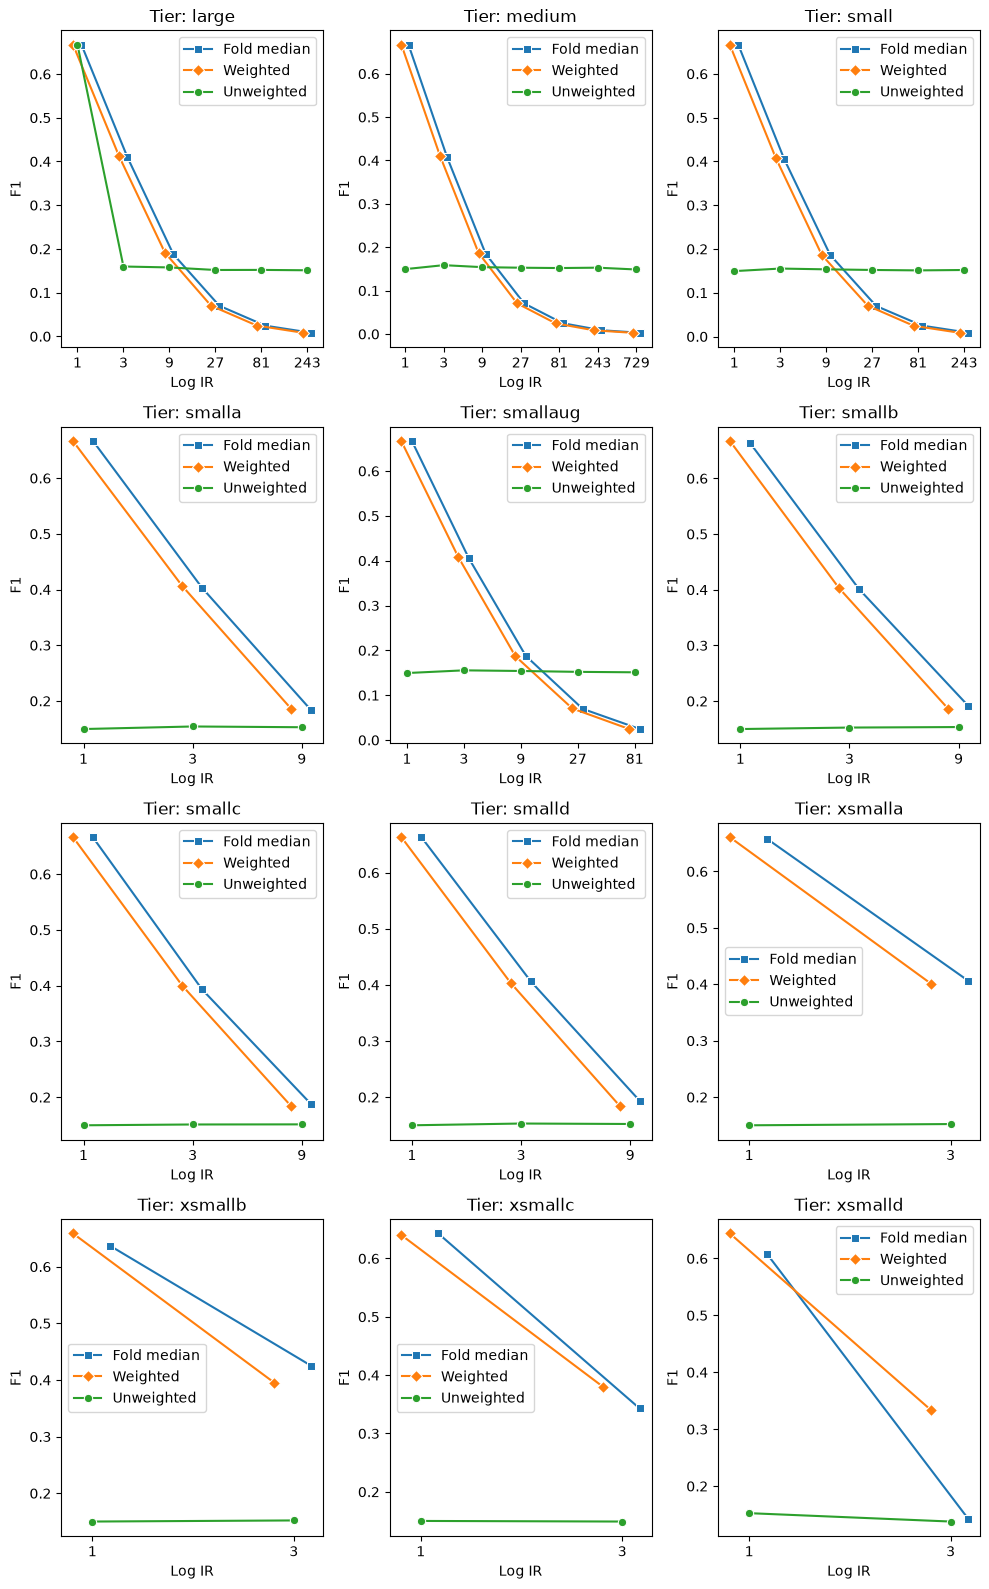

In [299]:
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator
import seaborn as sns

plot_df = gnb_results.copy()

tiers = plot_df['tier'].unique()
tiers = sorted(tiers)   # optional: consistent ordering

# Calcualte the log IR x-axis
# Add jitter to the x-axis so that the lines do not overlap
plot_df['ln_ir'] = np.log(plot_df['ir']) / np.log(3)
plot_df['ln_ir_m'] = plot_df['ln_ir'] - 0.06
plot_df['ln_ir_w'] = plot_df['ln_ir'] + 0.06

# Add log jitter to the x-axis
plot_df['ir_m'] = plot_df['ir'] * 1.1
plot_df['ir_w'] = plot_df['ir'] * 0.9


# Calculate the log F1 axis
plot_df['ln_med_f1'] = np.log(plot_df['best_f1_median'])
plot_df['ln_f1'] = np.log(plot_df['f1_score'])
plot_df['ln_f1_u'] = np.log(plot_df['f1_score_u'])

fig, axes = plt.subplots(4, 3, figsize=(10, 16))
axes = axes.flatten()

for ax, tier in zip(axes, tiers):
    
    # Select the unaugmented data for the tier
    subset = plot_df[(plot_df['tier'] == tier) & (plot_df['aug'] == 0)].sort_values('ir')
    
    # Plot fold training
    sns.lineplot(
        data=subset,
        #x='ln_ir_m',
        x='ir_m',
        y='best_f1_median',
        #y='ln_med_f1',
        marker='s',
        ax=ax,
        label='Fold median'
    )

    # Plot weighted scenario training
    sns.lineplot(
        data=subset,
        #x='ln_ir_w',
        x='ir_w',
        y='f1_score',
        #y='ln_f1',
        marker='D',
        ax=ax,
        label='Weighted'
    )

    # Plot unweighted scenario training
    sns.lineplot(
        data=subset,
        #x='ln_ir',
        x='ir',
        y='f1_score_u',
        #y='ln_f1_u',
        marker='o',
        ax=ax,
        label='Unweighted'
    )

    # Set the log x-axis
    ax.set_xscale('log')
    irs = sorted(subset['ir'].unique())
    ax.set_xticks(irs)
    #ax.set_xticks(subset['ir'])
    ax.set_xticklabels([str(int(ir)) for ir in irs])
    ax.xaxis.set_minor_locator(NullLocator())

    # Set the title and axis labels    
    ax.set_title(f"Tier: {tier}")
    ax.set_xlabel("Log IR")
    ax.set_ylabel("F1")
    ax.grid(False)

# Hide unused axes (12 slots, 11 tiers)
for ax in axes[len(tiers):]:
    ax.set_visible(False)

# Put legend on the first subplot only
axes[0].legend()

plt.tight_layout()
plt.show()

## Balanced training set performance across IRs

Analyse how well a balanced training set performs when used in world with different imbalance levels from negative-class minority to positive class minority. Use the small and medium tier balanced scenario, and the probabilities saved from scenario-level training. The classification threshold used in each case will be the best threshold determined from cross-validation testing.

### Calculate IR sweep for a scenario (`ir_sweep_evaluation`)

In [865]:
import numpy as np
from sklearn.metrics import (f1_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, log_loss)

def ir_sweep_evaluation(tier, ir, b, aug, sweep_irs, n_folds=5):
    '''
    Calculate IR-insentsitive and IR-sensitive metrics for a simulated imbalanced world
    by weighting samples based on the sweep-IR and the test set IR.

    Parameters
    ----------
    y_test : true test labels
    y_proba : probabilities calculated for the test set during scenario training
    '''
    # Read the probability predictions from training for the folds and scenario
    y_true_f, y_proba_f, _, y_true_s, y_proba_s, _ = read_fold_scenario_proba(tier, ir, b, aug, n_folds)

    # Calculate the IR-insensitive metrics - these are constant across IRs
    ir_insensitive_metrics = {
        'pr_auc': average_precision_score(y_true_s, y_proba_s),
        'roc_auc': roc_auc_score(y_true_s, y_proba_s),
        'log_loss': log_loss(y_true_s, y_proba_s)
    }
    
    # Calculate the samples proportions for the fold data. This is based on the nominal IR for 
    # the scenario
    p_fold_pos = 1.0 / (1.0 + ir)      # 0.5 for IR 1
    p_fold_neg = 1 - p_fold_pos        # 0.5 for IR 1

    # Scenario training proportions - will not change for the hold out test set
    p_scenario_pos = (y_true_s == 1).mean()
    p_scenario_neg = 1 - p_scenario_pos

    # Sweep the IRs and calculate the IR-sensitive metrics
    all_metrics = {}
    print('Calculating IR sweep:', end='')
    for sir in sweep_irs:
        print(f' IR{str(sir)}', end='')
        
        # Calculate the sample proportions for the sweep IR
        p_sir_pos = 1.0 / (1.0 + sir)
        p_sir_neg = 1 - p_sir_pos

        # Weights are the ratio of the assumed IR-world to the IR of evaluation data which is 
        # either the validation fold for CV or the test for the scenario
        w_fold_pos = p_sir_pos / p_fold_pos
        w_fold_neg = p_sir_neg / p_fold_neg

        # Recalcualte calculate the threshold from the fold probabilities
        best_thresholds = []
        best_f1s = []
        for f in range(n_folds):

            # Apply weights to the validation fold
            w_fold = np.where(y_true_f[f] == 1, w_fold_pos,  w_fold_neg)
            best_f1 = -1
            best_t = None
            for t in np.linspace(0, 1, 101):
                y_preds = (y_proba_f[f] > t).astype(int)
                f1 = f1_score(y_true_f[f], y_preds, sample_weight=w_fold)
                if f1 > best_f1:
                    best_f1 = f1
                    best_t = t
            best_f1s.append(best_f1)
            best_thresholds.append(best_t)
        else:
            best_fold_f1 = np.mean(best_f1s)
            best_fold_threshold = np.mean(best_thresholds)
        #print(sir, best_fold_f1, best_fold_threshold)

        # Recalculate scenario metrics
        # Calculate the weight for scenario probabilities. This time use scenario proportions
        w_scenario_pos = p_sir_pos / p_scenario_pos
        w_scenario_neg = p_sir_neg / p_scenario_neg
        w_scenario = np.where(y_true_s == 1, w_scenario_pos,  w_scenario_neg)
        
        # Calculate the IR-sensitive metrics
        y_preds_s = (y_proba_s > best_fold_threshold).astype(int)
        ir_sensitive_metrics = {
            'threshold': best_fold_threshold.item(),
            'precision': precision_score(y_true_s, y_preds_s, sample_weight=w_scenario),
            'recall': recall_score(y_true_s, y_preds_s, sample_weight=w_scenario),
            'f1_score': f1_score(y_true_s, y_preds_s, sample_weight=w_scenario)
        }

        # Combine the IR-insensitive and IR-sensitive metrics and add them to the results
        all_metrics[str(sir)] = ir_insensitive_metrics | ir_sensitive_metrics

    print(' Complete')
    return all_metrics

In [867]:
import json

# Call the IR sweep function for the small tier and save the results
metrics = ir_sweep_evaluation('small', 1, 0, 0, [0.001, .01, 0.1, 1, 10, 100, 1000])

# Save the results
fullpath = '..\\results\\ir-worlds-small.json'
print('Saving results to', fullpath)
with open(fullpath, 'w') as f:
    json.dump(metrics, f, indent=2)

# Perform second sweep using base 3 for comparison with imbalanced scenairo results
irs = [3**ir for ir in range(7)]
metrics = ir_sweep_evaluation('small', 1, 0, 0, irs)

# Save the results
fullpath = '..\\results\\ir-worlds-small-base3.json'
print('Saving results to', fullpath)
with open(fullpath, 'w') as f:
    json.dump(metrics, f, indent=2)

print('\n-- Complete --')

Calculating IR sweep: IR1 IR3 IR9 IR27 IR81 IR243 IR729 Complete
Saving results to ..\results\ir-worlds-small-base3.json

-- Complete --


### Read IR sweep results (`hf_read_sweep_results`)

In [869]:
def hf_read_sweep_results(tier):
    '''
    Read metric results for the IR-world sweep using balanced training set.
    '''

    # Open the JSON file for the specified tier
    with open(f'..\\results\\ir-worlds-{tier}.json', 'r') as f:
        metrics = json.load(f)
    
    # Convert keys back to floats
    metrics = {float(ir): vals for ir, vals in metrics.items()}

    # Convert the dict to a DataFrame and return it
    df = pd.DataFrame.from_dict(metrics, orient='index')
    df.index.name = 'IR'
    df = df.reset_index().sort_values('IR')

    return df

### Visualise IR sweep

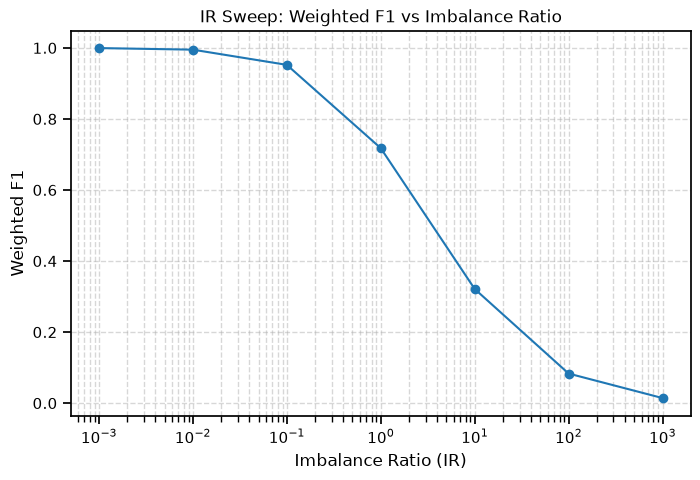

In [558]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('..\\results\\ir-worlds-small.json', 'r') as f:
    metrics = json.load(f)

# Convert keys back to floats
metrics = {float(ir): vals for ir, vals in metrics.items()}

df = pd.DataFrame.from_dict(metrics, orient='index')
df.index.name = 'IR'
df = df.reset_index().sort_values('IR')

plt.figure(figsize=(8,5))
plt.plot(df['IR'], df['f1_score'], marker='o')
plt.xscale('log')
plt.xlabel('Imbalance Ratio (IR)')
plt.ylabel('Weighted F1')
plt.title('IR Sweep: Weighted F1 vs Imbalance Ratio')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

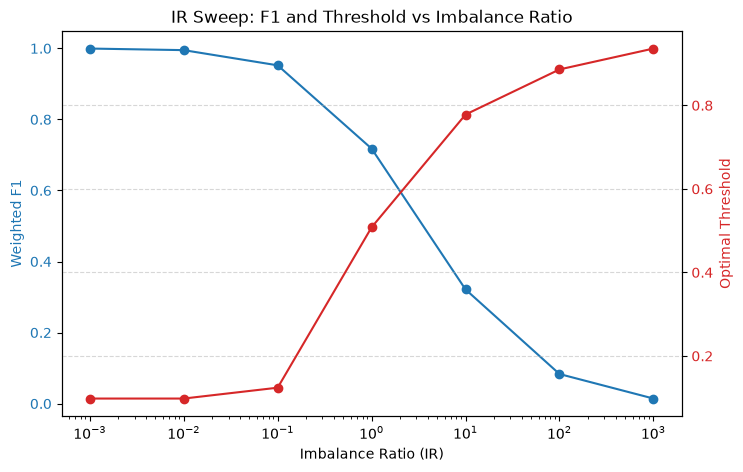

In [119]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(df['IR'], df['f1_score'], marker='o', color='tab:blue')
ax1.set_xscale('log')
ax1.set_xlabel('Imbalance Ratio (IR)')
ax1.set_ylabel('Weighted F1', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(df['IR'], df['threshold'], marker='o', color='tab:red')
ax2.set_ylabel('Optimal Threshold', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('IR Sweep: F1 and Threshold vs Imbalance Ratio')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

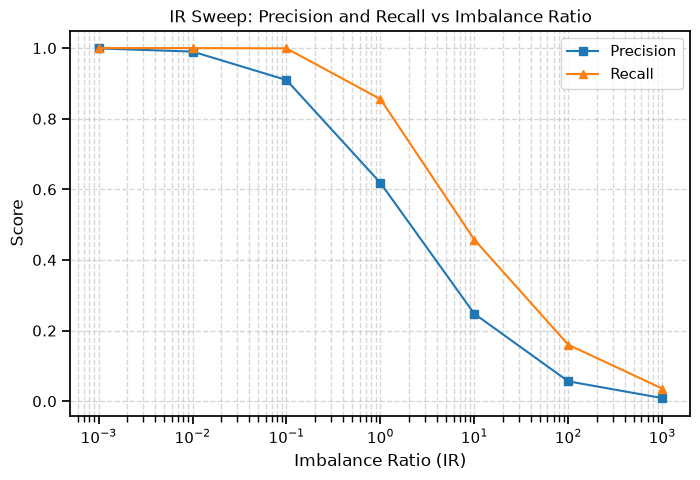

In [565]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df['IR'], df['precision'], 
         marker='s',        # square
         linestyle='-', 
         label='Precision')

plt.plot(df['IR'], df['recall'], 
         marker='^',        # triangle
         linestyle='-', 
         label='Recall')

plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Imbalance Ratio (IR)')
plt.ylabel('Score')
plt.title('IR Sweep: Precision and Recall vs Imbalance Ratio')

plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.show()

In [698]:
import matplotlib.patches as mpatches

def hf_annotation(ax, x0, y0, x1, y1, text, left_shift=1):
    '''
    Add an annotation to a plot.

    x0, y0 : coordinates of the data point
    x1, y1 : coordinates of the text
    '''
    pad = 17
    left_shift
    # Angled segment
    ax.add_patch(
        mpatches.FancyArrowPatch(
            (x0, y0), (x1/left_shift, y1),
            arrowstyle='-',
            #arrowstyle='->',
            color='black',
            linewidth=1.))
    
    # Text
    ax.text(x1/pad, y1, text, fontsize=9, va='center', ha='left')

xsmalld tier IR Sweep: F1, Precision, Recall, and Threshold vs Imbalance Ratio


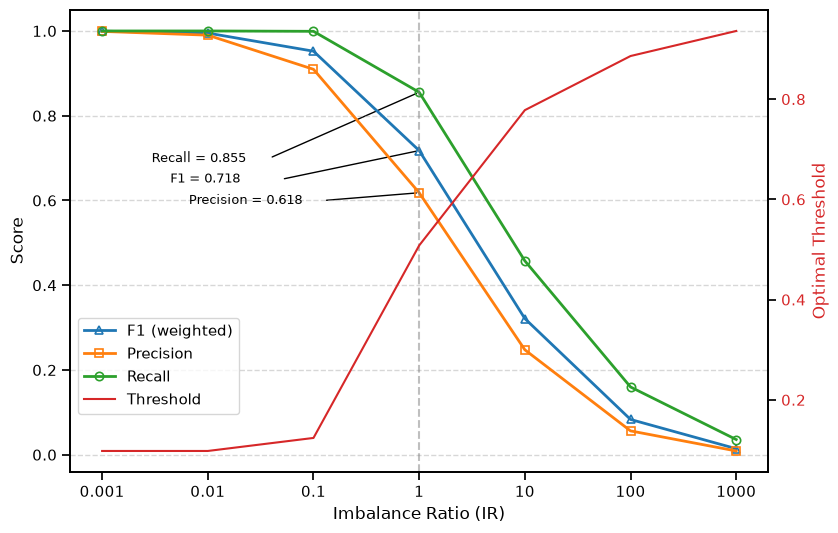

In [846]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullLocator

'''
Plot Recall, precision, and F1 on one ax and threshold on another.
'''
df = hf_read_sweep_results('small')

fig, ax1 = plt.subplots(figsize=(9,6))


# Left axis: F1, precision, recall
params = {'linestyle': '-', 'markeredgewidth': 1.2, 'linewidth': 2.0, 'markerfacecolor': 'none'}
ax1.plot(df['IR'], df['f1_score'], marker='^', label='F1 (weighted)', **params)
ax1.plot(df['IR'], df['precision'], marker='s', label='Precision', **params)
ax1.plot(df['IR'], df['recall'], marker='o', label='Recall', **params)

ax1.set_xscale('log')
ax1.set_xlabel('Imbalance Ratio (IR)')
ax1.set_ylabel('Score')
ax1.grid(axis='y', ls='--', alpha=0.5)

# Right axis: threshold
ax2 = ax1.twinx()
ax2.plot(df['IR'], df['threshold'], 
         marker=None, linestyle='-', color='tab:red', label='Threshold')
ax2.set_ylabel('Optimal Threshold', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Reformat the xaxis labels and remove the minor tick marks
fmt = lambda x, pos: f'{x:g}'                      # Reformat from scientific to general notation
ax1.xaxis.set_major_formatter(FuncFormatter(fmt))
ax1.xaxis.set_minor_locator(NullLocator())

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, framealpha=0.8,
           loc='upper left',
           bbox_to_anchor=(0.0, 0.35))

# Annotations for Recall, precision, and F1-score
bal = df[df.IR==1]
rec, prec, f1 = bal.recall.iloc[0], bal.precision.iloc[0], bal.f1_score.iloc[0]
stagger = 1.5
hf_annotation(ax1, 1, rec, .05, .7, f'Recall = {rec:.3f}', 1.3)
hf_annotation(ax1, 1, f1, .05*stagger, .65, f'F1 = {f1:.3f}', 1.5)
hf_annotation(ax1, 1, prec, .05*(stagger**2), .6, f'Precision = {prec:.3f}', .9)

# Vertical line at IR 1
ax1.axvline(1, color='grey', linestyle='--', alpha=0.5)

# Show and save the plot
print(f'{tier} tier IR Sweep: F1, Precision, Recall, and Threshold vs Imbalance Ratio')
plt.savefig('..\\plots\\ir-sweep-{small}.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### Simplified with scenario results overlaid

xsmalld tier IR Sweep: F1, Precision, Recall, and Threshold vs Imbalance Ratio


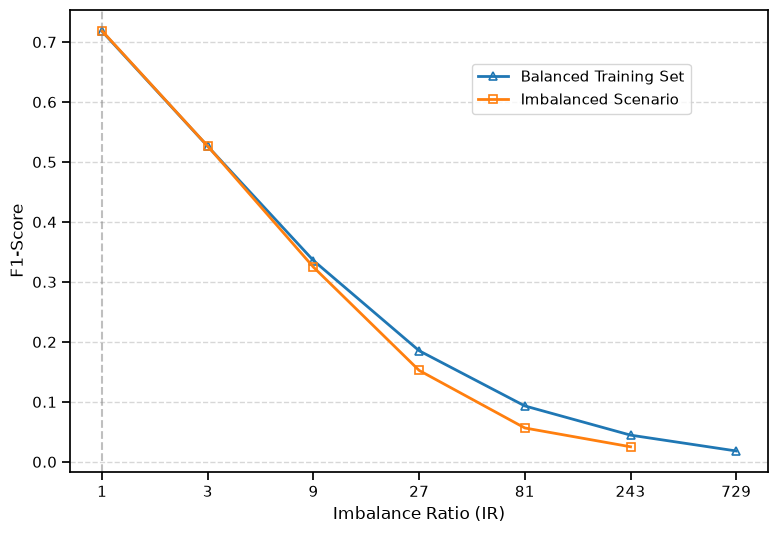

In [873]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullLocator

'''
Plot Recall, precision, and F1 on one ax and threshold on another.
'''

# Read the balanced model results (base-3)
df = hf_read_sweep_results('small-base3')

# Read the imbalanced scenario results
small_imb = xgb_results[
    (xgb_results.tier=='small') &
    (xgb_results.aug==0) &
    (xgb_results.ir.isin([1, 3, 9, 27, 81, 243]))]

# Plot the balanced and imbalanced model results
fig, ax1 = plt.subplots(figsize=(9,6))

# Left axis: F1, precision, recall
params = {'linestyle': '-', 'markeredgewidth': 1.2, 'linewidth': 2.0, 'markerfacecolor': 'none'}
ax1.plot(df['IR'], df['f1_score'], marker='^', label='Balanced Training Set', **params)
ax1.plot(small_imb.ir, small_imb.f1_score, marker='s', label='Imbalanced Scenario', **params)

# Set the x log scale
ax1.set_xscale('log')
# Force ticks at the IR values you want
irs = [1, 3, 9, 27, 81, 243, 729]
ax1.set_xticks(irs)
ax1.set_xticklabels([str(ir) for ir in irs])

# Remove minor ticks
ax1.xaxis.set_minor_locator(NullLocator())

ax1.set_xlabel('Imbalance Ratio (IR)')
ax1.set_ylabel('F1-Score')
ax1.grid(axis='y', ls='--', alpha=0.5)

# Reformat the xaxis labels and remove the minor tick marks
fmt = lambda x, pos: f'{x:g}'                      # Reformat from scientific to general notation
ax1.xaxis.set_major_formatter(FuncFormatter(fmt))
ax1.xaxis.set_minor_locator(NullLocator())

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, framealpha=0.8,
           loc='upper right',
           bbox_to_anchor=(0.9, 0.9))

# Annotations for Recall, precision, and F1-score
bal = df[df.IR==1]
rec, prec, f1 = bal.recall.iloc[0], bal.precision.iloc[0], bal.f1_score.iloc[0]
stagger = 1.5

# Vertical line at IR 1
ax1.axvline(1, color='grey', linestyle='--', alpha=0.5)

# Show and save the plot
print(f'{tier} tier IR Sweep: F1, Precision, Recall, and Threshold vs Imbalance Ratio')
plt.savefig('..\\plots\\balances-vs-imbalanced-{small}.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

## Summary F1 recovery report

In [13]:
from tabulate import tabulate, SEPARATING_LINE

def f1_recovery_summary(tiers, irs, augs, bootstrap=0, scenario_results=None, fold_results=None):
    '''
    Summarise F1 recovery by augmentation level and scenario

    Parameters
    ----------
    sr, fr : dict - Scenario results, fold results.
    '''

    # Collate the table data from the full results dict
    all_rows_w = []
    all_rows_s = []
    all_rows_f = []
    for tier in tiers:
        for ir in irs:

            # Skip scenarios outside the experimental grid
            if (
                ((tier == 'medium') and (ir == 243)) or
                ((tier == 'small') and (ir == 243))
            ):
                continue
            
            # Construct two table rows for scenario (tier-IR). First row with weighted results and
            # second with standard results
            row_w = [tier, ir, 'W']
            row_s = [tier, ir, 'S']
            row_f = [tier, ir, '-']
            
            for aug in augs:
                
                # Show unaugmented results for all scenarios, but only show augmented results for
                # imbalanced scenarios
                # Only show augmented results for unbalanced scenarios
                # Only show F1 recovery for augmented scenarios
                if (aug == 0) or ((aug != 0) and (ir > 1)):
                    # Select the scenario from the full scenario results
                    sr = scenario_results[f'{tier}-ir{ir:03d}-aug{aug:03}']
                    fr = fold_results[f'{tier}-ir{ir:03d}-aug{aug:03}']
                if aug ==0:
                    row_w.append(sr['f1_score_w'])
                    row_s.append(sr['f1_score'])
                    row_f.append(fr['best_f1_median'])
                elif ir == 1:
                    row_w.extend([None,None])
                    row_s.extend([None, None])
                    row_f.extend([None, None])
                else:
                    row_w.extend([sr['f1_score_w'], sr['f1_recovery_percentage_w']])   
                    row_s.extend([sr['f1_score'], sr['f1_recovery_percentage']])
                    row_f.extend([fr['best_f1_median'], fr['f1_recovery_percentage']])
            else:
                # Add only the weighted and standard results to their respective tables
                all_rows_w.append(row_w)
                all_rows_s.append(row_s)
                all_rows_f.append(row_f)
        else:
            all_rows_w.append(SEPARATING_LINE)
            all_rows_s.append(SEPARATING_LINE)
            all_rows_f.append(SEPARATING_LINE)
    else:
        pass

    # Contruct the table headers
    headers = ['', '', '', 'Aug 0\nF1']
    for aug in augs[1:]:
        headers.append(f'Aug {aug:03d}\nF1')
        headers.append(f' \nRecov (%)')

    # Display the tables
    table_params = {
        'headers': headers, 
        'floatfmt': '.3f', 
        'tablefmt': 'github', 
        'missingval': '-'
    }
    print('\nSCENARIO F1 EVALUATION - IR-WEIGHTED\n')
    print(tabulate(all_rows_w, **table_params), '\n')

    print('\n FOLD F1 EVALUATION\n')
    print(tabulate(all_rows_f, **table_params), '\n')

    print('\nSCENARIO F1 EVALUATION - STANDARD\n')
    print(tabulate(all_rows_s, **table_params), '\n')

# TEST
fold_results, scenario_results = hf_read_experiment_results(0)
f1_recovery_summary(TIERS, IRS, AUGS, 0, scenario_results, fold_results)


SCENARIO F1 EVALUATION - IR-WEIGHTED

|        |     |    |   Aug 0 |   Aug 050 |             |   Aug 100 |             |   Aug 200 |             |   Aug 400 |             |
|        |     |    |      F1 |        F1 |   Recov (%) |        F1 |   Recov (%) |        F1 |   Recov (%) |        F1 |   Recov (%) |
|--------|-----|----|---------|-----------|-------------|-----------|-------------|-----------|-------------|-----------|-------------|
| large  |   1 | W  |   0.717 |     -     |       -     |     -     |       -     |     -     |       -     |     -     |       -     |
| large  |   3 | W  |   0.530 |     0.530 |       0.229 |     0.528 |      -0.820 |     0.530 |       0.239 |     0.528 |      -1.058 |
| large  |   9 | W  |   0.332 |     0.336 |       0.987 |     0.335 |       0.881 |     0.332 |      -0.093 |     0.329 |      -0.707 |
| large  |  27 | W  |   0.179 |     0.180 |       0.281 |     0.180 |       0.196 |     0.182 |       0.554 |     0.180 |       0.364 |
| large  

### Summary F1 recovery report - phase 2

In [15]:
# Phase 2 - Medium - Fine grained augmentation level

fold_results, scenario_results = hf_read_experiment_results(0)
augs_2a = [0, 4, 8, 13, 18]
augs_2b = [22, 28, 33, 38, 44]
f1_recovery_summary(TIERS_2, IRS_2, augs_2a, 0, scenario_results, fold_results)
f1_recovery_summary(TIERS_2, IRS_2, augs_2b, 0, scenario_results, fold_results)


SCENARIO F1 EVALUATION - IR-WEIGHTED

|        |    |    |   Aug 0 |   Aug 004 |             |   Aug 008 |             |   Aug 013 |             |   Aug 018 |             |
|        |    |    |      F1 |        F1 |   Recov (%) |        F1 |   Recov (%) |        F1 |   Recov (%) |        F1 |   Recov (%) |
|--------|----|----|---------|-----------|-------------|-----------|-------------|-----------|-------------|-----------|-------------|
| medium |  3 | W  |   0.528 |     0.524 |      -2.238 |     0.527 |      -0.575 |     0.527 |      -0.639 |     0.526 |      -0.788 |
| medium |  9 | W  |   0.328 |     0.329 |       0.147 |     0.331 |       0.842 |     0.330 |       0.516 |     0.328 |       0.028 |
| medium | 27 | W  |   0.168 |     0.178 |       1.649 |     0.173 |       0.874 |     0.172 |       0.676 |     0.164 |      -0.741 |
| medium | 81 | W  |   0.073 |     0.072 |      -0.143 |     0.029 |      -6.746 |     0.073 |      -0.030 |     0.063 |      -1.555 |
|--------|----|-

## Detailed metrics report

In [27]:
def fold_detail(tier, ir, bootstrap, augs, results, metrics, labels, mean_and_std=True, isint=False):
    '''
    Tabulate detailed metadata and metric for a range of scenarios and augmentation levels.
    '''

    #metrics = ['augmented_ir', 'n_train', 'n_neg_real', 
    #           'n_pos_real', 'n_synthetic']
    #labels = ['Augmented IR', 'Sample size', 'N Real Neg', 'N Real Pos', 'N Synthetic']

    # Collate the table data from the full results dict
    all_rows = []
            
    for metric, label in zip(metrics, labels):
        row = [label]
        
        for aug in augs:
            
            # Iterate through the augmentation levels, but only include aug=0 for 
            # balanced scenarios
            if (aug == 0) or ((aug != 0) and (ir > 1)):
                # Select the scenario from the full scenario results
                res = results[f'{tier}-ir{ir:03d}-aug{aug:03}']
                
                if mean_and_std:
                    row.extend([res[metric + '_median'], res[metric + '_std']])
                else:
                    if isint:
                        row.append(int(res[metric]))
                    else:
                        row.append(res[metric])
            else:
                if mean_and_std:
                    row.extend([None,None])
                else:
                    row.append(None)
        else:
            all_rows.append(row)        
    else:
        pass
        #all_rows.append(SEPARATING_LINE)

    # Contruct the table headers
    headers = ['']
    for aug in augs:
        if mean_and_std:
            headers.append(f'Aug {aug:03d}\nMedian')
            headers.append(f'Aug {aug:03d}\nStd')
        else:
            headers.append(f'Aug {aug:03d}')

    # Display the tables
    table_params = {
        'headers': headers, 
        'floatfmt': '.3f', 
        #'intfmt': '5d',
        'tablefmt': 'github', 
        'missingval': '-'
    }
    print(tabulate(all_rows, **table_params), '\n')

# TEST
fold_results, scenario_results = hf_read_experiment_results(0)

def fold_detail_all_metrics(tier, ir, bootstrap, augs):

    # FOLD-TRAINING 
    
    # Augmented IR
    aug_ir_vals = ['augmented_ir_median']
    aug_ir_labels = ['Augmented IR']
    
    # Metadata values
    metadata_vals = ['n_train_median', 'n_neg_real_median', 
               'n_pos_real_median', 'n_synthetic_median']
    metadata_labels = ['Sample size', 'N Real Neg', 'N Real Pos', 'N Synthetic']
    
    # Metric values
    metric_vals = ['augmented_ir', 'best_iteration', 'pr_auc', 'roc_auc', 'log_loss', 'best_threshold', 'best_pr', 'best_rec', 'best_f1']
    metric_labels = ['Augmented IR', 'Best Iteration', 'PR AUC', 'ROC AUC', 'Log Loss', 'Best Threshold', 'Best Precision', 'Best Recall', 'Best F1']

    # F1 values
    f1_vals = ['f1_balanced', 'f1_baseline', 'f1_loss', 'f1_augmented', 'f1_recovered', 'f1_recovery_percentage']
    f1_labels = ['F1 Balanced', 'F1 Baseline', 'F1 Loss', 'F1 Augmented', 'F1 Recovered', 'F1 Recovered (%)']

    # SCENARIO TRAINING
    metric_vals_s = ['augmented_ir', 'n_estimators', 'log_loss', 'threshold', 
                       'pr_auc_w', 'roc_auc_w', 'precision_w', 'recall_w', 'f1_score_w',
                       'pr_auc', 'roc_auc', 'precision', 'recall', 'f1_score']
    metric_labels_s = ['Augmented IR', 'N Estimators', 'Log Loss', 'Threshold', 
                       'PR AUC (W)', 'ROC AUC (W)', 'Precision (W)', 'Recall (W)', 'F1 Score (W)',
                       'PR AUC', 'ROC AUC', 'Precision', 'Recall', 'F1 Score']
    f1_vals_s = ['f1_balanced_w', 'f1_baseline_w', 'f1_loss_w', 'f1_augmented_w', 'f1_recovered_w', 'f1_recovery_percentage_w',
                'f1_balanced', 'f1_baseline', 'f1_loss', 'f1_augmented', 'f1_recovered', 'f1_recovery_percentage']
    f1_labels_s = ['F1 Balanced (W)', 'F1 Baseline (W)', 'F1 Loss (W)', 'F1 Augmented (W)', 'F1 Recovered (W)', 'F1 Recovered (%) (W)',
                  'F1 Balanced', 'F1 Baseline', 'F1 Loss', 'F1 Augmented', 'F1 Recovered', 'F1 Recovered (%)']
    
    print(F'\nALL RESULTS: {tier} IR {ir} Bootstrap {bootstrap}\n')
    fold_detail(tier, ir , bootstrap, augs, fold_results, aug_ir_vals, aug_ir_labels, mean_and_std=False)
    fold_detail(tier, ir , bootstrap, augs, fold_results, metadata_vals, metadata_labels, mean_and_std=False, isint=True)

    print('Fold level training results')
    fold_detail(tier, ir , bootstrap, augs, fold_results, metric_vals, metric_labels)
    fold_detail(tier, ir , bootstrap, augs, fold_results, f1_vals, f1_labels, mean_and_std=False)

    print('Scenario level training results')
    fold_detail(tier, ir , bootstrap, augs, scenario_results, metric_vals_s, metric_labels_s, mean_and_std=False)
    fold_detail(tier, ir , bootstrap, augs, scenario_results, f1_vals_s, f1_labels_s, mean_and_std=False)

fold_detail_all_metrics('large', 3, 0, AUGS)


ALL RESULTS: large IR 3 Bootstrap 0

|              |   Aug 000 |   Aug 050 |   Aug 100 |   Aug 200 |   Aug 400 |
|--------------|-----------|-----------|-----------|-----------|-----------|
| Augmented IR |     3.000 |     1.846 |     1.333 |     0.857 |     0.500 | 

|             |   Aug 000 |   Aug 050 |   Aug 100 |   Aug 200 |   Aug 400 |
|-------------|-----------|-----------|-----------|-----------|-----------|
| Sample size |     71494 |     71494 |     71494 |     71494 |     71494 |
| N Real Neg  |     53621 |     53621 |     53621 |     53621 |     53621 |
| N Real Pos  |     17874 |     17874 |     17874 |     17874 |     17874 |
| N Synthetic |         0 |     11171 |     22342 |     44684 |     89368 | 

Fold level training results
|                |   Aug 000 |   Aug 000 |   Aug 050 |   Aug 050 |   Aug 100 |   Aug 100 |   Aug 200 |   Aug 200 |   Aug 400 |   Aug 400 |
|                |    Median |       Std |    Median |       Std |    Median |       Std |    Median |  

### Main fold-level scenario loop

In [194]:
for tier in TIERS:
    # Section heading
    print(f'{'#' * 30}')
    print(f'{'#' * 5} {' ':^18} {'#' * 5}')
    print(f'{'#' * 5} {tier.upper():^18} {'#' * 5}')
    print(f'{'#' * 5} {' ':^18} {'#' * 5}')
    print(f'{'#' * 30}')

    # Iterate through scenarios
    for ir in IRS:
        if (tier, ir) in SKIP:
            continue
        else:    
            fold_detail_all_metrics(tier, ir, 0, AUGS)

##############################
#####                    #####
#####       LARGE        #####
#####                    #####
##############################

ALL RESULTS: large IR 3 Bootstrap 0

|              |   Aug 000 |   Aug 050 |   Aug 100 |   Aug 200 |   Aug 400 |
|--------------|-----------|-----------|-----------|-----------|-----------|
| Augmented IR |     3.000 |     1.846 |     1.333 |     0.857 |     0.500 | 

|             |   Aug 000 |   Aug 050 |   Aug 100 |   Aug 200 |   Aug 400 |
|-------------|-----------|-----------|-----------|-----------|-----------|
| Sample size |     71494 |     71494 |     71494 |     71494 |     71494 |
| N Real Neg  |     53621 |     53621 |     53621 |     53621 |     53621 |
| N Real Pos  |     17874 |     17874 |     17874 |     17874 |     17874 |
| N Synthetic |         0 |     11171 |     22342 |     44684 |     89368 | 

Fold level training results
|                |   Aug 000 |   Aug 000 |   Aug 050 |   Aug 050 |   Aug 100 |   Aug 100

### Main report loop - phase 2

In [18]:
for tier in TIERS_2:
    # Section heading
    print(f'{'#' * 30}')
    print(f'{'#' * 5} {' ':^18} {'#' * 5}')
    print(f'{'#' * 5} {tier.upper():^18} {'#' * 5}')
    print(f'{'#' * 5} {' ':^18} {'#' * 5}')
    print(f'{'#' * 30}')

    # Iterate through scenarios
    for ir in IRS_2:
        if (tier, ir) in SKIP:
            continue
        else:    
            fold_detail_all_metrics(tier, ir, 0, AUGS_2)

##############################
#####                    #####
#####       MEDIUM       #####
#####                    #####
##############################

ALL RESULTS: medium IR 3 Bootstrap 0

|              |   Aug 000 |   Aug 050 |   Aug 100 |   Aug 200 |   Aug 400 |
|--------------|-----------|-----------|-----------|-----------|-----------|
| Augmented IR |     3.000 |     1.846 |     1.333 |     0.857 |     0.500 | 

|             |   Aug 000 |   Aug 050 |   Aug 100 |   Aug 200 |   Aug 400 |
|-------------|-----------|-----------|-----------|-----------|-----------|
| Sample size |     35747 |     35747 |     35747 |     35747 |     35747 |
| N Real Neg  |     26810 |     26810 |     26810 |     26810 |     26810 |
| N Real Pos  |      8937 |      8937 |      8937 |      8937 |      8937 |
| N Synthetic |         0 |      5586 |     11171 |     22342 |     44684 | 

Fold level training results
|                |   Aug 000 |   Aug 000 |   Aug 050 |   Aug 050 |   Aug 100 |   Aug 10

### Phase 3 detailed metrics

In [28]:
for tier in TIERS_3:
    # Section heading
    print(f'{'#' * 30}')
    print(f'{'#' * 5} {' ':^18} {'#' * 5}')
    print(f'{'#' * 5} {tier.upper():^18} {'#' * 5}')
    print(f'{'#' * 5} {' ':^18} {'#' * 5}')
    print(f'{'#' * 30}')

    # Iterate through scenarios
    for ir in IRS_3:
        if (tier, ir) in SKIP_3:
            continue
        else:    
            fold_detail_all_metrics(tier, ir, 0, AUGS_3)

##############################
#####                    #####
#####       SMALLA       #####
#####                    #####
##############################

ALL RESULTS: smalla IR 1 Bootstrap 0

|              |   Aug 000 | Aug 004   | Aug 008   | Aug 013   | Aug 018   | Aug 022   | Aug 028   | Aug 033   | Aug 038   | Aug 044   | Aug 050   |
|--------------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
| Augmented IR |     1.000 | -         | -         | -         | -         | -         | -         | -         | -         | -         | -         | 

|             |   Aug 000 | Aug 004   | Aug 008   | Aug 013   | Aug 018   | Aug 022   | Aug 028   | Aug 033   | Aug 038   | Aug 044   | Aug 050   |
|-------------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
| Sample size |      8000 | -         | -         | -        

### Phase 4 - details metrics

In [33]:
for tier in TIERS_4:
    # Section heading
    print(f'{'#' * 30}')
    print(f'{'#' * 5} {' ':^18} {'#' * 5}')
    print(f'{'#' * 5} {tier.upper():^18} {'#' * 5}')
    print(f'{'#' * 5} {' ':^18} {'#' * 5}')
    print(f'{'#' * 30}')

    # Iterate through scenarios
    for ir in IRS_4:
        if (tier, ir) in SKIP_4:
            continue
        else:    
            fold_detail_all_metrics(tier, ir, 0, AUGS_4)

##############################
#####                    #####
#####      XSMALLA       #####
#####                    #####
##############################

ALL RESULTS: xsmalla IR 1 Bootstrap 0

|              |   Aug 000 | Aug 004   | Aug 008   | Aug 013   | Aug 018   | Aug 022   | Aug 028   | Aug 033   | Aug 038   | Aug 044   | Aug 050   |
|--------------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
| Augmented IR |     1.000 | -         | -         | -         | -         | -         | -         | -         | -         | -         | -         | 

|             |   Aug 000 | Aug 004   | Aug 008   | Aug 013   | Aug 018   | Aug 022   | Aug 028   | Aug 033   | Aug 038   | Aug 044   | Aug 050   |
|-------------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
| Sample size |       640 | -         | -         | -       

*<center>-- End of notebook --</center>*